# Step 2 — State-Level Competitiveness
**Objective:** Disaggregate Brazil's national trade picture to the state level — identifying which states drive exports and imports, which sectors and products dominate each region, how trade balances vary, how growth is distributed, and whether the China dependency identified in Step 1 is uniform or concentrated.

This notebook covers:
##### 1.1 State Trade Participation — Who Drives Brazilian Trade?
##### 1.2 Trade Balance by State — Net Exporters vs Net Importers (2025)
##### 1.3 State Trade Balance Through Economic Cycles — Which States Were Most Resilient?
##### 2. State Export Growth Dynamics — Which States Are Rising and Falling?
##### 3.1 Regional Export Distribution — How Brazil's Five Macro-Regions Compare
##### 3.2 Regional Import Distribution — Where Brazil's Five Macro-Regions Source From
##### 4. Export Sector Structure — What Brazil's States and Regions Actually Sell
##### 5. Import Sector Structure — What Brazil's States and Regions Actually Buy
##### 6. Product-Level Detail — Top 10 NCM Products by State and Region
##### 7. China Dependency at State Level — Is the 28.7% National Average Uniform?
##### 8. Monthly Export Volatility by State — How Stable Are State Export Flows?
##### 9. Monthly Import Volatility by State — How Stable Are State Import Flows?
##### 10. State Trade Hub Profiles — Export and Import Fingerprint for Each State
##### 11. Regional Trade Hub Profiles — What Each Macro-Region Specialises In
##### 12.1 Commodities vs Processed Products by State and Region
##### 12.2 Commodities vs Processed Products
##### 13. YoY Export Growth by State — Identifying Fast-Growing and Declining States
##### 14. Unit Price (USD/kg) by State — Distinguishing Commodity vs Value-Added Exporters
##### 15. Volume vs Value Decomposition — Is State Export Growth Driven by Price or Volume?
##### 16. Market Concentration — Top 3 Destination Share and HHI Diversification Index
##### 17.1 Coverage Ratio by State — How Trade-Self-Sufficient Is Each State?
##### 17.2 Coverage Ratio by Region
##### 18. Key Findings

## Setup

This section initializes the database connection and establishes the time horizon of the analysis.  
The full series covers 1997–2025, while a recent 10-year window (2016–2025) is used to analyze monthly patterns and variability.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
from pathlib import Path
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Credentials
dotenv_path = Path(r"C:\Users\e_koh\Downloads\State Analysis\brazil-state-trade-analysis\.env")
load_dotenv(dotenv_path, override=True)

DB_USER     = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST     = os.getenv("DB_HOST")
DB_PORT     = os.getenv("DB_PORT")
DB_NAME     = os.getenv("DB_NAME")

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")
print("Connected to database successfully")

## Data capped at 2025 — 2026 contains only partial year data which distorts trend visuals
MAX_YEAR  = 2025
MIN_YEAR  = 1997
## Monthly box plot window — last 10 years
BOX_START = 2016

Connected to database successfully


## 2.1 — State Trade Participation — Who Drives Brazilian Trade?


***Note:** REGIAO NAO DECLARADA (UNDECLARED) is retained to preserve total national trade volume. Its exports ($2.31bn) cannot be attributed to a specific state and will be excluded from any state-level structural analysis.*

### 2.1.1 - State Trade by Export Value
Ranking all states by export, import and balance value in the most recent year — establishing which states dominate national trade and how concentrated Brazil's trade geography is.

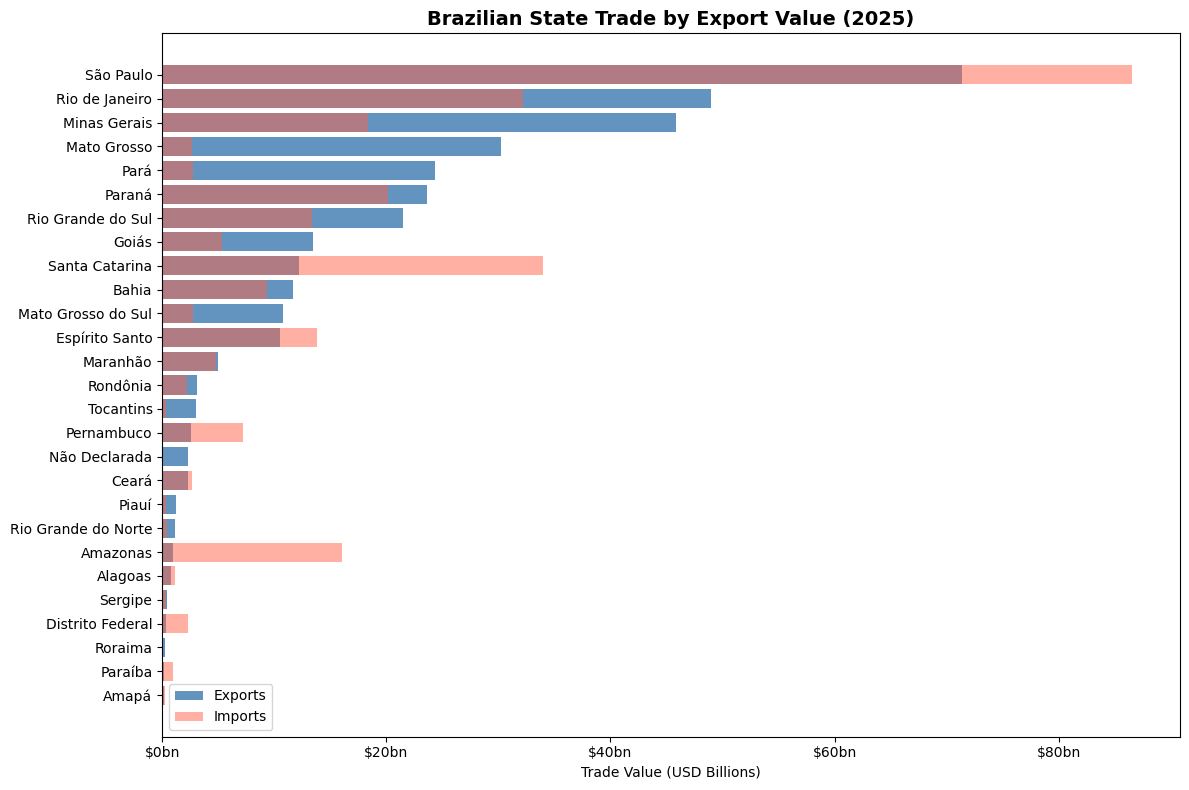


All states — Exports, Imports and Balance (2025)
              state      region uf  exports_usd_bn  imports_usd_bn  balance_usd_bn
          São Paulo   Southeast SP           71.39           86.50          -15.11
     Rio de Janeiro   Southeast RJ           48.98           32.17           16.80
       Minas Gerais   Southeast MG           45.83           18.33           27.50
        Mato Grosso Center-West MT           30.19            2.62           27.57
               Pará       North PA           24.34            2.74           21.59
             Paraná       South PR           23.65           20.15            3.50
  Rio Grande do Sul       South RS           21.53           13.38            8.15
              Goiás Center-West GO           13.47            5.36            8.11
     Santa Catarina       South SC           12.20           33.99          -21.80
              Bahia   Northeast BA           11.63            9.31            2.32
 Mato Grosso do Sul Center-West MS   

In [3]:
query_state_trade = f"""
    SELECT u.nome_estado AS state,
           u.nome_regiao AS region,
           u.sigla AS uf,
           COALESCE(e.exports_usd, 0) AS exports_usd,
           COALESCE(i.imports_usd, 0) AS imports_usd,
           COALESCE(e.exports_usd, 0) - COALESCE(i.imports_usd, 0) AS balance_usd
    FROM uf u
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS exports_usd
        FROM exp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) e ON e."SG_UF_NCM" = u.sigla
    LEFT JOIN (
        SELECT "SG_UF_NCM", SUM("VL_FOB") AS imports_usd
        FROM imp
        WHERE "CO_ANO" = {MAX_YEAR}
        GROUP BY "SG_UF_NCM"
    ) i ON i."SG_UF_NCM" = u.sigla
    WHERE COALESCE(e.exports_usd, 0) > 0 OR COALESCE(i.imports_usd, 0) > 0
    ORDER BY exports_usd DESC
"""

df_state = pd.read_sql(query_state_trade, engine)
df_state['exports_usd_bn'] = (df_state['exports_usd'] / 1e9).round(2)
df_state['imports_usd_bn'] = (df_state['imports_usd'] / 1e9).round(2)
df_state['balance_usd_bn'] = (df_state['balance_usd'] / 1e9).round(2)


## Translate region names to English
region_name_map = {
    'REGIAO NORDESTE'    : 'Northeast',
    'REGIAO NORTE'       : 'North',
    'REGIAO SUDESTE'     : 'Southeast',
    'REGIAO CENTRO OESTE': 'Center-West',
    'REGIAO SUL'         : 'South',
    'REGIAO NAO DECLARADA': 'Undeclared'
}
df_state['region'] = df_state['region'].map(region_name_map).fillna(df_state['region'])


df_top = df_state.head(27).sort_values('exports_usd_bn')

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_top['state'], df_top['exports_usd_bn'], color='steelblue', alpha=0.85, label='Exports')
ax.barh(df_top['state'], df_top['imports_usd_bn'], color='tomato', alpha=0.5, label='Imports')
ax.set_title(f"Brazilian State Trade by Export Value ({MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Trade Value (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend()
plt.tight_layout()
plt.savefig('output_2_1_state_trade.png', dpi=150)
plt.show()

total_row = pd.DataFrame([{
    'state': 'TOTAL',
    'region': '',
    'uf': '',
    'exports_usd_bn': df_state['exports_usd_bn'].sum().round(2),
    'imports_usd_bn': df_state['imports_usd_bn'].sum().round(2),
    'balance_usd_bn': df_state['balance_usd_bn'].sum().round(2)
}])

df_state_print = pd.concat([df_state, total_row], ignore_index=True)

print(f"\nAll states — Exports, Imports and Balance ({MAX_YEAR})")
print(df_state_print[['state', 'region', 'uf', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']].to_string(index=False))

### Overview

**National concentration is extreme.** The top 5 exporting states — São Paulo, Rio de Janeiro, Minas Gerais, Mato Grosso and Pará — account for approximately \\$221bn of Brazil's \\$348bn total exports, or roughly 64% of national export value concentrated in five states across three regions.

**The Southeast dominates on both sides.** São Paulo (\\$71.39bn exports, \$86.50bn imports), Rio de Janeiro (\\$48.98bn, \\$32.17bn) and Minas Gerais (\\$45.83bn, \\$18.33bn) together represent the largest single regional trade cluster in Brazil. Their combined export value of \\$166bn exceeds the entire output of every other region combined.

**17 states run surpluses, 10 run deficits.** The largest surpluses are Mato Grosso (+\$27.57bn) and Minas Gerais (+\\$27.50bn) — both commodity-driven export economies with minimal import needs relative to their export scale. The largest deficits are Santa Catarina (-\\$21.80bn), Amazonas (-\\$15.13bn) and São Paulo (-\\$15.11bn), each driven by structurally different factors.

**Santa Catarina's deficit is the most anomalous finding.** It is the 11th largest exporter (\\$12.20bn) but the 2nd largest importer (\\$33.99bn) — importing nearly three times what it exports. No other state of comparable export size runs a deficit of this magnitude. This implies a significant import hub or re-export function that goes beyond its domestic industrial needs and warrants product-level investigation in Step 5.

**Amazonas confirms the Zona Franca dynamic.** \$0.94bn in exports vs \\$16.06bn in imports — a coverage ratio of approximately 0.06. The Free Trade Zone is structurally an import platform that sources components globally and manufactures for the domestic Brazilian market rather than for export. Despite generating the highest USD/kg value density in Step 2b, Amazonas runs the second largest absolute import deficit in the country.

**The Center-West states are the purest surplus generators.** Mato Grosso (+\\$27.57bn), Mato Grosso do Sul (+\\$8.04bn) and Goiás (+\\$8.11bn) all run large surpluses with negligible import volumes relative to their exports. This reflects the agricultural frontier profile — bulk commodity exports require minimal imported inputs compared to industrial production.

> ⚠️ *Não Declarada (\\$2.31bn exports, \\$0 imports) represents transactions where the origin state was not recorded in the MDIC system. At \\$2.31bn this is not negligible — it would rank 17th among all states. The zero imports figure is likely a recording artefact rather than a true reflection of undeclared import origins.*

---
---

### 2.1.2 — Trade Balance by State: Net Exporters vs Net Importers (2025)
Which states run trade surpluses and which run deficits? The coverage ratio (exports/imports) reveals each state's degree of external trade dependency.

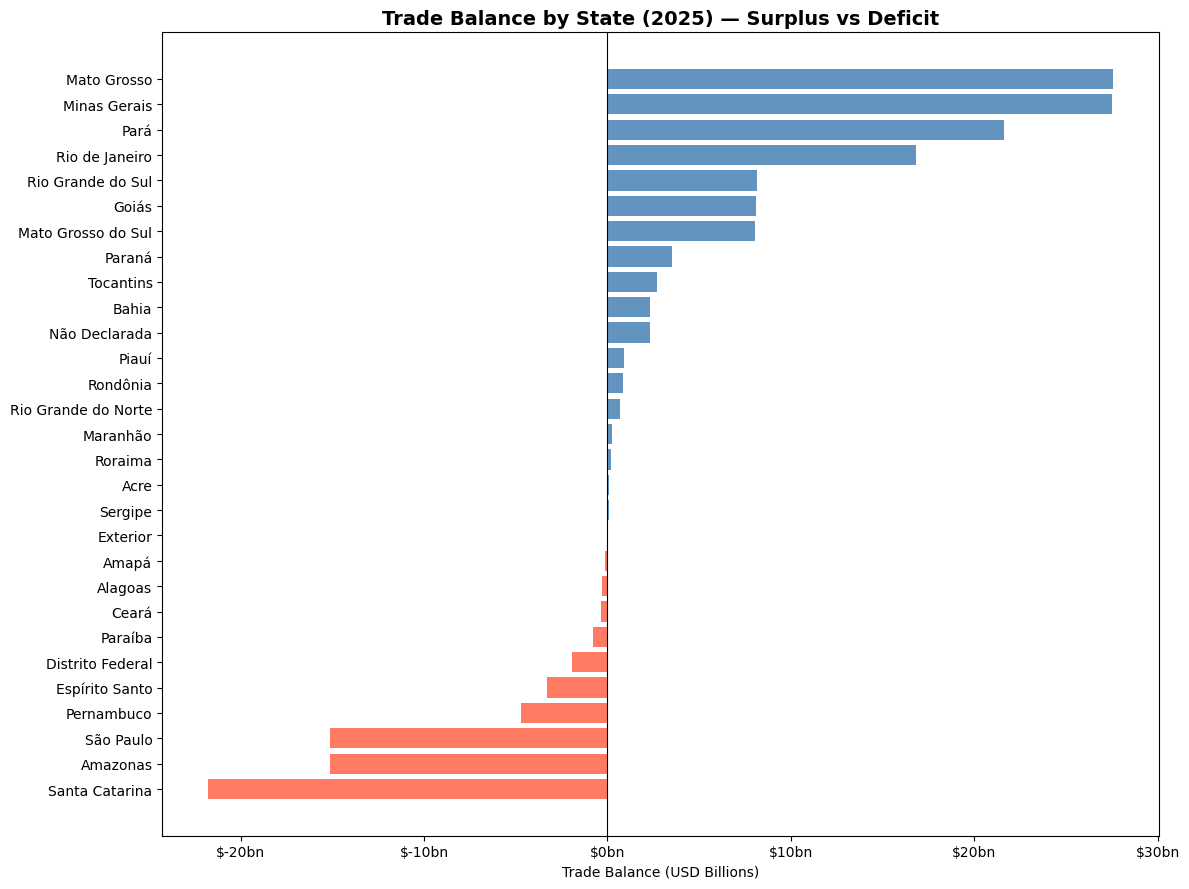

Net exporting states (2025):
              state      region  balance_usd_bn
        Mato Grosso Center-West           27.57
       Minas Gerais   Southeast           27.50
               Pará       North           21.59
     Rio de Janeiro   Southeast           16.80
  Rio Grande do Sul       South            8.15
              Goiás Center-West            8.11
 Mato Grosso do Sul Center-West            8.04
             Paraná       South            3.50
          Tocantins       North            2.70
              Bahia   Northeast            2.32
      Não Declarada  Undeclared            2.31
              Piauí   Northeast            0.90
           Rondônia       North            0.85
Rio Grande do Norte   Northeast            0.69
           Maranhão   Northeast            0.26
            Roraima       North            0.20
               Acre       North            0.09
            Sergipe   Northeast            0.06

Net importing states (2025):
           state      region 

In [5]:
## Uses df_state from 2.1
df_balance = df_state[['state', 'uf', 'region', 'balance_usd_bn']].sort_values('balance_usd_bn')
colors = ['tomato' if x < 0 else 'steelblue' for x in df_balance['balance_usd_bn']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_balance['state'], df_balance['balance_usd_bn'], color=colors, alpha=0.85)
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title(f"Trade Balance by State ({MAX_YEAR}) — Surplus vs Deficit", fontsize=14, fontweight='bold')
ax.set_xlabel("Trade Balance (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_3_state_balance.png', dpi=150)
plt.show()

surplus_states = df_balance[df_balance['balance_usd_bn'] > 0].sort_values('balance_usd_bn', ascending=False)
deficit_states = df_balance[df_balance['balance_usd_bn'] < 0].sort_values('balance_usd_bn')

print(f"Net exporting states ({MAX_YEAR}):")
print(surplus_states[['state', 'region', 'balance_usd_bn']].to_string(index=False))
print(f"\nNet importing states ({MAX_YEAR}):")
print(deficit_states[['state', 'region', 'balance_usd_bn']].to_string(index=False))

**18 states run surpluses, 10 run deficits.** The surplus states are predominantly commodity exporters from Centro-Oeste, Norte and Nordeste. The deficit states are predominantly industrial, administrative or import-dependent economies from Sul, Sudeste and Nordeste.

### Surplus States

The top four surpluses — Mato Grosso (+\\$27.57bn), Minas Gerais (+\\$27.50bn), Pará (+\\$21.59bn) and Rio de Janeiro (+\\$16.80bn) — together account for the bulk of Brazil's national trade surplus. All four are commodity-driven: soybeans, iron ore, iron ore and oil respectively.

The Centro-Oeste sweep is complete — Mato Grosso, Mato Grosso do Sul and Goiás all run surpluses, confirming the region's role as a net contributor to Brazil's export balance. None of the three has meaningful import volumes relative to its export scale.

Among smaller surplus states, Tocantins (+\\$2.70bn) and Bahia (+\\$2.32bn) stand out. Tocantins's surplus is large relative to its economy size, reflecting its agricultural frontier profile. Bahia's surplus — despite having significant import-intensive petrochemical and automotive industries — reflects the breadth of its export base.

### Deficit States

**Santa Catarina (-\\$21.80bn)** is the largest deficit state and the most structurally anomalous. Its deficit exceeds its entire export value (\\$12.20bn), implying it imports nearly three times what it exports. At this scale it is functioning as a regional import hub rather than simply a net importer. What drives \\$33.99bn in imports into a state with \\$12.20bn in exports requires product-level investigation in Step 5.

**Amazonas (-\\$15.13bn) and São Paulo (-\\$15.11bn)** are almost identical in deficit magnitude despite being completely different economies:
- São Paulo's deficit reflects the import intensity of industrial production — capital goods, components, chemicals and energy for Brazil's largest manufacturing base
- Amazonas's deficit reflects the Zona Franca structure — imported components assembled domestically for the Brazilian consumer market rather than for export

**Pernambuco (-\\$4.70bn)** is the largest Nordeste deficit state despite being a moderate exporter (\\$2.54bn). The Suape industrial complex imports significant inputs — petroleum products, capital goods and industrial components — that are not yet matched by export revenues. This is consistent with Pernambuco's industrial development phase.

**Espírito Santo (-\\$3.30bn)** runs a deficit despite significant iron ore and steel exports (\\$10.51bn). This likely reflects the state's role as a transshipment and logistics hub — importing goods for processing or re-export through the port of Vitória.

**Distrito Federal (-\\$1.94bn)** runs a deficit as expected — it is an administrative capital with minimal productive export base and imports goods for government and consumption purposes.

### Regional Balance Pattern

| Region | Net position | Key driver |
|---|---|---|
| Centro-Oeste | Strongly positive | Agricultural commodity surpluses |
| Norte | Mixed — large surpluses (Pará) offset by Amazonas deficit | Mineral extraction vs Zona Franca |
| Sul | Mixed — Paraná and RS surplus offset by SC deficit | SC import hub anomaly |
| Sudeste | Mixed — MG and RJ surplus offset by SP deficit | Commodity surplus vs industrial deficit |
| Nordeste | Predominantly positive with Pernambuco exception | Small agricultural surpluses dominate |

> ⚠️ *Santa Catarina's -\\$21.80bn deficit is the single most analytically unresolved finding in Step 2. Its scale relative to the state's export base (coverage ratio ~0.36) is without parallel among comparable-sized states and requires product-level import data analysis in Step 5 to explain.*



**São Paulo has been the dominant exporter throughout the entire period** and accelerated sharply after 2020, reaching approximately \\$70bn by 2025 — a level no other state approaches. The post-2020 trajectory is steeper than any prior period, driven by industrial export recovery and the weak Real boosting USD-denominated export values.

**Minas Gerais and Rio de Janeiro show structurally different growth patterns.** Minas Gerais (green) peaked sharply around 2011 — consistent with the national iron ore and commodity export peak identified in Step 1 — then contracted significantly through 2015–2016 before recovering to new highs by 2025. Rio de Janeiro (dark red) followed a similar but more muted commodity cycle, reflecting oil price dependency rather than iron ore.

**Mato Grosso (orange) is the most striking growth story in the post-2020 period.** From approximately \\$10bn in 2019 it surged to nearly \\$30bn by 2023–2024 before moderating slightly. This trajectory reflects the combination of global food price inflation following the Russia-Ukraine conflict and the continued MATOPIBA soybean frontier expansion. No other state shows a comparable rate of acceleration in the post-COVID period.

**Pará (pink) shows a two-phase growth pattern.** Moderate growth through the commodity boom (1997–2011), a sharp contraction during the 2014 recession, then strong recovery post-2017 driven by iron ore and now reaching approximately \\$25bn. Pará's trajectory closely mirrors global iron ore prices.

**The Sul states (Paraná, Rio Grande do Sul) show the most stable long-run growth trajectories.** Both grew gradually and consistently from 1997 to 2025 without the sharp peaks and troughs visible in commodity-dependent states. This stability is consistent with their diversified agro-industrial export bases — food processing and manufactured goods are less exposed to single commodity price cycles than iron ore or soybeans.

**Espírito Santo (blue) is the clearest underperformer relative to its 2011 peak.** After reaching approximately \\$12bn around 2011 it contracted sharply and has only partially recovered to around \\$10bn by 2025 — still below its 14-year-old peak. Iron ore concentration through the port of Vitória is the likely driver of this persistent underperformance.

**The 2014 recession is visible across all states simultaneously** — every line contracts or flattens between 2014 and 2016, confirming it was a national rather than state-specific event. The 2009 trade contraction is also clearly visible as a brief dip across all states before rapid recovery.

**COVID-19 produced a noticeably smaller disruption than 2014.** The 2020 marker shows minimal deviation from trend for most states — consistent with the Step 1 finding that Brazil's goods trade was resilient during the pandemic. Mato Grosso and Pará show almost no COVID impact at all, reflecting continued commodity demand from China throughout 2020.

> ⚠️ *The post-2020 surge in Mato Grosso is the most analytically significant trajectory in this chart. Whether the \\$30bn level represents a structural new baseline or a commodity price cycle peak driven by the Russia-Ukraine food supply shock requires monitoring as global grain prices normalise.*

---
---

### 2.3.2 — Trade Balance by State:  Which States Were Most Resilient?
Comparing state-level trade balances across the key periods identified in Step 1 (1997, 2011, 2014, 2020, 2025) — showing which states drove Brazil's national trade deficit around 2013 and which recovered fastest.

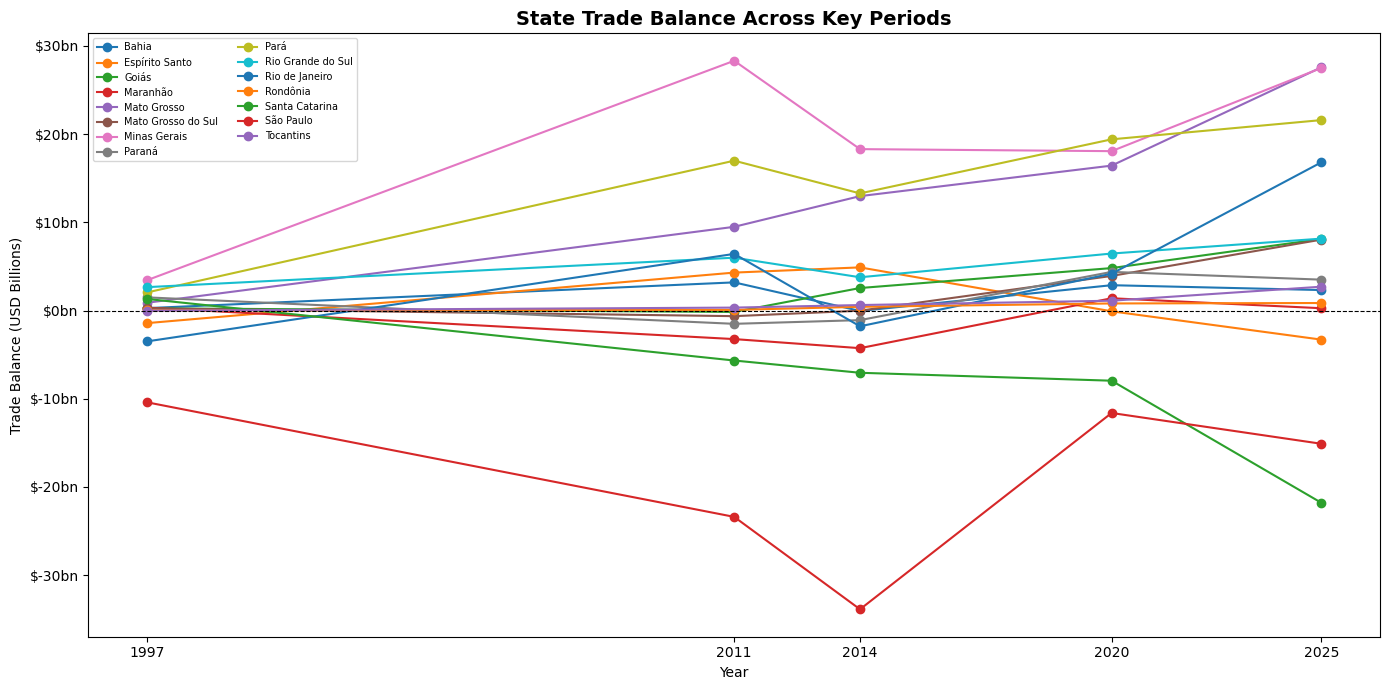


State trade balance across key periods (USD bn):
year                 1997   2011   2014   2020   2025
state                                                
Bahia                0.27   3.19  -0.05   2.87   2.32
Espírito Santo      -1.43   4.30   4.89  -0.09  -3.30
Goiás                0.25  -0.16   2.55   4.81   8.11
Maranhão             0.33  -3.24  -4.27   1.39   0.26
Mato Grosso          0.88   9.49  12.97  16.43  27.57
Mato Grosso do Sul   0.25  -0.64  -0.02   3.92   8.04
Minas Gerais         3.44  28.32  18.30  18.07  27.50
Paraná               1.49  -1.51  -1.09   4.38   3.50
Pará                 2.05  16.99  13.28  19.41  21.59
Rio Grande do Sul    2.65   5.99   3.77   6.46   8.15
Rio de Janeiro      -3.50   6.42  -1.79   4.17  16.80
Rondônia             0.02   0.07   0.42   0.80   0.85
Santa Catarina       1.31  -5.67  -7.06  -7.96 -21.80
São Paulo          -10.41 -23.40 -33.88 -11.62 -15.11
Tocantins           -0.02   0.33   0.62   1.11   2.70


In [6]:
## Key periods from Step 1 analysis
key_years = [1997, 2011, 2014, 2020, MAX_YEAR]

query_balance_periods = f"""
    SELECT year, uf, state,
           COALESCE(MAX(exports_usd), 0) - COALESCE(MAX(imports_usd), 0) AS balance_usd
    FROM (
        SELECT e."CO_ANO" AS year,
               u.sigla AS uf,
               u.nome_estado AS state,
               SUM(e."VL_FOB") AS exports_usd,
               NULL::numeric AS imports_usd
        FROM exp e
        JOIN uf u ON e."SG_UF_NCM" = u.sigla
        WHERE e."CO_ANO" IN ({','.join(map(str, key_years))})
        GROUP BY e."CO_ANO", u.sigla, u.nome_estado
        UNION ALL
        SELECT i."CO_ANO" AS year,
               u.sigla AS uf,
               u.nome_estado AS state,
               NULL::numeric AS exports_usd,
               SUM(i."VL_FOB") AS imports_usd
        FROM imp i
        JOIN uf u ON i."SG_UF_NCM" = u.sigla
        WHERE i."CO_ANO" IN ({','.join(map(str, key_years))})
        GROUP BY i."CO_ANO", u.sigla, u.nome_estado
    ) t
    GROUP BY year, uf, state
"""

df_periods = pd.read_sql(query_balance_periods, engine)
df_periods['balance_usd_bn'] = (df_periods['balance_usd'] / 1e9).round(2)

## Pivot: rows = states, columns = years
df_periods_pivot = df_periods.pivot(index='state', columns='year', values='balance_usd_bn').fillna(0)

## Focus on top 15 states by absolute balance in MAX_YEAR
top15_balance = df_state.nlargest(15, 'exports_usd_bn')['state'].tolist()
df_periods_plot = df_periods_pivot.loc[df_periods_pivot.index.isin(top15_balance)]

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(key_years))
width = 0.05
for i, state in enumerate(df_periods_plot.index):
    ax.plot(key_years, df_periods_plot.loc[state], marker='o', label=state, linewidth=1.5)

ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title("State Trade Balance Across Key Periods", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Trade Balance (USD Billions)")
ax.set_xticks(key_years)
ax.legend(loc='upper left', fontsize=7, ncol=2)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_4_state_balance_periods.png', dpi=150)
plt.show()

print("\nState trade balance across key periods (USD bn):")
print(df_periods_plot.to_string())

### Overall Pattern

The five key periods — 1997, 2011, 2014, 2020 and 2025 — capture Brazil's trade geography across three distinct macro-economic regimes: the pre-commodity boom baseline (1997), the commodity peak (2011), the recession trough (2014), the COVID year (2020) and the current position (2025).

### States That Strengthened Consistently

**Mato Grosso** is the standout — a monotonic surplus expansion from \\$0.88bn (1997) to \\$27.57bn (2025) without a single period of contraction. Every economic shock that disrupted other states left Mato Grosso's surplus intact or larger. Soybean demand from China has been the stabilising force across all periods.

**Pará** follows a similar pattern — \\$2.05bn (1997) to \\$21.59bn (2025) with only minor moderation at each shock. Iron ore demand held through both the 2014 recession and COVID-19, confirming Chinese infrastructure spending as the anchor for Pará's export revenues across three decades.

**Rio Grande do Sul** grew steadily from \\$2.65bn to \\$8.15bn with no deficit years across all five periods — the most consistently positive Sul state. Its diversified agro-industrial base provided resilience that commodity monoculture states achieved through China demand rather than diversification.

### States With Dramatic Reversals

**Minas Gerais** is the most dramatic story in the dataset. Its surplus surged to \\$28.32bn in 2011 — the highest single-state surplus in any period shown — before collapsing to \\$18.30bn in 2014 and holding at \\$18.07bn through COVID. The 2025 recovery to \\$27.50bn nearly matches the 2011 peak. The entire trajectory tracks global iron ore prices almost exactly.

**Rio de Janeiro** swung from -\\$3.50bn (1997) to +\\$6.42bn (2011), back to -\\$1.79bn (2014), then +\\$4.17bn (2020) and +\\$16.80bn (2025). The 2025 surplus is the largest in the state's recorded history — entirely driven by the pre-salt oil production ramp-up. In 1997 Rio de Janeiro was a net importer; by 2025 it is Brazil's fourth largest surplus state.

**Espírito Santo** reversed from +\\$4.89bn (2014) to -\\$3.30bn (2025) — a \\$8.19bn swing in 11 years. This is the sharpest deterioration of any surplus state in the dataset and likely reflects the increasing scale of iron ore transshipment imports through Vitória relative to its export revenues.

### The Persistent Deficits

**São Paulo** has run a deficit in every single period — from -\\$10.41bn (1997) to -\\$33.88bn (2014) and -\\$15.11bn (2025). The 2014 peak deficit reflects the overvalued Real attracting imports combined with weak export demand. The partial improvement to -\\$15.11bn by 2025 reflects the weaker Real improving export competitiveness. São Paulo will structurally remain a deficit state — its industrial economy requires imported inputs that cannot be substituted domestically.

**Santa Catarina** went from +\\$1.31bn (1997) to -\\$21.80bn (2025) — a \\$23.11bn deterioration over 28 years, the largest absolute deterioration of any state in the dataset. Every period shows a larger deficit than the previous one without exception. This is not a cyclical pattern — it is a structural and accelerating trend.

> ⚠️ *Santa Catarina's trade balance deterioration from +\\$1.31bn (1997) to -\\$21.80bn (2025) is the single most striking long-run trend at the state level in this dataset. The monotonic worsening across all five periods — including the COVID year — suggests a structural import dependency decoupled from economic cycles. Step 5 product-level import analysis is essential.*

### The Centro-Oeste Transformation

In 1997 Goiás and Mato Grosso do Sul barely registered in the surplus column (\\$0.25bn each). By 2025 they run surpluses of \\$8.11bn and \\$8.04bn respectively — driven entirely by MATOPIBA soybean expansion and improved logistics to Santos and Paranaguá ports.

| State | 1997 | 2025 | Change |
|---|---|---|---|
| Mato Grosso | +\\$0.88bn | +\\$27.57bn | +\\$26.69bn |
| Goiás | +\\$0.25bn | +\\$8.11bn | +\\$7.86bn |
| Mato Grosso do Sul | +\\$0.25bn | +\\$8.04bn | +\\$7.79bn |

> ⚠️ *Paraná's balance of -\\$1.51bn (2011) reverting to +\\$3.50bn (2025) suggests a structural shift in its export mix. The drivers — whether product diversification, new export markets or logistics upgrades — warrant specific investigation in Step 4.*


## 2.2 — State Export Growth Dynamics: Which States Are Rising and Falling?
Tracking the top 8 exporting states from 1997 to 2025 — identifying fast-growing emerging exporters, states in structural decline, and how key economic events impacted different states differently.

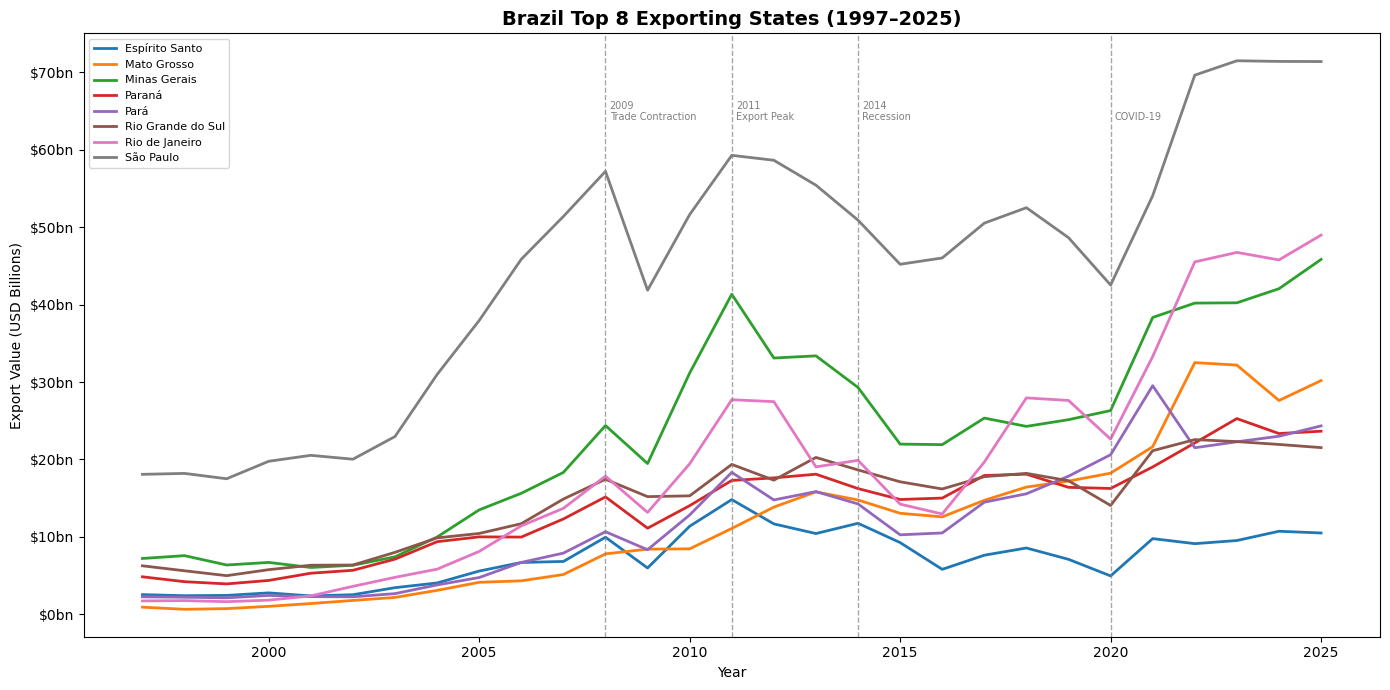

C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\1712018760.py:97: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x['exports_usd_bn'].idxmax(), ['year', 'exports_usd_bn']])


State Export Growth Summary — 1997 to 2025


C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\1712018760.py:187: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_pct, subset=pct_cols)


#,State,Region,Exports 1997 (USD bn),Exports 2025 (USD bn),Total Growth 1997–2025 (%),CAGR 1997–2025 (%),CAGR 2020–2025 — Last 5Y (%),YoY Growth 2024–2025 (%),Peak Year,Peak Exports (USD bn)
1,São Paulo,Southeast,$18.08,$71.39,+294.9%,+5.0%,+10.9%,-0.0%,2023,$71.49
2,Rio de Janeiro,Southeast,$1.73,$48.98,+2728.1%,+12.7%,+16.7%,+7.0%,2025,$48.98
3,Minas Gerais,Southeast,$7.22,$45.83,+535.0%,+6.8%,+11.7%,+9.0%,2025,$45.83
4,Mato Grosso,Center-West,$0.93,$30.19,+3157.0%,+13.2%,+10.6%,+9.3%,2022,$32.51
5,Pará,North,$2.26,$24.34,+975.2%,+8.9%,+3.4%,+5.8%,2021,$29.53
6,Paraná,South,$4.85,$23.65,+387.7%,+5.8%,+7.8%,+1.3%,2023,$25.28
7,Rio Grande do Sul,South,$6.27,$21.53,+243.5%,+4.5%,+8.9%,-1.9%,2022,$22.56
8,Goiás,Center-West,$0.48,$13.47,+2733.3%,+12.7%,+10.6%,+9.4%,2022,$14.15
9,Santa Catarina,South,$2.80,$12.20,+335.3%,+5.4%,+8.5%,+4.4%,2025,$12.20
10,Bahia,Northeast,$1.87,$11.63,+523.1%,+6.8%,+8.2%,-2.3%,2022,$13.92


In [4]:
query_state_time = f"""
    SELECT e."CO_ANO" AS year,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", u.nome_estado
    ORDER BY e."CO_ANO", exports_usd DESC
"""

df_state_time = pd.read_sql(query_state_time, engine)
df_state_time['exports_usd_bn'] = df_state_time['exports_usd'] / 1e9

top8_states = (
    df_state_time.groupby('state')['exports_usd']
    .sum().nlargest(8).index.tolist()
)

df_top8 = df_state_time[df_state_time['state'].isin(top8_states)]
df_pivot = df_top8.pivot(index='year', columns='state', values='exports_usd_bn').fillna(0)

## Annotate key periods identified in Step 1
events = {
    2009: ('2009\nTrade Contraction', 2008),
    2011: ('2011\nExport Peak',       2011),
    2014: ('2014\nRecession',         2014.0),
    2020: ('COVID-19',                2020)
}

fig, ax = plt.subplots(figsize=(14, 7))
for state in df_pivot.columns:
    ax.plot(df_pivot.index, df_pivot[state], label=state, linewidth=2)
for year, (label, xpos) in events.items():
    ax.axvline(x=xpos, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(xpos + 0.1, ax.get_ylim()[1] * 0.85, label, fontsize=7, color='gray')

ax.set_title(f"Brazil Top 8 Exporting States (1997–{MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.legend(loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
plt.tight_layout()
plt.savefig('output_2_2_state_exports_time.png', dpi=150)
plt.show()

## ── Growth summary table ─────────────────────────────────────────────────────
from IPython.display import display

region_map = (
    df_state[['state', 'region']]
    .drop_duplicates()
    .assign(region=lambda d: d['region'].map({
        'REGIAO NORDESTE'     : 'Northeast',
        'REGIAO NORTE'        : 'North',
        'REGIAO SUDESTE'      : 'Southeast',
        'REGIAO CENTRO OESTE' : 'Center-West',
        'REGIAO SUL'          : 'South',
        'REGIAO NAO DECLARADA': 'Undeclared'
    }).fillna(d['region']))
)

exclude_states = [
    'Não Declarada', 'Exterior',
    'Consumo de Bordo', 'Mercadoria Nacionalizada',
    'Reexportação', 'Zona Não Declarada'
]
df_growth = df_state_time[~df_state_time['state'].isin(exclude_states)].copy()

val_1997 = (
    df_growth[df_growth['year'] == 1997]
    .set_index('state')['exports_usd_bn']
    .rename('val_1997')
)
val_2025 = (
    df_growth[df_growth['year'] == MAX_YEAR]
    .set_index('state')['exports_usd_bn']
    .rename('val_2025')
)
val_prev = (
    df_growth[df_growth['year'] == MAX_YEAR - 1]
    .set_index('state')['exports_usd_bn']
    .rename('val_prev')
)
val_2020 = (
    df_growth[df_growth['year'] == MAX_YEAR - 5]
    .set_index('state')['exports_usd_bn']
    .rename('val_2020')
)

yoy_growth = (
    (val_2025 / val_prev.reindex(val_2025.index).replace(0, float('nan'))) - 1
) * 100

peak = (
    df_growth.groupby('state')
    .apply(lambda x: x.loc[x['exports_usd_bn'].idxmax(), ['year', 'exports_usd_bn']])
    .rename(columns={'year': 'peak_year', 'exports_usd_bn': 'peak_val_usd_bn'})
)

n_full   = MAX_YEAR - 1997
n_recent = 5

cagr_full = (
    (val_2025 / val_1997.reindex(val_2025.index).replace(0, float('nan'))) ** (1 / n_full) - 1
) * 100

cagr_recent = (
    (val_2025 / val_2020.reindex(val_2025.index).replace(0, float('nan'))) ** (1 / n_recent) - 1
) * 100

total_growth = (
    (val_2025 / val_1997.reindex(val_2025.index).replace(0, float('nan'))) - 1
) * 100

df_summary = pd.DataFrame({
    'exports_1997_usd_bn'       : val_1997,
    'exports_2025_usd_bn'       : val_2025,
    'total_growth_1997_2025_pct': total_growth,
    'cagr_1997_2025_pct'        : cagr_full,
    'cagr_2020_2025_pct'        : cagr_recent,
    'yoy_growth_2024_2025_pct'  : yoy_growth,
    'peak_year'                 : peak['peak_year'],
    'peak_exports_usd_bn'       : peak['peak_val_usd_bn'],
}).reset_index().rename(columns={'index': 'state'})

df_summary = df_summary.merge(region_map, on='state', how='left')
df_summary = df_summary.sort_values('exports_2025_usd_bn', ascending=False).reset_index(drop=True)
df_summary.insert(0, 'rank_2025', df_summary.index + 1)

for col in ['exports_1997_usd_bn', 'exports_2025_usd_bn', 'peak_exports_usd_bn']:
    df_summary[col] = df_summary[col].round(2)
for col in ['total_growth_1997_2025_pct', 'cagr_1997_2025_pct',
            'cagr_2020_2025_pct', 'yoy_growth_2024_2025_pct']:
    df_summary[col] = df_summary[col].round(1)
df_summary['peak_year'] = df_summary['peak_year'].astype('Int64')

## ── Styled display ───────────────────────────────────────────────────────────
df_display = df_summary[[
    'rank_2025', 'state', 'region',
    'exports_1997_usd_bn', 'exports_2025_usd_bn',
    'total_growth_1997_2025_pct',
    'cagr_1997_2025_pct',
    'cagr_2020_2025_pct',
    'yoy_growth_2024_2025_pct',
    'peak_year', 'peak_exports_usd_bn'
]].copy()

df_display.columns = [
    '#', 'State', 'Region',
    'Exports 1997 (USD bn)', 'Exports 2025 (USD bn)',
    'Total Growth 1997–2025 (%)',
    'CAGR 1997–2025 (%)',
    'CAGR 2020–2025 — Last 5Y (%)',
    'YoY Growth 2024–2025 (%)',
    'Peak Year', 'Peak Exports (USD bn)'
]

pct_cols = [
    'Total Growth 1997–2025 (%)',
    'CAGR 1997–2025 (%)',
    'CAGR 2020–2025 — Last 5Y (%)',
    'YoY Growth 2024–2025 (%)'
]

def color_pct(val):
    if pd.isna(val):
        return 'color: gray'
    return 'color: #2e7d32' if val >= 0 else 'color: #c62828'

styled = (
    df_display.style
    .set_properties(**{
        'font-size' : '12px',
        'text-align': 'right',
        'padding'   : '4px 10px',
        'white-space': 'nowrap',
    })
    .set_properties(subset=['State', 'Region'], **{
        'text-align': 'left',
    })
    .set_properties(subset=['#'], **{
        'text-align': 'center',
        'color'     : 'gray',
        'font-size' : '11px',
    })
    .applymap(color_pct, subset=pct_cols)
    .format({
        'Exports 1997 (USD bn)'          : lambda x: f'${x:.2f}' if pd.notna(x) else '—',
        'Exports 2025 (USD bn)'          : lambda x: f'${x:.2f}' if pd.notna(x) else '—',
        'Peak Exports (USD bn)'          : lambda x: f'${x:.2f}' if pd.notna(x) else '—',
        'Total Growth 1997–2025 (%)'     : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'CAGR 1997–2025 (%)'             : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'CAGR 2020–2025 — Last 5Y (%)'  : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'YoY Growth 2024–2025 (%)'       : lambda x: f'{x:+.1f}%' if pd.notna(x) else '—',
        'Peak Year'                      : lambda x: str(int(x)) if pd.notna(x) else '—',
    })
    .set_table_styles([
        {'selector': 'thead th', 'props': [
            ('background-color', '#f5f5f5'),
            ('font-size', '11px'),
            ('font-weight', 'bold'),
            ('text-align', 'center'),
            ('padding', '6px 10px'),
            ('border-bottom', '2px solid #ddd'),
            ('white-space', 'nowrap'),
        ]},
        {'selector': 'tbody tr:nth-child(even)', 'props': [
            ('background-color', '#fafafa'),
        ]},
        {'selector': 'tbody tr:hover', 'props': [
            ('background-color', '#f0f4ff'),
        ]},
        {'selector': 'td, th', 'props': [
            ('border-bottom', '1px solid #eee'),
        ]},
        {'selector': 'table', 'props': [
            ('border-collapse', 'collapse'),
            ('width', '100%'),
            ('font-family', 'monospace'),
        ]},
    ])
    .hide(axis='index')
)

print(f"State Export Growth Summary — 1997 to {MAX_YEAR}")
display(styled)

### Overview

**São Paulo (\\$18.08bn → \\$71.39bn, CAGR +5.0%)** has been the dominant exporter throughout the period. Growth has been consistent rather than cycle-driven — the post-2020 trajectory is steeper than any prior period. The last 5Y CAGR of +10.9% is materially above the full-period CAGR, confirming this acceleration. The near-zero YoY figure for 2024–2025 suggests a recent slowdown in growth.

**Rio de Janeiro (\\$1.73bn → \\$48.98bn, CAGR +12.7%)** records the highest full-period CAGR among large exporters — a result of its near-zero 1997 base. Its peak year is 2025 and last 5Y CAGR of +16.7% confirms post-2020 growth is ongoing. Unlike Minas Gerais it did not show a pronounced peak around 2011.

**Minas Gerais (\\$7.22bn → \\$45.83bn, CAGR +6.8%)** shows a clear cyclical pattern — strong growth to 2011, followed by contraction through 2015–2016, and recovery to a new peak in 2025. The +11.7% last 5Y CAGR and +9.0% YoY indicate that this recovery is ongoing.

**Mato Grosso (\\$0.93bn → \\$30.19bn, CAGR +13.2%)** peaked at \\$32.51bn in 2022 before moderating to $30.19bn by 2025. The +10.6% last 5Y CAGR and +9.3% YoY indicate continued growth.

**Pará (\\$2.26bn → \\$24.34bn, CAGR +8.9%)** peaked in 2021 at \\$29.53bn — a \\$5bn gap to its 2025 value, the largest peak-to-current divergence among the top 10. Its trajectory shows moderate growth to 2011, contraction through 2014–2016, recovery post-2017, and lower values after 2021. The +3.4% last 5Y CAGR is the weakest among the top 10 states.

**The Southern states (Paraná +5.8%, Rio Grande do Sul +4.5%, Santa Catarina +5.4%)** have the three most similar full-period CAGRs of any region — a quantitative confirmation of the structural coherence identified in Step 2b. All three show last 5Y CAGRs materially above their full-period figures (+7.8%, +8.9%, +8.5% respectively), consistent with post-COVID recovery. Neither Paraná nor Rio Grande do Sul do not exhibit the pronounced peaks and contractions through 2014–2016, recovery post-2017, and lower values after 2021. Rio Grande do Sul's -1.9% YoY is the only negative figure in the Sul cluster and warrants monitoring.

**Espírito Santo (\\$2.55bn → \\$10.51bn, CAGR +5.2%)** peaked in 2011 at \\$14.82bn and remains below that level in 2025 — the only top-12 state still below its historical peak. The combination of a +16.2% last 5Y CAGR and -2.1% YoY indicates strong recent growth followed by a decline in the most recent year.

**Macroeconomic events are visible across all states simultaneously.** The 2014 recession produced a contraction or flattening across every state between 2013 and 2016 — confirming it was a national rather than state-specific event. The 2009 trade contraction is visible as a brief dip before rapid recovery. COVID-19 produced a noticeably smaller disruption than 2014 — consistent with the Step 1 finding that Brazil's goods trade was resilient during the pandemic.

**The small-state growth figures require context.** Tocantins (+22.8% CAGR), Acre (+24.7%) and Rondônia (+17.1%) record the highest CAGRs in the dataset — a direct result of near-zero 1997 bases. These are not analytically comparable to large-state CAGRs and should be read alongside absolute values (\\$3.05bn, \\$0.10bn and $3.09bn respectively).

**Ceará's +55.6% YoY is the most anomalous single-year figure in the table** — a rise from approximately \\$1.47bn in 2024 to \\$2.28bn in 2025. Sergipe’s +62.6% last 5Y CAGR is similarly high relative to its absolute value (\\$0.45bn). These changes cannot be explained using aggregate data at this level of analysis.


>*⚠️ Three figures warrant specific follow-up in Step 5: Ceará's +55.6% YoY, Sergipe's +62.6% last 5Y CAGR, and Pará's \\$5bn gap to its 2021 peak. All three cannot be resolved from aggregate trade flow data alone.*

---
---

## 2.3 — Regional Export and Import Distribution

### 2.3.1 — Regional Export Distribution: How Brazil's Five Macro-Regions Compare
Breaking down export value and share by Brazil's five macro-regions (Norte, Nordeste, Centro-Oeste, Sudeste, Sul) from 1997 to 2025 — showing which regions have gained or lost export share over 30 years.

### Headline Shift

Brazil's regional export geography has undergone a significant structural rebalancing over 28 years. The two traditionally dominant regions — Sudeste and Sul — both lost share, while Centro-Oeste surged from near-irrelevance to become the third largest export region in Brazil.

| Region | 1997 (%) | 2025 (%) | Change (pp) |
|---|---|---|---|
| Sudeste | 55.9% | 50.7% | -5.1 |
| Sul | 26.3% | 16.5% | **-9.8** |
| Centro-Oeste | 3.4% | 15.7% | **+12.3** |
| Norte | 4.9% | 9.2% | +4.3 |
| Nordeste | 7.5% | 7.3% | -0.2 |

### The Centro-Oeste Surge (+12.3pp)

The most consequential shift in Brazil's regional trade geography. Centro-Oeste went from exporting \\$1.9bn (3.4% of national total) in 1997 to approximately \\$55bn (15.7%) in 2025 — a nearly 29x increase in absolute value. This is the MATOPIBA story quantified at the regional level: Mato Grosso, Goiás and Mato Grosso do Sul collectively transformed from a marginal export region into the engine of Brazil's agricultural export growth. The acceleration is visible in the absolute value chart — the orange Centro-Oeste line is flat through 2005, then rises sharply and accelerates further post-2015.

### The Sul Decline (-9.8pp)

The largest share loss of any region in the dataset — from 26.3% to 16.5%. Critically this is a share loss, not an absolute decline. Sul exports grew in absolute terms from approximately \\$14.5bn to \\$57.4bn — but grew far more slowly than the national average, particularly relative to the commodity-driven Centro-Oeste expansion. The Sul lost share not because it weakened but because the agricultural frontier grew faster. In absolute terms Sul remains the second largest export region; in relative terms it has been structurally displaced.

### The Sudeste Consolidation (-5.1pp)

Sudeste remains dominant at 50.7% but its share erosion from 55.9% reflects the same dynamic — São Paulo and Minas Gerais grew in absolute terms but the national total grew faster. The Sudeste still accounts for more exports than all other regions combined, and its absolute export value nearly tripled from 1997 to 2025. The share loss is a reflection of Brazil's export base broadening rather than Sudeste weakening.

### Norte Growth (+4.3pp)

Norte doubled its share from 4.9% to 9.2%, driven primarily by Pará's iron ore expansion and Amazonas's manufactured goods. In absolute terms Norte exports grew from approximately \\$2.7bn to \\$32bn. The acceleration is most visible post-2015 as the Carajás mining complex and pre-salt oil operations in the north expanded.

### Nordeste Stability (-0.2pp)

The Nordeste is the most stable region across the full period — 7.5% in 1997, 7.3% in 2025, a negligible change of -0.2pp. In absolute terms Nordeste exports grew from approximately \\$4.1bn to \\$25.4bn. The region grew proportionally with the national average despite having a structurally different export base. This masks significant internal heterogeneity — Bahia and Maranhão drove most of the growth while smaller Nordeste states remained static.

### Non-Geographic Categories

REGIAO NAO DECLARADA declined from 1.6% to 0.7%, suggesting gradual improvement in state-level trade recording. MERCADORIA NACIONALIZADA and REEXPORTACAO are both effectively zero by 2025.

> ⚠️ *The Sul's -9.8pp share loss is the most significant regional rebalancing finding in Step 2. It does not indicate industrial decline but rather that Brazil's export growth engine shifted from the diversified Sul manufacturing and agribusiness base toward the bulk agricultural commodity production of the Centro-Oeste interior. These are structurally different growth models with different implications for value-added content, employment and long-run competitiveness.*


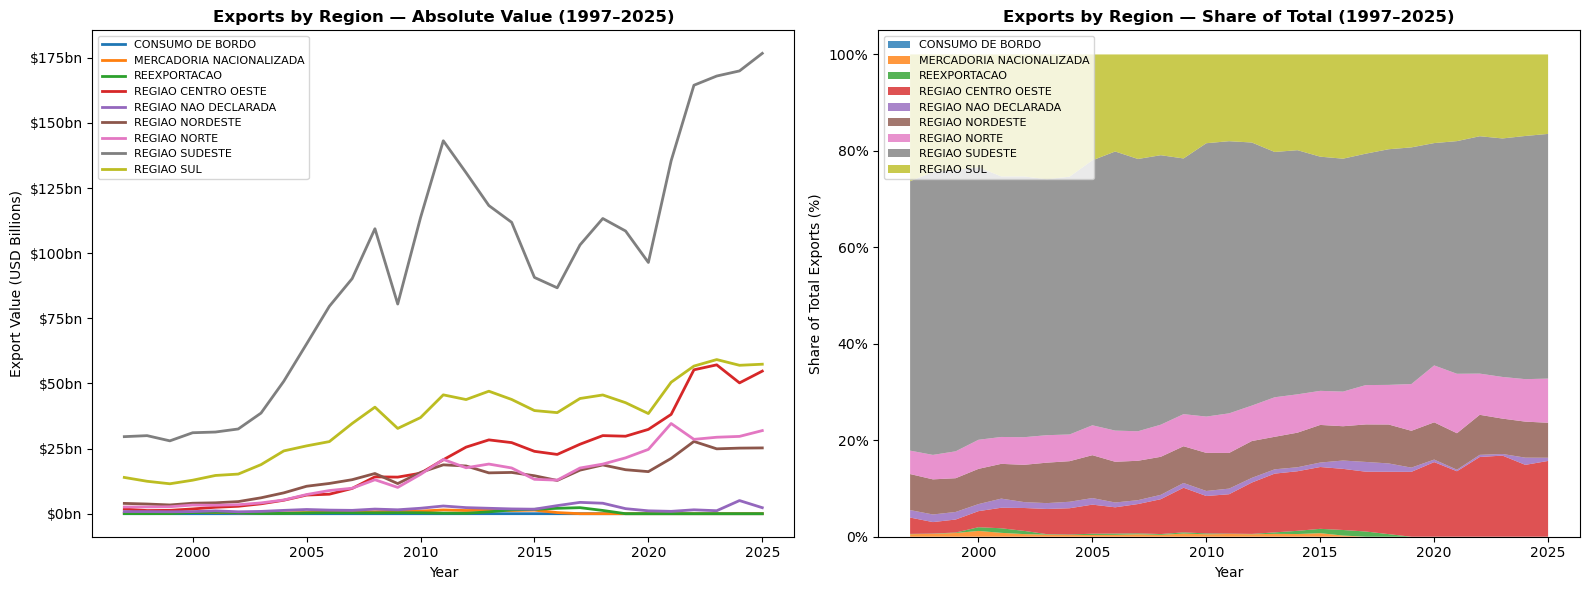


Regional export share — 1997 vs 2025
                  Region  1997 (%)  2025 (%)  Change (pp)
          REGIAO SUDESTE      55.9      50.7         -5.1
              REGIAO SUL      26.3      16.5         -9.8
     REGIAO CENTRO OESTE       3.4      15.7         12.3
            REGIAO NORTE       4.9       9.2          4.3
         REGIAO NORDESTE       7.5       7.3         -0.2
    REGIAO NAO DECLARADA       1.6       0.7         -0.9
        CONSUMO DE BORDO       0.0       0.0          0.0
MERCADORIA NACIONALIZADA       0.5       0.0         -0.5
            REEXPORTACAO       0.1       0.0         -0.1


In [7]:
query_region = f"""
    SELECT e."CO_ANO" AS year,
           u.nome_regiao AS region,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", u.nome_regiao
    ORDER BY e."CO_ANO"
"""

df_region = pd.read_sql(query_region, engine)
df_region['exports_usd_bn'] = df_region['exports_usd'] / 1e9
df_region_pivot = df_region.pivot(index='year', columns='region', values='exports_usd_bn').fillna(0)
df_region_pct   = df_region_pivot.div(df_region_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
for region in df_region_pivot.columns:
    ax1.plot(df_region_pivot.index, df_region_pivot[region], label=region, linewidth=2)
ax1.set_title(f"Exports by Region — Absolute Value (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Export Value (USD Billions)")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

ax2.stackplot(df_region_pct.index, df_region_pct.T, labels=df_region_pct.columns, alpha=0.8)
ax2.set_title(f"Exports by Region — Share of Total (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of Total Exports (%)")
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('output_2_5_region_exports.png', dpi=150)
plt.show()

start_year = df_region_pct.index[0]
summary_region = pd.DataFrame({
    'Region'            : df_region_pct.columns,
    f'{start_year} (%)' : df_region_pct.loc[start_year].round(1).values,
    f'{MAX_YEAR} (%)'   : df_region_pct.loc[MAX_YEAR].round(1).values,
    'Change (pp)'       : (df_region_pct.loc[MAX_YEAR] - df_region_pct.loc[start_year]).round(1).values
})
print(f"\nRegional export share — {start_year} vs {MAX_YEAR}")
print(summary_region.sort_values(f'{MAX_YEAR} (%)', ascending=False).to_string(index=False))

### 2.3.2 — Regional Import Distribution: Where Brazil's Five Macro-Regions Source From
Mirroring the export analysis — how import value and share are distributed across Brazil's five macro-regions, and how that distribution has shifted over 30 years.How are exports distributed across Brazil's five macro-regions? How has this shifted from 1997 to 2025?

### Headline Shift

The import side tells a fundamentally different story from exports. While exports rebalanced toward the interior (Centro-Oeste surge), imports have rebalanced toward the coast — with Sul gaining dramatically and Sudeste losing share despite remaining dominant.

| Region | 1997 (%) | 2025 (%) | Change (pp) |
|---|---|---|---|
| Sudeste | 68.5% | 53.8% | **-14.7** |
| Sul | 14.0% | 24.1% | **+10.1** |
| Nordeste | 7.0% | 9.7% | +2.7 |
| Norte | 7.6% | 7.8% | +0.2 |
| Centro-Oeste | 1.1% | 4.6% | +3.5 |

### The Sudeste Import Dominance — and Its Decline (-14.7pp)

Sudeste remains by far the largest import region at 53.8% but its -14.7pp share loss is the largest regional shift on the import side — nearly three times the magnitude of its export share loss (-5.1pp). In absolute terms Sudeste imports grew substantially in USD — from approximately \\$40bn to \\$150bn — but the absolute growth chart shows the Sudeste line flattening noticeably post-2015 while Sul accelerated sharply. The 2020–2022 spike visible in the absolute value chart reflects pandemic-related import surges in consumer goods and medical equipment concentrated in São Paulo.

### The Sul Import Surge (+10.1pp)

The most striking finding on the import side. Sul went from 14.0% to 24.1% — a +10.1pp gain that mirrors in magnitude (if not in direction) the Centro-Oeste export surge. In absolute terms Sul imports grew from approximately \\$8bn (1997) to approximately \\$68bn (2025) — an 8.5x increase compared to approximately 3.75x for the national total. Santa Catarina's \\$33.99bn import figure is the primary driver of this surge — its anomalous deficit identified in cells 2.1 and 2.3 is now visible at the regional level as a systematic reweighting of Brazil's import geography toward the Sul coast.

The absolute value chart confirms this — the yellow Sul line is flat and low from 1997 to approximately 2015, then accelerates sharply, particularly post-2020. This trajectory is too steep and too recent to reflect gradual industrial growth — it suggests a structural change in how Sul states source goods, possibly related to port infrastructure expansion at Navegantes and Itajaí in Santa Catarina.

### Comparing Export and Import Regional Shifts

| Region | Export share change | Import share change | Net interpretation |
|---|---|---|---|
| Sudeste | -5.1pp | -14.7pp | Losing both export and import share — diversification of Brazil's trade geography |
| Sul | -9.8pp | +10.1pp | Losing export share, gaining import share — becoming a net import region |
| Centro-Oeste | +12.3pp | +3.5pp | Gaining export share faster than import share — growing surplus region |
| Norte | +4.3pp | +0.2pp | Gaining export share, stable import share — growing surplus region |
| Nordeste | -0.2pp | +2.7pp | Stable exports, growing imports — moderate import dependency growth |

The most structurally significant contrast is Sul — it is simultaneously losing export share and gaining import share, which means its trade balance is deteriorating at the regional level. This is entirely consistent with the Santa Catarina deficit finding, which alone is large enough to move the entire Sul regional import share.

### Norte Import Stability (+0.2pp)

Norte's import share held virtually flat at 7.6%→7.8% despite its export share growing from 4.9% to 9.2%. This confirms that Norte's export growth is genuinely surplus-generating — it is not importing significantly more to produce those exports. The exception is Amazonas (\\$16.06bn imports) which is captured within the Norte total — without Amazonas, Norte's import share would be dramatically lower.

### Centro-Oeste Import Growth (+3.5pp)

Centro-Oeste grew from 1.1% to 4.6% of imports — a significant relative increase but still far below its 15.7% export share. The region remains a strong net surplus generator. Import growth likely reflects agricultural inputs (fertilisers, machinery, agrochemicals) required to sustain the soybean frontier expansion — imports that are a direct input cost of the export growth documented in cell 2.5.1.

> ⚠️ *The Sul import surge from 14.0% to 24.1% is the most unresolved finding in the regional import analysis. It cannot be explained by population or economic growth alone — Sul accounts for approximately 15% of Brazil's GDP but 24% of its imports. Santa Catarina's \\$33.99bn import figure is the primary driver but the product-level breakdown of what is being imported and why requires Step 5 investigation.*

> ⚠️ *REGIAO NAO DECLARADA declining from 1.7% to effectively 0% on the import side — compared to 1.6% to 0.7% on the export side — suggests import origin recording improved more dramatically than export origin recording over the period. This is consistent with customs digitisation efforts that typically improve import documentation before export documentation.*


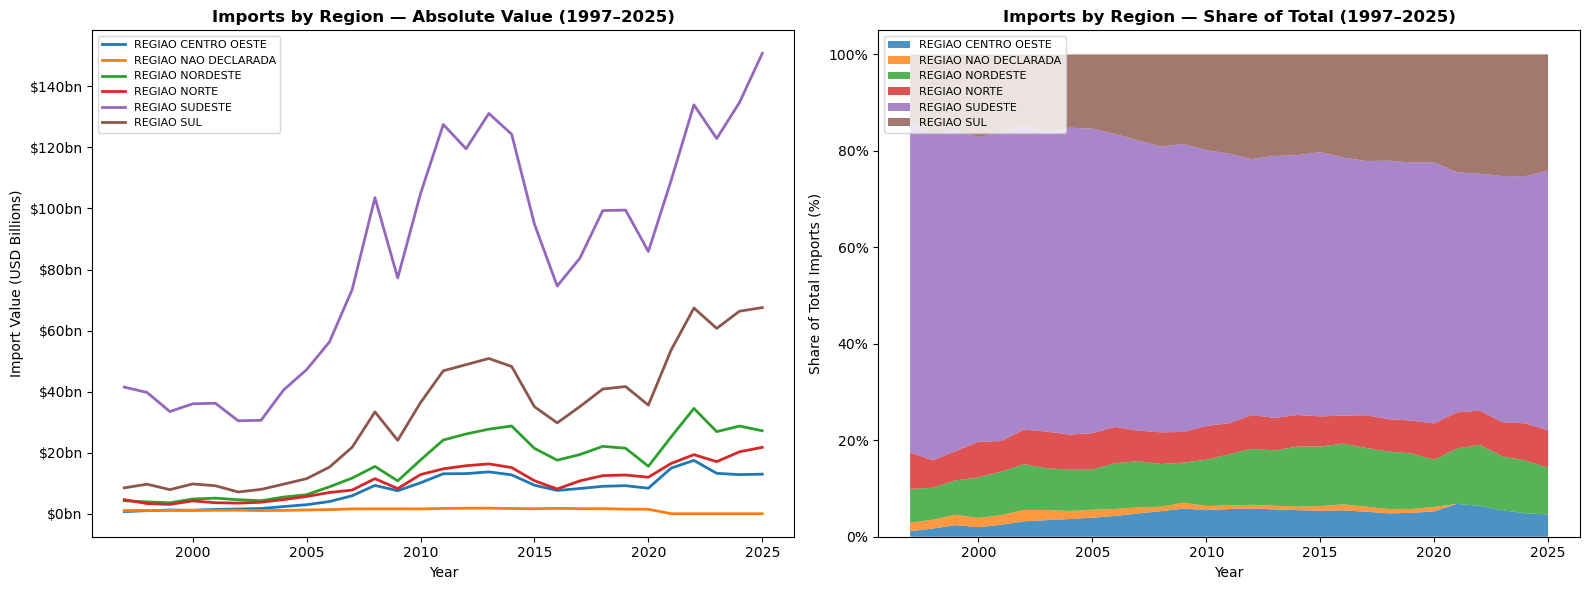


Regional import share — 1997 vs 2025
              Region  1997 (%)  2025 (%)  Change (pp)
      REGIAO SUDESTE      68.5      53.8        -14.7
          REGIAO SUL      14.0      24.1         10.1
     REGIAO NORDESTE       7.0       9.7          2.7
        REGIAO NORTE       7.6       7.8          0.2
 REGIAO CENTRO OESTE       1.1       4.6          3.5
REGIAO NAO DECLARADA       1.7       0.0         -1.7


In [8]:
query_region_imp = f"""
    SELECT i."CO_ANO" AS year,
           u.nome_regiao AS region,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    WHERE i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", u.nome_regiao
    ORDER BY i."CO_ANO"
"""

df_region_imp = pd.read_sql(query_region_imp, engine)
df_region_imp['imports_usd_bn'] = df_region_imp['imports_usd'] / 1e9
df_region_imp_pivot = df_region_imp.pivot(index='year', columns='region', values='imports_usd_bn').fillna(0)
df_region_imp_pct   = df_region_imp_pivot.div(df_region_imp_pivot.sum(axis=1), axis=0) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for region in df_region_imp_pivot.columns:
    ax1.plot(df_region_imp_pivot.index, df_region_imp_pivot[region], label=region, linewidth=2)
ax1.set_title(f"Imports by Region — Absolute Value (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax1.set_xlabel("Year")
ax1.set_ylabel("Import Value (USD Billions)")
ax1.legend(fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))

ax2.stackplot(df_region_imp_pct.index, df_region_imp_pct.T, labels=df_region_imp_pct.columns, alpha=0.8)
ax2.set_title(f"Imports by Region — Share of Total (1997–{MAX_YEAR})", fontsize=12, fontweight='bold')
ax2.set_xlabel("Year")
ax2.set_ylabel("Share of Total Imports (%)")
ax2.legend(loc='upper left', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

plt.tight_layout()
plt.savefig('output_2_5b_region_imports.png', dpi=150)
plt.show()

start_year = df_region_imp_pct.index[0]
summary_region_imp = pd.DataFrame({
    'Region'            : df_region_imp_pct.columns,
    f'{start_year} (%)' : df_region_imp_pct.loc[start_year].round(1).values,
    f'{MAX_YEAR} (%)'   : df_region_imp_pct.loc[MAX_YEAR].round(1).values,
    'Change (pp)'       : (df_region_imp_pct.loc[MAX_YEAR] - df_region_imp_pct.loc[start_year]).round(1).values
})
print(f"\nRegional import share — {start_year} vs {MAX_YEAR}")
print(summary_region_imp.sort_values(f'{MAX_YEAR} (%)', ascending=False).to_string(index=False))

## 2.4 — Export Sector Structure: What Brazil's States and Regions Actually Sell

### 2.4.1 — Top 10 Export Sectors by State (SH2): Ranked Table with Share of State Total
For every state, the top 10 export sectors by SH2 classification ranked by value — each showing its share of that state's total exports.

### The Five Dominant Export Profiles

Across all 27 states the SH2 sector data reveals five structurally distinct export profiles:

**1. Soybean-dominant agricultural states**
Piauí (82.8% soybeans), Mato Grosso (43.6%), Tocantins (53.3% soybeans + cereals), Rondônia (50.3% meat + 32.7% soybeans), Goiás (38.7% soybeans + 20.3% meat). Every Centro-Oeste state and most frontier Norte/Nordeste states fall into this category. The sector diversity within the top 10 is minimal — typically 3–4 agricultural categories account for 80%+ of total exports.

**2. Mineral extraction states**
Pará (64.6% ores and slag), Minas Gerais (27.0% ores + 10.2% iron and steel), Espírito Santo (28.2% ores + 13.6% iron and steel). These states are defined by iron ore and metallic minerals with secondary coffee or steel presence.

**3. Oil and gas states**
Rio de Janeiro (83.3% mineral fuels) and Sergipe (61.9% mineral fuels) and Rio Grande do Norte (52.7% mineral fuels) all have hydrocarbon dominance. Rio de Janeiro is the most extreme — \\$40.79bn out of \\$48.98bn total exports is a single SH2 chapter.

**4. Diversified industrial states**
São Paulo, Rio Grande do Sul, Paraná and Santa Catarina show the widest spread across sectors. São Paulo's top 10 sectors span sugar, vehicles, petroleum products, machinery, aerospace, meat, food preparations, electrical equipment, soybeans and pulp — no single sector exceeds 12% of total exports. Rio Grande do Sul similarly covers soybeans, tobacco, meat, animal feed, vehicles, cereals, machinery, pulp, plastics and footwear within its top 10.

**5. Transition states**
Bahia, Mato Grosso do Sul, Maranhão and Pernambuco show hybrid profiles — one or two commodity anchors combined with emerging industrial or processed goods sectors. Bahia's top 10 spans soybeans, petroleum, pulp, precious stones, cotton, ores, cocoa, coffee, animal feed and organic chemicals — the most genuinely diversified export basket among mid-sized states.

---

### State-by-State Highlights

**São Paulo — the only truly diversified large exporter.** No sector exceeds 12% of total exports. The top 10 sectors span six distinct economic domains: agricultural commodities (sugar, soybeans, meat), industrial goods (vehicles, machinery, electrical), energy (petroleum products), high technology (aerospace, \\$4.54bn at 6.4%), food processing and forestry products. This breadth is unique among Brazil's top exporters and reflects São Paulo's role as Brazil's industrial capital.

**Rio de Janeiro — the oil monoculture at scale.** SH27 mineral fuels at 83.3% (\\$40.79bn) makes Rio de Janeiro the most concentrated large exporter in Brazil. The remaining 9 sectors in the top 10 collectively account for less than \\$5bn. Iron and steel (\\$2.09bn, 4.3%) and machinery (\\$1.85bn, 3.8%) are distant second and third — both likely linked to offshore oil infrastructure rather than independent industrial sectors.

**Minas Gerais — coffee and iron ore in near-equal weight.** The combination of ores/slag (\\$12.37bn, 27.0%) and coffee (\\$11.29bn, 24.6%) gives Minas Gerais the most analytically interesting top-2 pairing in the dataset — a world-class mineral exporter and a world-class coffee exporter simultaneously. Iron and steel (\\$10.2%), precious stones (\\$7.2%) and soybeans (\\$6.0%) complete a genuinely multi-sector profile. Despite its high HHI from Step 2b, the actual sector composition is more diverse than most states.

**Mato Grosso — four agricultural sectors, 94% of exports.** Soybeans (43.6%), cereals (15.5%), meat (14.8%) and cotton (10.4%) account for 84.3% alone. Animal feed adds another 9.8%. The remaining 5 sectors in the top 10 collectively contribute less than 4%. This is Brazil's most agriculturally monoculture state profile at meaningful export scale.

**Pará — iron ore at 64.6% with a long tail.** After ores and slag (\\$15.73bn), the next sector is inorganic chemicals (\\$2.30bn, 9.4%) — likely aluminium processing inputs. Soybeans (6.8%) and meat (5.0%) reflect the diversification of Pará's economy beyond mining, but iron ore dominance is unambiguous.

**Paraná — the most balanced agro-industrial profile.** Soybeans (19.6%) and meat (18.6%) anchor the agricultural side, but vehicles (9.0%), machinery (5.4%), sugar (5.2%), cereals (5.0%), timber (4.6%), paper (3.6%) and petroleum (3.2%) give Paraná a genuinely diversified industrial tail. No single sector dominates, and the spread between agricultural and industrial sectors is the most even of any major exporter.

**Santa Catarina — meat and machinery.** Meat (34.1%, \\$4.16bn) is the largest single sector but the remaining 9 positions span machinery (10.7%), timber (10.0%), electrical equipment (9.7%), soybeans (5.4%), paper (3.0%), processed meat (2.8%), furniture (2.3%), tobacco (2.2%) and vehicles (1.9%). This is a genuinely industrial profile with a large agricultural anchor — consistent with Santa Catarina's high-value industrial logistics classification in Step 2b.

**Pernambuco — vehicles dominate unexpectedly.** Vehicles and tractors (39.7%, \\$1.01bn) is the largest sector — reflecting the Jeep/Stellantis manufacturing plant in Goiana (Pernambuco's automotive hub). Sugar (14.3%), petroleum (13.9%) and fruit (12.8%) fill the remaining top positions. The vehicle dominance explains Pernambuco's high USD/kg value density (\\$1.17/kg) identified in Step 2b — automotive exports generate significantly more value per kg than agricultural commodities.

**Amazonas — the Zona Franca product mix.** Food preparations (22.4%), precious stones (18.0%), iron and steel (15.3%) and vehicles/motorcycles (14.9%) reflect the Zona Franca manufacturing cluster. The precious stones figure (\\$0.17bn) likely reflects gemstone processing. The vehicle category is predominantly motorcycles (Honda manufactures in Manaus). Electrical equipment (6.8%) and machinery (3.8%) reflect electronics manufacturing. This is the only state where SH categories reflect manufacturing assembly rather than primary production.

**Ceará — iron and steel dominates surprisingly.** SH72 ferro fundido at 51.8% (\\$1.18bn) is unexpected for a Nordeste state. This likely reflects steel semi-finished product processing at the port of Pecém rather than integrated steelmaking. Footwear (8.3%) and fruit (8.0%) are secondary anchors consistent with Ceará's traditional industrial and agricultural profiles.

**Bahia — the most diversified mid-sized exporter.** Ten genuinely distinct sectors each contributing between 2.7% and 20.0% — the widest spread of any state outside São Paulo. Soybeans (20.0%), petroleum (16.6%), pulp (11.5%), precious stones (9.5%), cotton (8.0%), ores (4.8%), cocoa (4.7%), coffee (4.2%), animal feed (4.0%) and organic chemicals (2.7%). The Camaçari petrochemical complex, Bahia's agricultural diversity and its mining sector combine to produce a unique multi-domain export profile.

---

### Cross-Cutting Observations

**SH12 (soybeans and oilseeds) appears in the top 10 of 24 of 27 states.** It is Brazil's most universally present export sector — the agricultural foundation that underpins trade across every region. Even industrial states like São Paulo (\\$2.25bn, 3.1%) and Santa Catarina (\\$0.66bn, 5.4%) export meaningful soybean volumes.

**SH2 (meat) appears in the top 10 of 19 states.** Brazil's beef, poultry and pork exports are geographically distributed across the country — from Acre (47.5% of tiny total) to São Paulo (5.2% of enormous total). The meat sector is the second most universally present export category.

**SH72 (iron and steel) appears in 15 states**, reflecting both primary steel production (Minas Gerais, Espírito Santo) and downstream steel product exports distributed through industrial centres.

**Only São Paulo, Paraná and Rio Grande do Sul have a genuine top-10 spread across more than four economic domains.** Every other state's top 10 is dominated by 2–3 commodity clusters with a thin industrial tail.

> ⚠️ *Ceará's iron and steel dominance (51.8%) requires product-level NCM investigation in Step 5. At \\$1.18bn this is a material export volume for a Nordeste state and the SH2 category alone does not clarify whether this is primary steelmaking, semi-finished products or steel-containing manufactured goods.*

> ⚠️ *The SH71 "precious stones and metals" category appears in 12 states' top 10 lists with varying values. This category encompasses gold, diamonds, gemstones and precious metal alloys — its presence across states from Amazonas to Bahia to Minas Gerais to Mato Grosso suggests it may include gold bullion exports that inflate apparent diversification. NCM-level disaggregation in Step 5 is needed to confirm.*


In [9]:
top10_states_uf = df_state.head(10)['uf'].tolist()
top10_states_uf_str = ','.join([f"'{s}'" for s in top10_states_uf])

query_exp_sectors = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_exp_sectors = pd.read_sql(query_exp_sectors, engine)
df_exp_sectors['exports_usd_bn'] = (df_exp_sectors['exports_usd'] / 1e9).round(2)

df_top10_sectors = (
    df_exp_sectors.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 export sectors per state — SH2 classification ({MAX_YEAR})")
for state in df_top10_sectors['state'].unique():
    subset = df_top10_sectors[df_top10_sectors['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['exports_usd_bn'].iloc[0]
    print(f"\n{state} — Total exports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total * 1e9) * 100)
        print(f"  SH{row['codigo_sh2']} {str(row['descricao_sh2'])[:50]:<50} ${row['exports_usd_bn']:.2f}bn ({share:.1f}%)")

Top 10 export sectors per state — SH2 classification (2025)

Acre — Total exports: $0.1bn
  SH2 Carnes e miudezas, comestíveis                     $0.05bn (47.5%)
  SH12 Sementes e frutos oleaginosos; grãos, sementes e f $0.02bn (20.4%)
  SH8 Frutas; cascas de frutos cítricos e de melões      $0.01bn (12.4%)
  SH1 Animais vivos                                      $0.01bn (5.1%)
  SH44 Madeira, carvão vegetal e obras de madeira         $0.01bn (5.1%)
  SH5 Outros produtos de origem animal, não especificado $0.00bn (4.8%)
  SH72 Ferro fundido, ferro e aço                         $0.00bn (1.2%)
  SH10 Cereais                                            $0.00bn (0.7%)
  SH23 Resíduos e desperdícios das indústrias alimentares $0.00bn (0.4%)
  SH76 Alumínio e suas obras                              $0.00bn (0.2%)

Alagoas — Total exports: $0.8bn
  SH17 Açúcares e produtos de confeitaria                 $0.57bn (69.9%)
  SH26 Minerios, escórias e cinzas                        $0.23bn (27.5%)


C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\2696552334.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


### 2.4.2 — Brazil Annual Export Composition by Sector (1997–2025)
Identical structure to 2.6.3 but for imports — annual stacked bar chart showing Brazil total import value by SH2 sector from 1997 to 2025, revealing how the import product mix has shifted over time.

### How the Sectoral Mix Has Shifted Over 28 Years

The stacked bar chart reveals three structural transformations in Brazil's export composition that are not visible from any single-year snapshot.

### Transformation 1 — The Commodity Surge (2003–2011)

From approximately \$50bn (1997–2002) to \$256bn (2011) — a 5x increase in 9 years. This growth was driven almost entirely by commodity price expansion rather than volume growth or new sector development. The chart shows the bar growing dramatically taller while the relative proportions of the underlying sectors remain broadly similar. Soybeans (yellow-green), ores (brown), meat (green) and coffee (teal) all expanded in absolute value simultaneously — a commodity supercycle that lifted Brazil's entire primary export base without fundamentally changing its composition.

### Transformation 2 — The Oil Emergence (Post-2015)

The red segment (mineral fuels, SH27) is visible but modest through 2014, then grows dramatically post-2016 and becomes the largest single segment by 2020–2025. This reflects the pre-salt oil fields (Lula, Buzios, Tupi) reaching full production capacity. The red segment's growth post-2020 is the most visually dominant change in the right half of the chart — Brazil's export composition shifted from soybean-led to oil-and-soybean dual dominance between 2015 and 2025.

### Transformation 3 — The Soybean Acceleration (Post-2020)

The yellow-green soybean segment (SH12) expands visibly post-2020, reflecting the combined effect of the Russia-Ukraine food supply shock (2022), continued MATOPIBA frontier expansion and sustained Chinese demand. The 2022–2023 bars show the largest absolute soybean export values in Brazilian history.

### The Industrial Sectors — Stable But Not Growing

The industrial segments — vehicles (light blue), machinery (pink/purple), sugar (dark blue at top) — maintained roughly constant absolute values across the full period while the commodity base grew dramatically beneath them. This means the industrial share of exports declined structurally even though industrial export values did not fall. In percentage terms:

- Vehicles + Machinery combined: approximately 15–18% of exports in 1997 → approximately 8.3% in 2025
- The absolute values of these sectors grew modestly but were dwarfed by commodity expansion

### The 2009 and 2014 Contractions

Both contractions are clearly visible as shorter bars — but note that the sector composition within the bars barely changes during these periods. The 2009 contraction compressed all sectors proportionally. The 2014 contraction hit commodity sectors harder (the ores and iron and steel segments visibly shrank) while the soybean and oil segments held more stable. This is consistent with the state-level finding that Pará and Mato Grosso were more resilient through 2014 than Minas Gerais and Espírito Santo.

### COVID-19 (2020) — Barely Visible

Consistent with the Step 1 and Step 2 findings, the 2020 bar shows minimal contraction relative to 2019. The composition barely changes. Brazil's goods trade was effectively immune to the pandemic shock at the aggregate level — the stacked bar chart makes this visually unmistakable.

### The Post-2020 Surge

The bars for 2021–2025 are the tallest in the dataset. Three concurrent forces drove this:
1. **Commodity price inflation** — soybeans, iron ore and oil all surged post-COVID
2. **Pre-salt oil production ramp-up** — the red segment grows year-on-year
3. **Weak Real** — boosting USD-denominated export values for all sectors simultaneously

The 2022 bar is visually the most differentiated from prior years — the red (oil), yellow-green (soybeans) and brown (ores) segments all reach new highs simultaneously. This convergence of commodity price peaks across Brazil's three largest export categories in a single year is historically unusual.

> ⚠️ *The structural trend visible in the stacked bar chart is unambiguous: Brazil's export composition became more commodity-concentrated between 1997 and 2025, not less. The industrial sectors grew in absolute terms but shrank as a share of an expanding commodity-driven total. This is the opposite direction from the structural transformation that industrial policy typically seeks to achieve.*

> ⚠️ *The data table confirms 94 active SH2 export chapters in 2025 — but the top 10 account for 70.8% of total value and the bottom 50+ chapters collectively account for less than 5%. Brazil exports something from nearly every product category but the vast majority of its export value is concentrated in a handful of primary commodities and basic industrial goods.*


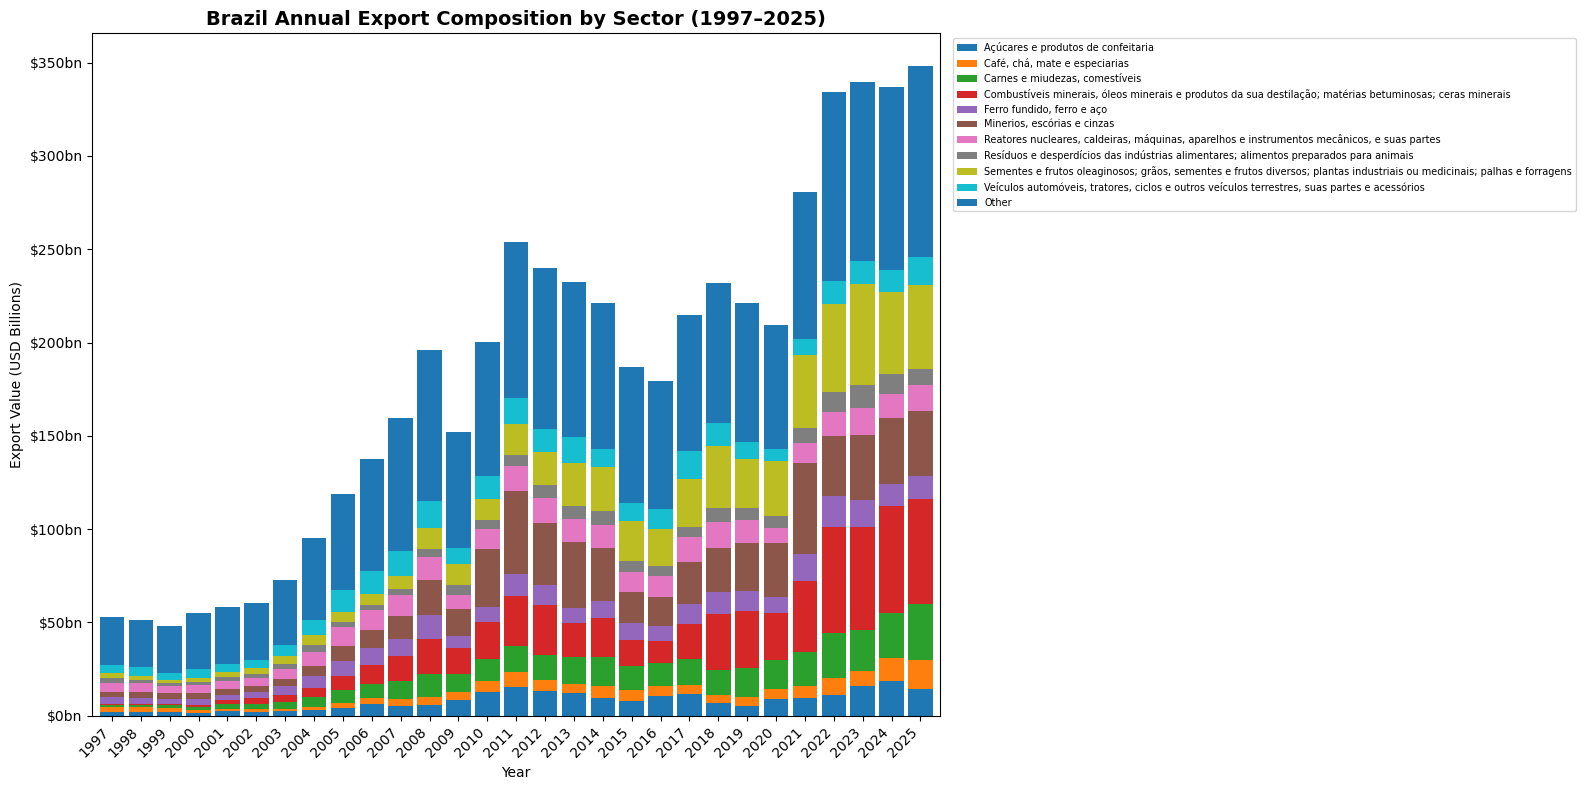


Brazil export composition by sector (2025) — Total: $348.3bn



Sector,Exports (USD bn),Share (%)
"Combustíveis minerais, óleos minerais e produtos da sua",$55.96bn,16.1%
"Sementes e frutos oleaginosos; grãos, sementes e frutos",$44.67bn,12.8%
"Minerios, escórias e cinzas",$34.89bn,10.0%
"Carnes e miudezas, comestíveis",$29.98bn,8.6%
"Café, chá, mate e especiarias",$15.65bn,4.5%
"Veículos automóveis, tratores, ciclos e outros veículos",$15.08bn,4.3%
Açúcares e produtos de confeitaria,$14.34bn,4.1%
"Reatores nucleares, caldeiras, máquinas, aparelhos e in",$13.89bn,4.0%
"Ferro fundido, ferro e aço",$12.35bn,3.5%
Pastas de madeira ou de outras matérias fibrosas celuló,$10.17bn,2.9%


In [10]:
## Brazil annual export composition by SH2 sector (1997–MAX_YEAR)
## Shows how the sectoral mix of exports has evolved over time
query_brazil_exp_annual = f"""
    SELECT e."CO_ANO" AS year,
           s.descricao_sh2 AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" <= {MAX_YEAR}
    GROUP BY e."CO_ANO", s.descricao_sh2
    ORDER BY e."CO_ANO", exports_usd DESC
"""

df_brazil_exp_annual = pd.read_sql(query_brazil_exp_annual, engine)
df_brazil_exp_annual['exports_usd_bn'] = df_brazil_exp_annual['exports_usd'] / 1e9

## Identify top 10 sectors by total exports across all years — group rest as Other
top10_exp_sectors = (
    df_brazil_exp_annual.groupby('sector')['exports_usd']
    .sum().nlargest(10).index.tolist()
)
df_brazil_exp_annual['sector_group'] = df_brazil_exp_annual['sector'].apply(
    lambda x: x if x in top10_exp_sectors else 'Other'
)
df_brazil_exp_grouped = (
    df_brazil_exp_annual.groupby(['year', 'sector_group'])['exports_usd_bn']
    .sum().reset_index()
)
df_brazil_exp_pivot = df_brazil_exp_grouped.pivot(
    index='year', columns='sector_group', values='exports_usd_bn'
).fillna(0)

## Reorder columns so Other is last
cols_ordered = [c for c in df_brazil_exp_pivot.columns if c != 'Other'] + ['Other']
df_brazil_exp_pivot = df_brazil_exp_pivot[cols_ordered]

fig, ax = plt.subplots(figsize=(16, 8))
df_brazil_exp_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)
ax.set_title(f"Brazil Annual Export Composition by Sector (1997–{MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Export Value (USD Billions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(loc='upper left', fontsize=7, bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output_2_6b_brazil_exp_annual_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Clean formatted summary table for MAX_YEAR
df_exp_annual_display = (
    df_brazil_exp_annual[df_brazil_exp_annual['year'] == MAX_YEAR]
    .groupby('sector')['exports_usd_bn'].sum()
    .sort_values(ascending=False)
    .reset_index()
    .assign(share=lambda x: (x['exports_usd_bn'] / x['exports_usd_bn'].sum() * 100).round(1))
    .rename(columns={
        'sector'        : 'Sector',
        'exports_usd_bn': 'Exports (USD bn)',
        'share'         : 'Share (%)'
    })
    .reset_index(drop=True)
)

df_exp_annual_display['Sector'] = df_exp_annual_display['Sector'].str[:55]
df_exp_annual_display['Exports (USD bn)'] = df_exp_annual_display['Exports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_exp_annual_display['Share (%)'] = df_exp_annual_display['Share (%)'].apply(
    lambda x: f'{x:.1f}%'
)

total = df_brazil_exp_annual[df_brazil_exp_annual['year'] == MAX_YEAR]['exports_usd_bn'].sum()
print(f"\nBrazil export composition by sector ({MAX_YEAR}) — Total: ${total:.1f}bn\n")

from IPython.display import display
display(df_exp_annual_display.style
    .set_caption(f"Brazil export composition by sector ({MAX_YEAR})")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index'))

## 2.5 — Import Sector Structure: What Brazil's States and Regions Actually Buy

## 2.5.1 — Top 10 Import Sectors by State (SH2): Ranked Table with Share of State Total
For every state, the top 10 import sectors by SH2 classification ranked by value — each showing its share of that state total imports.

### The Five Dominant Import Profiles

The import sector data reveals a fundamentally different structural picture from exports. Where exports are concentrated in primary commodities, imports are dominated by capital goods, industrial inputs and energy — reflecting Brazil's position as an industrialising economy that must import the means of production it does not yet manufacture domestically.

**1. Capital goods and industrial input states**
São Paulo, Minas Gerais, Paraná, Rio Grande do Sul and Santa Catarina all show machinery (SH84), electrical equipment (SH85) and organic chemicals (SH29) in their top import positions. These are industrial inputs for manufacturing — not consumption goods.

**2. Petroleum import states**
Maranhão (66.0% petroleum), Amapá (76.0%), Paraíba (49.0%), Sergipe (47.2%), Bahia (43.8%) and Ceará (24.8%) all have mineral fuels as their largest import category. States that export petroleum (Rio Grande do Norte, Sergipe) paradoxically also import it — reflecting refinery capacity mismatches and petroleum product grade differentials.

**3. Fertiliser-dependent agricultural states**
Mato Grosso (61.7% fertilisers), Tocantins (51.0%), Maranhão (25.0%), Pará (24.4%) and Rio Grande do Sul (19.4%) all have fertilisers (SH31) as a top-2 import category. Brazil's agricultural surplus is structurally dependent on imported fertilisers — primarily from Russia, Belarus and Canada. This is the most significant hidden dependency in Brazil's trade balance.

**4. Offshore oil and gas equipment state**
Rio de Janeiro's import profile is unique — machinery (SH84) at 37.6% (\\$12.10bn), petroleum (19.3%), vessels (7.7%) — reflecting the capital-intensive nature of pre-salt offshore oil extraction. Rio de Janeiro imports the drilling equipment, vessels and industrial machinery needed to produce the oil it exports.

**5. Free Trade Zone input state**
Amazonas imports electrical equipment (44.0%, \\$7.06bn), machinery (13.9%) and plastics (7.9%) — the components assembled into consumer electronics and motorcycles at the Zona Franca de Manaus.

---

### State-by-State Highlights

**São Paulo (\\$86.50bn imports) — the most diversified import basket in Brazil.** Machinery (\\$15.72bn, 18.2%), electrical equipment (\\$10.66bn, 12.3%), organic chemicals (\\$7.72bn, 8.9%), pharmaceuticals (\\$6.60bn, 7.6%), chemical products (\\$5.38bn, 6.2%) and precision instruments (\\$4.70bn, 5.4%) dominate. This is the import profile of an industrial metropolis — capital goods, chemical inputs and high-technology imports for manufacturing and healthcare. São Paulo imports more machinery alone (\\$15.72bn) than most states import in total.

**Santa Catarina (\\$33.99bn imports) — the most analytically puzzling import profile.** The top 10 spans machinery (13.0%), electrical equipment (10.8%), plastics (8.9%), vehicles (5.5%), iron and steel (5.0%), copper (4.2%), rubber (3.6%), organic chemicals (3.5%), fertilisers (3.2%) and precision instruments (2.9%). This is a genuinely diversified industrial import basket — consistent with a major manufacturing hub. But the scale (\\$33.99bn) relative to Santa Catarina's export value (\\$12.20bn) cannot be explained by its manufacturing base alone. The top 10 sectors account for approximately 60% of imports — the remaining 40% is unaccounted for in this view and requires NCM-level investigation. Santa Catarina appears to function as a major import gateway for the Sul region, with goods potentially redistributed onward to neighbouring states through its ports (Itajaí, Navegantes, São Francisco do Sul).

**Rio de Janeiro (\\$32.17bn imports) — the offshore oil import machine.** Machinery at \\$12.10bn (37.6%) is the single largest state-sector import pair in the entire dataset — one state, one sector, \\$12bn. This is drilling equipment, subsea systems, platform components and industrial machinery for the Campos and Santos pre-salt basins. Petroleum imports (\\$6.19bn) and vessels (\\$2.46bn) reinforce the offshore extraction profile. Rio de Janeiro's import basket is almost entirely determined by its oil production activity.

**Amazonas (\\$16.06bn imports) — electronics components at scale.** Electrical equipment at \\$7.06bn (44.0%) is the defining figure. This is the largest single sector-state import value in the Zona Franca analysis — Samsung, LG, Honda and others import components from Asia for assembly in Manaus. The plastics (7.9%), vehicles/motorcycles (5.6%), precious stones (5.7%) and machinery (13.9%) complete a Zona Franca-specific import profile found nowhere else in Brazil.

**Minas Gerais (\\$18.33bn imports) — the most balanced industrial import mix.** Machinery (17.2%), electrical equipment (10.2%), vehicles (9.9%), fertilisers (6.8%), organic chemicals (6.5%), pharmaceuticals (5.9%) and precision instruments (5.2%) reflect a diversified industrial economy importing across multiple production domains. The vehicles import (\\$1.81bn) likely reflects vehicle component imports for the Fiat/Stellantis and Mercedes-Benz manufacturing operations.

**Paraná (\\$20.15bn imports) — fertilisers and machinery in near-equal weight.** Machinery (\\$3.07bn, 15.2%) and fertilisers (\\$3.02bn, 15.0%) are almost identical — the largest combined fertiliser import value among non-Centre-West states. Paraná's agricultural base requires massive fertiliser inputs despite being a diversified agro-industrial state. Vehicles (9.7%), petroleum (8.4%) and electrical equipment (7.4%) complete a picture of a state balancing industrial and agricultural import needs simultaneously.

**Rio Grande do Sul (\\$13.38bn imports) — vehicles, fertilisers and petroleum in equal measure.** Vehicles (\\$2.82bn, 21.1%), fertilisers (\\$2.59bn, 19.4%) and petroleum (\\$2.29bn, 17.1%) form a nearly equal top-3 — the most evenly distributed top-3 of any major importing state. The vehicle import likely reflects component imports for the GM and other automotive operations.

**Espírito Santo (\\$13.81bn imports) — vehicles and aerospace dominate unexpectedly.** Vehicles (\\$6.21bn, 45.0%) and aerospace equipment (\\$1.74bn, 12.6%) are the largest categories. The vehicle figure is striking — Espírito Santo is not a major automotive producer, suggesting these are transshipment imports through the port of Vitória rather than domestic consumption inputs. The aerospace figure likely reflects aircraft maintenance and parts handling at Vitória's aviation logistics operations.

**Distrito Federal (\\$2.26bn imports) — pharmaceuticals at 82.5%.** A single sector accounting for 82.5% of a state's imports (\\$1.86bn) is the most extreme sector concentration on the import side in the dataset. The Federal District houses Brazil's major federal health agencies and pharmaceutical distribution infrastructure — this figure likely reflects centralised government pharmaceutical procurement routed through Brasília.

**Goiás (\\$5.36bn imports) — pharmaceuticals and vehicles.** Pharmaceuticals (\\$1.94bn, 36.3%) as the top import category is unexpected for an agricultural state. Goiás hosts a significant pharmaceutical manufacturing cluster (particularly generic drugs) that imports active pharmaceutical ingredients for processing. Vehicles (14.4%) and machinery (12.9%) follow.

**Mato Grosso (\\$2.62bn imports) — fertilisers overwhelmingly dominant.** Fertilisers at \\$1.62bn (61.7%) make Mato Grosso's import profile the most concentrated in the dataset after Amapá's petroleum imports. The world's largest soybean-producing state is structurally dependent on imported fertilisers — primarily potash, phosphate and nitrogen compounds from Russia, Canada and China. Chemical products (14.2%) and machinery (6.7%) reflect the agrochemical inputs and harvesting equipment required for the agricultural frontier.

**Maranhão (\\$4.76bn imports) — petroleum and fertilisers as a logistics hub.** Petroleum (66.0%, \\$3.14bn) and fertilisers (25.0%, \\$1.19bn) account for 91% of Maranhão's imports. This is not a consumption profile — it reflects the Itaqui port's role as a bulk import terminal for petroleum products and agricultural inputs distributed across the interior Nordeste and MATOPIBA frontier. Maranhão imports to distribute, not primarily to consume.

---

### Cross-Cutting Observations

**Fertilisers (SH31) appear in the top 10 of 18 states** — the most universally present import sector. Brazil's agricultural surplus is built on imported fertiliser inputs. The total fertiliser import bill across all states is substantial and represents Brazil's most strategically significant import dependency — particularly given that Russia is the world's largest fertiliser exporter and geopolitical disruption (as seen in 2022) directly affects Brazilian agricultural production costs.

**Machinery (SH84) appears in the top 10 of 25 states** — the most universal capital goods import. Brazil imports the industrial equipment it uses to produce both its commodity and manufactured exports.

**Petroleum (SH27) appears in the top 10 of 20 states** — despite being Brazil's largest export sector, petroleum products are also widely imported. This reflects the mismatch between Brazil's crude oil export profile (primarily heavy pre-salt crude from Rio de Janeiro) and its domestic demand for refined products (gasoline, diesel, jet fuel) that require different refinery configurations than are currently available domestically.

**Pharmaceuticals (SH30) appears prominently in Distrito Federal (82.5%), Goiás (36.3%), São Paulo (7.6%) and Minas Gerais (5.9%)** — reflecting Brazil's dependence on imported active pharmaceutical ingredients and finished drugs. Despite having a domestic generics industry, Brazil imports significant pharmaceutical value.

**The import side confirms Santa Catarina as the most analytically unresolved state in Step 2.** Its \\$33.99bn import basket spans machinery, electrical equipment, plastics, iron and steel, copper, rubber, chemicals and fertilisers without any single sector exceeding 13% — a genuinely diversified industrial import profile at a scale that cannot be explained by its own industrial output. The gateway hypothesis (Santa Catarina as an import distribution hub for the Sul region) is the most plausible explanation pending NCM-level investigation.

> ⚠️ *Brazil's fertiliser import dependency is the most strategically significant finding in the import sector data. Fertilisers appear in 18 states' top 10 import lists, and states like Mato Grosso (61.7%), Tocantins (51.0%) and Maranhão (25.0%) are structurally dependent on imported fertilisers to produce the soybean exports that drive Brazil's trade surplus. The Russia-Ukraine conflict (2022) temporarily disrupted fertiliser supply chains and caused domestic agricultural input price spikes — a risk that will recur if geopolitical supply disruptions continue.*

> ⚠️ *The Espírito Santo vehicle import finding (\\$6.21bn, 45.0%) requires investigation. A state that is not a major automotive manufacturing or consumption centre importing \\$6.21bn in vehicles — larger than the vehicle imports of Minas Gerais (\\$1.81bn) which hosts Fiat/Stellantis — strongly suggests transshipment or re-export activity through the port of Vitória that is not captured in the export data.*

---

In [11]:
top10_imp_states_uf = df_state.nlargest(10, 'imports_usd_bn')['uf'].tolist()
top10_imp_states_uf_str = ','.join([f"'{s}'" for s in top10_imp_states_uf])

query_imp_sectors = f"""
    SELECT i."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.codigo_sh2,
           s.descricao_sh2,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY i."SG_UF_NCM", u.nome_estado, s.codigo_sh2, s.descricao_sh2
    ORDER BY i."SG_UF_NCM", imports_usd DESC
"""

df_imp_sectors = pd.read_sql(query_imp_sectors, engine)
df_imp_sectors['imports_usd_bn'] = (df_imp_sectors['imports_usd'] / 1e9).round(2)

df_top10_imp_sectors = (
    df_imp_sectors.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'imports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 import sectors per state — SH2 classification ({MAX_YEAR})")
for state in df_top10_imp_sectors['state'].unique():
    subset = df_top10_imp_sectors[df_top10_imp_sectors['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['imports_usd_bn'].iloc[0]
    print(f"\n{state} — Total imports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['imports_usd'] / (total * 1e9) * 100)
        print(f"  SH{row['codigo_sh2']} {str(row['descricao_sh2'])[:50]:<50} ${row['imports_usd_bn']:.2f}bn ({share:.1f}%)")

Top 10 import sectors per state — SH2 classification (2025)

Acre — Total imports: $0.0bn
  SH88 Aeronaves e aparelhos espaciais, e suas partes     $0.00bn (19.3%)
  SH84 Reatores nucleares, caldeiras, máquinas, aparelhos $0.00bn (9.4%)
  SH93 Armas e munições; suas partes e acessórios         $0.00bn (7.9%)
  SH85 Máquinas, aparelhos e materiais elétricos, e suas  $0.00bn (5.4%)
  SH90 Instrumentos e aparelhos de óptica, de fotografia, $0.00bn (3.9%)
  SH40 Borracha e suas obras                              $0.00bn (1.7%)
  SH32 Extratos tanantes e tintoriais; taninos e seus der $0.00bn (1.0%)
  SH28 Produtos químicos inorgânicos; compostos inorgânic $0.00bn (0.6%)
  SH7 Produtos hortícolas, plantas, raízes e tubérculos, $0.00bn (0.5%)
  SH44 Madeira, carvão vegetal e obras de madeira         $0.00bn (0.5%)

Alagoas — Total imports: $1.1bn
  SH39 Plásticos e suas obras                             $0.12bn (10.4%)
  SH85 Máquinas, aparelhos e materiais elétricos, e suas  $0.11bn (10.1%)

C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\2079196040.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'imports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\2079196040.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  share = (row['imports_usd'] / (total * 1e9) * 100)


## 2.5.2 — Brazil Annual Import Composition by Sector (1997–2025)
Normalised version of 2.7.3 showing percentage share of each sector rather than absolute value — making it easier to see structural shifts in the import mix.

### National Import Mix — Total: \$280.2bn

Brazil's national import basket is dominated by capital goods, industrial inputs and energy — a structurally different composition from the commodity-heavy export side.

| Rank | Sector | \$bn | Share |
|---|---|---|---|
| 1 | Machinery (SH84) | \$47.03bn | 16.8% |
| 2 | Mineral fuels (SH27) | \$30.53bn | 10.9% |
| 3 | Electrical equipment (SH85) | \$30.13bn | 10.8% |
| 4 | Vehicles (SH87) | \$23.06bn | 8.2% |
| 5 | Fertilisers (SH31) | \$15.49bn | 5.5% |
| 6 | Organic chemicals (SH29) | \$14.97bn | 5.3% |
| 7 | Pharmaceuticals (SH30) | \$14.54bn | 5.2% |
| 8 | Plastics (SH39) | \$10.99bn | 3.9% |
| 9 | Precision instruments (SH90) | \$9.55bn | 3.4% |
| 10 | Chemical products (SH38) | \$8.47bn | 3.0% |

The top 10 sectors account for approximately 73.0% of Brazil's total imports.

### The Export-Import Structural Contrast

Comparing Brazil's export and import compositions at the national level reveals a clean commodity-for-capital-goods exchange:

| Export top 4 | \$bn | Import top 4 | \$bn |
|---|---|---|---|
| Mineral fuels | \$55.96bn | Machinery | \$47.03bn |
| Soybeans | \$44.67bn | Mineral fuels | \$30.53bn |
| Ores | \$34.89bn | Electrical equipment | \$30.13bn |
| Meat | \$29.98bn | Vehicles | \$23.06bn |

Brazil exports primary commodities and imports the industrial equipment used to produce and transport them. This is the classic middle-income country trade structure — not a developing economy trap but a structural position that requires active industrial policy to change.

### Key Observations

**Machinery at \$47.03bn (16.8%)** is Brazil's largest import category by a significant margin — nearly matching the entire soybean export value (\$44.67bn). Brazil imports more industrial machinery than any other single product. This reflects the capital-intensity of its offshore oil operations (Rio de Janeiro), agricultural mechanisation (Centro-Oeste) and manufacturing base (Sudeste and Sul).

**Mineral fuels at \$30.53bn (10.9%)** — Brazil simultaneously exports \$55.96bn of mineral fuels and imports \$30.53bn. The net position is a \$25.43bn surplus on petroleum, but the gross flows reveal a refinery bottleneck — Brazil exports heavy crude and imports refined products (gasoline, diesel, petrochemicals) that its domestic refinery capacity cannot produce in sufficient quantities.

**Electrical equipment at \$30.13bn (10.8%)** is almost entirely driven by the Zona Franca de Manaus (Amazonas imports \$7.06bn) and São Paulo's electronics and telecoms manufacturing base. Brazil does not produce the semiconductors, integrated circuits and advanced electronics it requires domestically.

**Fertilisers at \$15.49bn (5.5%)** — the fifth largest import category and Brazil's most strategically significant supply chain vulnerability. Brazil imports approximately 85% of the fertilisers it uses domestically, primarily from Russia, Belarus, Canada and China. The \$15.49bn fertiliser import bill is the direct input cost of the agricultural export surplus.

**Pharmaceuticals at \$14.54bn (5.2%)** — Brazil is the world's sixth largest pharmaceutical market but imports the majority of active pharmaceutical ingredients (APIs) used in domestic drug production, primarily from China and India. This represents a strategic dependency in healthcare supply chains.

**The vessels finding (SH89, \$5.42bn, 1.9%)** — Brazil imports \$5.42bn in vessels and floating structures, primarily for the offshore oil sector (Rio de Janeiro \$2.46bn, São Paulo \$2.81bn). This reflects the capital-intensive maritime infrastructure required for pre-salt oil extraction.

**Aerospace imports (SH88, \$4.56bn, 1.6%)** — despite being home to Embraer, Brazil imports \$4.56bn in aerospace equipment. This reflects aircraft maintenance parts, imported aircraft for Brazilian carriers and military aviation procurement rather than competing with domestic production.

### The Import Surplus Basket

Brazil imports more than it exports in the following categories that are strategically significant:

| Sector | Exports | Imports | Net |
|---|---|---|---|
| Machinery (SH84) | \$13.89bn | \$47.03bn | -\$33.14bn |
| Pharmaceuticals (SH30) | \$1.27bn | \$14.54bn | -\$13.27bn |
| Organic chemicals (SH29) | \$1.72bn | \$14.97bn | -\$13.25bn |
| Electrical equipment (SH85) | \$5.10bn | \$30.13bn | -\$25.03bn |
| Fertilisers (SH31) | \$0.32bn | \$15.49bn | -\$15.17bn |
| Vehicles (SH87) | \$15.08bn | \$23.06bn | -\$7.98bn |

These six categories generate a combined import surplus of \\$107.77bn — meaning Brazil's overall trade surplus of approximately \\$68bn is generated by overcoming a \\$108bn deficit in capital goods and industrial inputs through commodity exports.

### The Long Tail

Brazil imports goods from virtually every SH2 category — 94 active chapters on the import side. However the distribution is even more top-heavy than exports: the top 10 account for 73% of the total, and everything beyond position 15 contributes less than 2% individually. This reflects the breadth of Brazil's industrial and consumer economy rather than diversified import dependency.

> ⚠️ *The fertiliser import dependency (\\$15.49bn, 5.5% of total imports) is the single most strategically significant supply chain risk in Brazil's national trade structure. Brazil cannot sustain its agricultural export surplus without reliable fertiliser imports. Any sustained disruption to global fertiliser supply chains — whether from geopolitical conflict, sanctions or export restrictions by major producing nations — would directly reduce Brazilian crop yields and compress the commodity export revenues that underpin the national trade balance.*

> ⚠️ *The pharmaceutical import dependency (\\$14.54bn) combined with the API supply chain concentration in China and India represents Brazil's most acute healthcare supply security risk. This was briefly visible during COVID-19 when API supply disruptions affected Brazilian generic drug production. The scale of the dependency — imports nearly 11x larger than exports — suggests domestic pharmaceutical manufacturing capacity is structurally insufficient relative to market size.*

### How the Import Mix Has Shifted Over 28 Years

The annual stacked bar chart reveals that Brazil's import composition is structurally more stable than its export composition — the sector proportions within each bar change less dramatically year to year than the commodity-driven swings visible in the export chart.

### The Dominant Structural Feature: Capital Goods Stability

Machinery (yellow, SH84) and electrical equipment (teal, SH85) together form a consistent base across all 29 years. Their combined absolute value grew from approximately \\$10bn (1997) to approximately \\$77bn (2025) — a 7.7x increase — but as a share of total imports they held broadly stable or grew modestly. This reflects Brazil's sustained capital goods import dependency — the economy consistently needs industrial machinery regardless of commodity price cycles or macroeconomic conditions.

### The Two Import Cycles

**Cycle 1 — The 2003–2013 Import Expansion**
Brazil's imports grew from approximately \$50bn (2003) to approximately \\$240bn (2013) — a nearly 5x increase in a decade. This was driven by:
- The overvalued Real (2005–2014) making imports artificially cheap
- Industrial growth and consumer demand expansion during the Lula/Dilma commodity boom years
- Vehicle imports (teal, SH87) and petroleum (orange, SH27) growing particularly visibly in this period

The chart shows the bars growing rapidly taller with the composition becoming more colorful — more sectors reaching material import values simultaneously.

**Cycle 2 — The 2014–2016 Contraction and Post-COVID Recovery**
The sharp contraction in 2015–2016 is clearly visible — bars shrink significantly, reflecting the combination of the devalued Real making imports expensive, the domestic recession reducing demand and the Dilma government's fiscal adjustment. Every sector contracted proportionally.

The recovery from 2017 to 2019 was gradual. The 2020 COVID year shows a sharp dip — more visible on the import side than the export side, consistent with the finding that Brazil's goods exports were resilient during COVID while imports of consumer and capital goods fell. The post-2021 surge to new highs reflects both import demand recovery and Real weakness amplifying USD-denominated values.

### The Fertiliser Story (Blue, SH31)

The fertiliser segment (blue at top) is small but visible throughout the chart and grows noticeably post-2015. The 2022 spike — reflecting the Russia-Ukraine conflict disrupting global fertiliser supply and causing price surges — is visible as the blue segment enlarging sharply. This is the clearest single-year commodity supply shock visible in Brazil's import chart and directly parallels the soybean export surge visible in the export chart for the same year.

### Petroleum Imports (Orange, SH27) — Persistent Across All Conditions

The petroleum import segment (orange) is visible throughout all 29 years and shows relatively stable proportional weight despite the commodity price cycle. Brazil imports petroleum products in volumes that are broadly proportional to its total import value — suggesting petroleum imports are a near-fixed cost of running the economy regardless of price levels. The segment grew in absolute terms post-2020 as energy prices surged globally.

### The Import Side COVID Signature

The 2020 bar is visibly shorter than 2019 — unlike the export chart where 2020 barely dips. This confirms that COVID-19 impacted Brazil's import side more than its export side:
- Consumer goods imports fell as domestic demand contracted
- Capital goods imports fell as investment paused
- Vehicle imports fell sharply as dealerships closed
- Petroleum imports fell as mobility collapsed

But commodity exports continued — China kept buying soybeans and iron ore throughout 2020. This asymmetry between import contraction and export resilience is what allowed Brazil to maintain a positive trade balance through COVID-19 despite economic disruption.

### Pharmaceuticals — The Fastest-Growing Segment Post-2015

The pharmaceutical segment (pink/purple, SH30) is small in 1997 but grows consistently and is now \$14.54bn (5.2%). The growth is particularly visible post-2015. This reflects Brazil's aging population, rising healthcare expenditure, expansion of universal healthcare (SUS) pharmaceutical procurement and increasing dependence on imported APIs from China and India. The pharmaceutical import segment grows even during recessions — suggesting inelastic demand driven by healthcare necessity rather than discretionary spending.

### Comparing Import and Export Chart Structures

| Feature | Export chart | Import chart |
|---|---|---|
| Dominant colour pattern | Commodity colours dominate (brown, green, yellow-green) | Capital goods colours dominate (yellow, teal) |
| Stability of composition | Less stable — commodity price cycles shift proportions | More stable — capital goods share is consistent |
| COVID-19 impact | Minimal — bars barely shorten | Visible — 2020 bar clearly shorter |
| Post-2020 acceleration | Driven by commodity price surges | Driven by capital goods, petroleum and pharmaceutical demand |
| Fastest growing segment | Petroleum (pre-salt ramp-up) | Pharmaceuticals (healthcare demand) |

> ⚠️ *The pharmaceutical import trend is the most structurally significant long-run pattern in the import chart that does not receive adequate attention in Brazilian trade policy discussions. A sector that grows during every economic cycle — recessions, booms and pandemics — reflects an inelastic dependency that will only increase as Brazil's population ages. At \$14.54bn in 2025 and growing, pharmaceutical imports will likely challenge fertilisers for the position of Brazil's most strategically significant import dependency within the next decade.*

> ⚠️ *The 2022 fertiliser spike is visible in the chart and its consequences are measurable in both the import and export data for that year. The Russia-Ukraine conflict simultaneously raised Brazilian agricultural input costs (fertiliser imports spiked) and raised Brazilian agricultural export revenues (global food prices surged). The net effect was positive for Brazil's trade balance but represented a significant transfer of risk into the agricultural supply chain that could reverse if fertiliser prices normalise faster than food prices.*


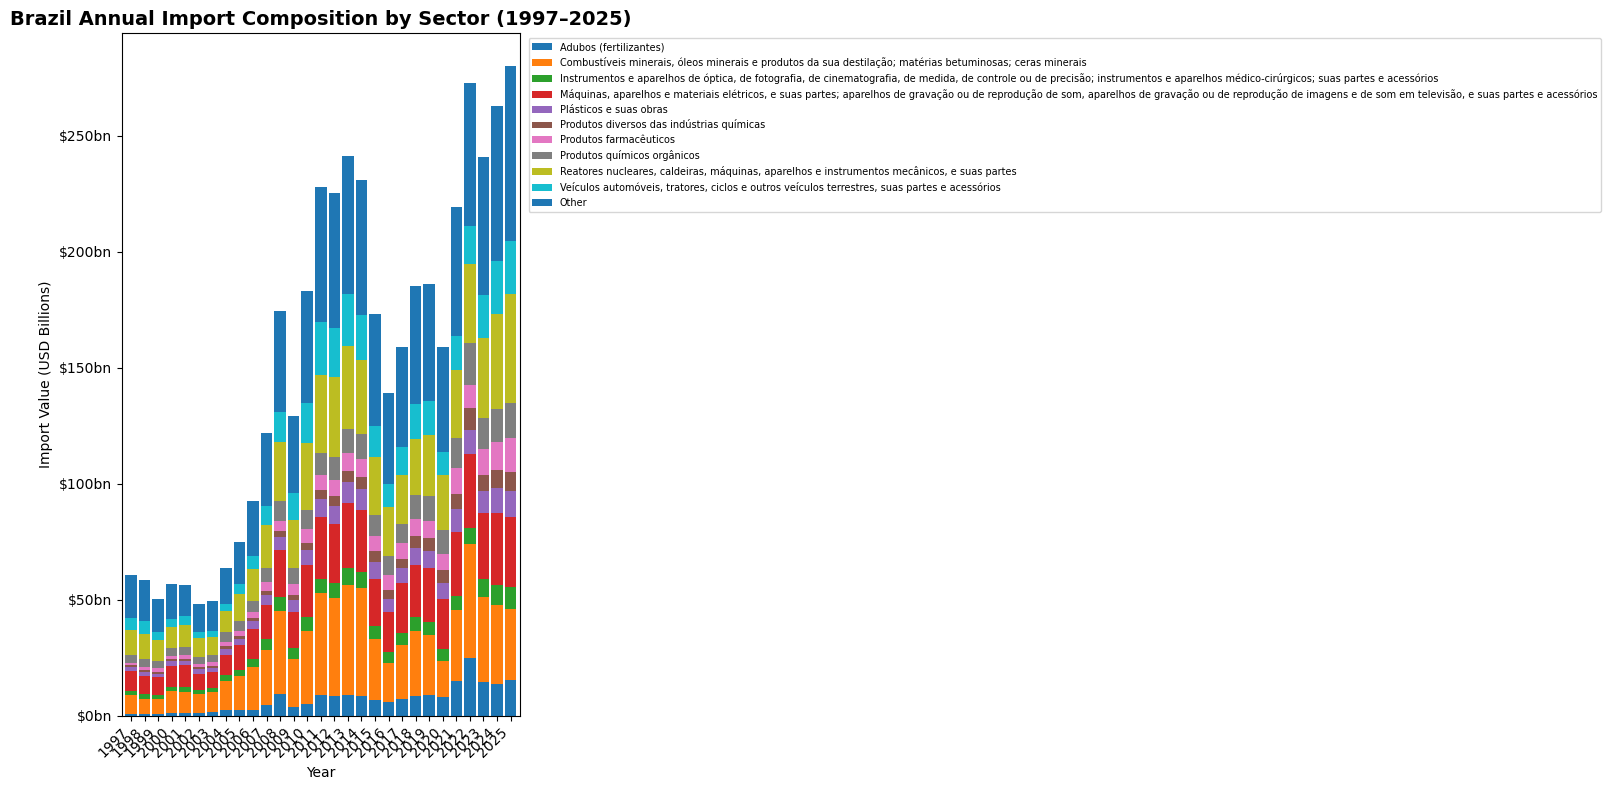


Brazil import composition by sector (2025) — Total: $280.2bn



Sector,Imports (USD bn),Share (%)
"Reatores nucleares, caldeiras, máquinas, aparelhos e in",$47.03bn,16.8%
"Combustíveis minerais, óleos minerais e produtos da sua",$30.53bn,10.9%
"Máquinas, aparelhos e materiais elétricos, e suas parte",$30.13bn,10.8%
"Veículos automóveis, tratores, ciclos e outros veículos",$23.06bn,8.2%
Adubos (fertilizantes),$15.49bn,5.5%
Produtos químicos orgânicos,$14.97bn,5.3%
Produtos farmacêuticos,$14.54bn,5.2%
Plásticos e suas obras,$10.99bn,3.9%
"Instrumentos e aparelhos de óptica, de fotografia, de c",$9.55bn,3.4%
Produtos diversos das indústrias químicas,$8.47bn,3.0%


In [12]:
## Brazil annual import composition by SH2 sector (1997–MAX_YEAR)
query_brazil_imp_annual = f"""
    SELECT i."CO_ANO" AS year,
           s.descricao_sh2 AS sector,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" <= {MAX_YEAR}
    GROUP BY i."CO_ANO", s.descricao_sh2
    ORDER BY i."CO_ANO", imports_usd DESC
"""

df_brazil_imp_annual = pd.read_sql(query_brazil_imp_annual, engine)
df_brazil_imp_annual['imports_usd_bn'] = df_brazil_imp_annual['imports_usd'] / 1e9

## Identify top 10 sectors by total imports across all years — group rest as Other
top10_imp_sectors = (
    df_brazil_imp_annual.groupby('sector')['imports_usd']
    .sum().nlargest(10).index.tolist()
)
df_brazil_imp_annual['sector_group'] = df_brazil_imp_annual['sector'].apply(
    lambda x: x if x in top10_imp_sectors else 'Other'
)
df_brazil_imp_grouped = (
    df_brazil_imp_annual.groupby(['year', 'sector_group'])['imports_usd_bn']
    .sum().reset_index()
)
df_brazil_imp_pivot = df_brazil_imp_grouped.pivot(
    index='year', columns='sector_group', values='imports_usd_bn'
).fillna(0)

## Reorder columns so Other is last
cols_ordered = [c for c in df_brazil_imp_pivot.columns if c != 'Other'] + ['Other']
df_brazil_imp_pivot = df_brazil_imp_pivot[cols_ordered]

fig, ax = plt.subplots(figsize=(16, 8))
df_brazil_imp_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.85)
ax.set_title(f"Brazil Annual Import Composition by Sector (1997–{MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Import Value (USD Billions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(loc='upper left', fontsize=7, bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('output_2_7b_brazil_imp_annual_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Clean formatted summary table for MAX_YEAR
df_imp_annual_display = (
    df_brazil_imp_annual[df_brazil_imp_annual['year'] == MAX_YEAR]
    .groupby('sector')['imports_usd_bn'].sum()
    .sort_values(ascending=False)
    .reset_index()
    .assign(share=lambda x: (x['imports_usd_bn'] / x['imports_usd_bn'].sum() * 100).round(1))
    .rename(columns={
        'sector'        : 'Sector',
        'imports_usd_bn': 'Imports (USD bn)',
        'share'         : 'Share (%)'
    })
    .reset_index(drop=True)
)

df_imp_annual_display['Sector'] = df_imp_annual_display['Sector'].str[:55]
df_imp_annual_display['Imports (USD bn)'] = df_imp_annual_display['Imports (USD bn)'].apply(
    lambda x: f'${x:.2f}bn'
)
df_imp_annual_display['Share (%)'] = df_imp_annual_display['Share (%)'].apply(
    lambda x: f'{x:.1f}%'
)

total = df_brazil_imp_annual[df_brazil_imp_annual['year'] == MAX_YEAR]['imports_usd_bn'].sum()
print(f"\nBrazil import composition by sector ({MAX_YEAR}) — Total: ${total:.1f}bn\n")

from IPython.display import display
display(df_imp_annual_display.style
    .set_caption(f"Brazil import composition by sector ({MAX_YEAR})")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index'))

## 2.6 — Product-Level Detail: Top 10 NCM Products by State and Region
Drilling below sector level to the specific NCM product codes — showing the top 10 individual products exported by each state and each region, with value and share of state or regional total.

### The NCM Level Reveals What SH2 Conceals

Moving from SH2 sector classification to individual NCM product codes resolves several ambiguities identified at the sector level and reveals the specific commodities driving each state's export identity.

### Key NCM-Level Findings by State

**Rio de Janeiro — crude oil is 79.2% of exports at a single NCM code.**
NCM 27090010 (óleos brutos de petróleo) at \\$38.815bn accounts for 79.2% of total exports — the highest single-NCM concentration of any state in the dataset. The next nine NCM codes collectively contribute less than 12%. This confirms that Rio de Janeiro's entire export identity rests on a single product from a single extraction activity.

**Piauí — soybeans at 82.8% of a single NCM code.**
NCM 12019000 (soja) at \\$0.993bn is 82.8% of total exports — the most extreme agricultural NCM concentration in the dataset. Piauí is functionally a single-product exporter.

**Minas Gerais — the only state with two NCM codes each exceeding \$11bn.**
Iron ore (NCM 26011100, \\$12.231bn, 26.7%) and coffee beans (NCM 9011110, \\$11.263bn, 24.6%) sit almost equally at the top. No other state has two primary products of comparable absolute value competing for the dominant position. Together they account for 51.3% of Minas Gerais's exports — a concentrated but genuinely dual-anchor profile.

**Amazonas — the Zona Franca NCM fingerprint is unmistakable.**
The top NCM codes — beverage preparation bases (NCM 21069010, \$0.210bn), gold bars (NCM 71081310, \$0.158bn), ferro-niobium (NCM 72029300, \\$0.107bn) and motorcycles 150–250cc (NCM 87113000, \\$0.070bn) — reflect the specific manufacturing operations in Manaus. The motorcycle codes (Honda, Yamaha operations) and electronic components confirm the Zona Franca's manufactured goods profile. The ferro-niobium is unexpected — likely related to the CBMM niobium processing operations that supply global steel producers.

**Pará — two copper ore NCM codes alongside iron ore.**
After iron ore (NCM 26011100, \\$11.640bn, 47.8%), the second largest NCM is other copper ores (NCM 26030090, \\$3.590bn, 14.8%) and alumina (NCM 28182010, \\$1.988bn, 8.2%). Pará is not just an iron ore state — it is a multi-mineral extraction economy. The copper and aluminium presence reflects the Sossego and Cristalino copper mines and the Alunorte alumina refinery.

**Bahia — gold bullion in third position.**
NCM 71081210 (bulhão dourado — gold bullion in raw form) at \\$1.072bn (9.2%) ranks third in Bahia's export list, confirming the SH71 precious metals observation from cell 2.6. The Jacobina gold mine (Yamana Gold) is the primary source. Gold bullion is a genuine Bahia export rather than a statistical artefact.

**Ceará — semi-manufactured steel products dominate.**
NCM 72071200 (outros produtos semimanufaturados de ferro ou aço, \\$0.735bn, 32.2%) and NCM 72249000 (produtos semimanufaturados de outras ligas de aço, \\$0.420bn, 18.4%) together account for 50.6% of exports. This confirms the Pecém steel complex (CSP — Companhia Siderúrgica do Pecém) as the dominant driver of Ceará's export profile — Brazil's newest integrated steel plant, built specifically to export semi-finished steel products (billets and slabs) to international markets. This explains both Ceará's high ESI (structurally different from the national mix) and its moderate HHI (steel products span multiple NCM codes within SH72).

**Pernambuco — Stellantis vehicles dominate at NCM level.**
NCM 87032210 (automóveis com motor explosão, 1000–1500cc, \\$0.505bn, 19.9%) and NCM 87043190 (outros veículos com motor a explosão, \\$0.271bn, 10.7%) together account for 30.6% — confirming the Jeep Compass and commercial vehicle exports from the Goiana (PE) Stellantis plant as the anchor of Pernambuco's export profile.

**Santa Catarina — pork as the single largest NCM.**
NCM 2032900 (outras carnes de suíno, congeladas, \\$1.656bn, 13.6%) is Santa Catarina's largest single product. WH Group (formerly Shuanghui) and BRF operations in the state drive this. The electric motors (NCM 85015210, NCM 85015310) confirm the Weg and other industrial equipment manufacturers that are internationally significant but individually smaller than the meat sector.

**São Paulo — sugar as the largest single NCM despite industrial diversification.**
NCM 17011400 (outros açúcares de cana, \\$7.061bn, 9.9%) is the largest single NCM code — reflecting the massive sugarcane processing industry in São Paulo's interior (Ribeirão Preto region). The aircraft (NCM 88024090, \\$2.789bn, 3.9%) confirms Embraer as a major NCM-level contributor. São Paulo's top 10 NCM codes span sugar, crude oil, beef, aircraft, fuel oil, soybeans, pulp, aviation fuel, coffee and refined sugar — the most genuinely diversified NCM top-10 in the dataset.

**Maranhão — alumina as the second largest NCM.**
NCM 28182010 (alumina calcinada, \\$1.389bn, 27.7%) is the second largest product — the Alunorte alumina refinery (Norsk Hydro) in Barcarena processes bauxite from Pará and exports alumina through the Itaqui port. This confirms that Maranhão's port infrastructure serves as an export gateway for Norte region mineral processing.

**Goiás — ferro-niobium and ferro-nickel appear alongside soybeans.**
NCM 72029300 (ferro-nióbio, \\$0.424bn, 3.2%) and NCM 72026000 (ferro-níquel, \\$0.410bn, 3.0%) — both ferro-alloys — appear in Goiás's top 10 alongside the dominant agricultural products. CBMM (Companhia Brasileira de Metalurgia e Mineração) in Araxá, Goiás holds approximately 75% of global niobium reserves. The ferro-niobium export reflects this near-monopoly strategic mineral position. Goiás is simultaneously Brazil's soybean frontier and the world's niobium capital.

---

### Regional NCM-Level Findings

**Centro-Oeste — the most concentrated regional NCM profile.**
Soybeans (37.4%), beef (12.5%) and corn (11.1%) account for 61.0% of regional exports at the top three NCM positions. The agricultural commodity dominance is total at the regional level. Cotton (6.0%), pulp (5.7%) and animal feed (5.5%) complete an agricultural supply chain profile with minimal industrial presence.

**Norte — iron ore at 36.5% defines the region.**
Iron ore (NCM 26011100, \\$11.640bn, 36.5%) is almost entirely from Pará's Carajás complex. The copper ore presence (11.3%) reflects Pará's multi-mineral profile. Beef (9.4%) and alumina (6.2%) add agricultural and processing dimensions but the regional identity is primarily extractive mineral.

**Nordeste — soybeans are the largest regional NCM despite not being the Nordeste's traditional product.**
Soybeans at 21.2% (\\$5.341bn) reflect the MATOPIBA expansion into Piauí and Maranhão pulling the regional aggregate. Fuel oil (9.3%) is dominated by Rio Grande do Norte and Sergipe onshore oil. Alumina (5.5%, Maranhão) and gold bullion (5.6%) reveal the mineral processing and extraction activities that do not fit the traditional Nordeste agricultural narrative.

**Sudeste — crude oil at 24.3% anchors the region.**
NCM 27090010 at \\$42.873bn (24.3%) — almost entirely from Rio de Janeiro — is the largest regional NCM by an enormous margin. Coffee (8.1%, primarily Minas Gerais and Espírito Santo), iron ore (8.0%) and sugar (5.0%, primarily São Paulo) follow. The aerospace entry (NCM 88024090, \\$2.817bn, 1.6%) confirms Embraer's Sudeste contribution at the regional level. The Sudeste top 10 spans oil, coffee, iron ore, sugar, soybeans, beef, fuel oil, pulp, semi-manufactured steel and aircraft — the most structurally diverse regional NCM profile.

**Sul — soybeans lead but meat products dominate the bulk of the top 10.**
Soybeans (15.3%) lead but pork (5.1%), tobacco (4.7%), animal feed (3.8%), chicken breast (3.3%), whole chicken (2.4%), corn (2.4%), pulp (2.2%), sugar (2.0%) and chicken thighs (1.9%) follow — six of the top 10 positions are meat or animal products. The Sul is Brazil's protein export powerhouse at the NCM level. BRF (headquartered in Itajaí, SC), JBS Sul operations and tobacco processors (British American Tobacco, Philip Morris) define the regional product identity.

---

### Cross-Cutting NCM Observations

**NCM 12019000 (soybeans) appears in the top 10 of 22 of 27 states** — the most universally present individual NCM code in Brazil. Only Rio de Janeiro, Ceará, Sergipe, Alagoas and Acre do not have soybeans in their top 10 by value.

**NCM 71081210 (gold bullion in raw form) appears in 8 states** — Bahia, Minas Gerais, Pará, Tocantins, Maranhão, Amapá, Rio Grande do Norte and Mato Grosso. The geographic spread confirms that gold extraction is distributed across multiple states with different geological profiles. The cumulative value across these states is substantial and resolves the SH71 ambiguity identified in cell 2.6 — the precious stones category is predominantly gold bullion rather than gemstones or jewellery.

**The Pecém (Ceará) and CSP steel finding** — the semi-manufactured steel NCM dominance in Ceará (50.6% of exports from two steel NCM codes) is one of the most structurally specific findings at the NCM level. CSP was built as an export-oriented billet and slab facility and its product mix confirms this — semi-manufactured steel rather than finished steel products.

**The CBMM niobium finding** — ferro-niobium (NCM 72029300) appears in Goiás, Minas Gerais and Amazonas. Goiás (\\$0.424bn) and Minas Gerais (\\$2.126bn) are the primary sources. Brazil's near-monopoly on global niobium supply is visible at the NCM level — a strategic mineral that is essential for high-strength steel production and increasingly for battery technology.

> ⚠️ *NCM 71081210 (gold bullion) appearing in 8 states resolves the SH71 classification question from cell 2.6. The \\$7.19bn national SH71 figure is predominantly gold bullion exports rather than gemstones or jewellery — a distinction that matters for understanding Brazil's precious metals trade policy and its exposure to gold price cycles.*

> ⚠️ *The CBMM ferro-niobium finding (NCM 72029300) deserves specific attention in Step 5. Brazil controls approximately 75% of global niobium reserves and CBMM in Araxá holds the dominant share. Niobium is classified as a critical mineral by the EU, US and China for its role in steel strengthening and emerging battery technology applications. The \$2.126bn Minas Gerais + \\$0.424bn Goiás export volumes represent a strategically significant but analytically underexplored component of Brazil's mineral export base.*


In [13]:
## ---- TOP NCM BY STATE ----
query_ncm_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           e."CO_NCM" AS ncm_code,
           n.nome_ncm,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY e."SG_UF_NCM", u.nome_estado, e."CO_NCM", n.nome_ncm
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_ncm_state = pd.read_sql(query_ncm_state, engine)
df_ncm_state['exports_usd_bn'] = (df_ncm_state['exports_usd'] / 1e9).round(3)

df_top10_ncm_state = (
    df_ncm_state.groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

print(f"Top 10 NCM products by state ({MAX_YEAR})")
for state in df_top10_ncm_state['state'].unique():
    subset = df_top10_ncm_state[df_top10_ncm_state['state'] == state]
    total  = df_state[df_state['uf'] == subset['uf'].iloc[0]]['exports_usd_bn'].iloc[0]
    print(f"\n{state} — Total exports: ${total:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total * 1e9) * 100)
        print(f"  NCM {row['ncm_code']} {str(row['nome_ncm'])[:50]:<50} ${row['exports_usd_bn']:.3f}bn ({share:.1f}%)")

## ---- TOP NCM BY REGION ----
query_ncm_region = f"""
    SELECT u.nome_regiao AS region,
           e."CO_NCM" AS ncm_code,
           n.nome_ncm,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, e."CO_NCM", n.nome_ncm
    ORDER BY u.nome_regiao, exports_usd DESC
"""

df_ncm_region = pd.read_sql(query_ncm_region, engine)
df_ncm_region['exports_usd_bn'] = (df_ncm_region['exports_usd'] / 1e9).round(3)

df_top10_ncm_region = (
    df_ncm_region.groupby('region', group_keys=False)
    .apply(lambda x: x.nlargest(10, 'exports_usd'))
    .reset_index(drop=True)
)

## Regional totals
region_totals = df_region[df_region['year'] == MAX_YEAR].set_index('region')['exports_usd']

print(f"\nTop 10 NCM products by region ({MAX_YEAR})")
for region in df_top10_ncm_region['region'].unique():
    subset = df_top10_ncm_region[df_top10_ncm_region['region'] == region]
    total  = region_totals.get(region, 1)
    print(f"\n{region} — Total exports: ${total/1e9:.1f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / total * 100)
        print(f"  NCM {row['ncm_code']} {str(row['nome_ncm'])[:50]:<50} ${row['exports_usd_bn']:.3f}bn ({share:.1f}%)")

C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\2179774774.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


Top 10 NCM products by state (2025)

Acre — Total exports: $0.1bn
  NCM 2023000 Carnes desossadas de bovino, congeladas            $0.020bn (20.5%)
  NCM 12019000 Soja, mesmo triturada, exceto para semeadura       $0.020bn (20.4%)
  NCM 2032900 Outras carnes de suíno, congeladas                 $0.014bn (13.7%)
  NCM 8012100 Castanha-do-pará, fresca ou seca, com casca        $0.009bn (9.4%)
  NCM 2013000 Carnes desossadas de bovino, frescas ou refrigerad $0.007bn (7.1%)
  NCM 1022990 Outros bovinos vivos                               $0.005bn (5.1%)
  NCM 5040090 Bexigas e estômagos, de animais, exceto peixes, fr $0.004bn (3.8%)
  NCM 8012200 Castanha-do-pará, fresca ou seca, sem casca        $0.003bn (3.0%)
  NCM 2062990 Outras miudezas comestíveis de bovino, congeladas  $0.003bn (2.7%)
  NCM 2031900 Outras carnes de suíno, frescas ou refrigeradas    $0.002bn (2.2%)

Alagoas — Total exports: $0.8bn
  NCM 17011400 Outros açúcares de cana                            $0.509bn (62.0%)
  NC

C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\2179774774.py:53: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(10, 'exports_usd'))


## 2.7 — China Dependency at State Level: Is the 28.7% National Average Uniform?
Step 1 showed China absorbs 28.7% of Brazil total exports. This section examines whether that dependency is uniform across all states or concentrated in specific ones — and what products each state sends to China.

### 2.7.1 — China Share of State Exports: Which States Are Most Exposed?
Horizontal bar chart ranking all states by the share of their exports destined for China — with the 28.7% national average as a reference line.

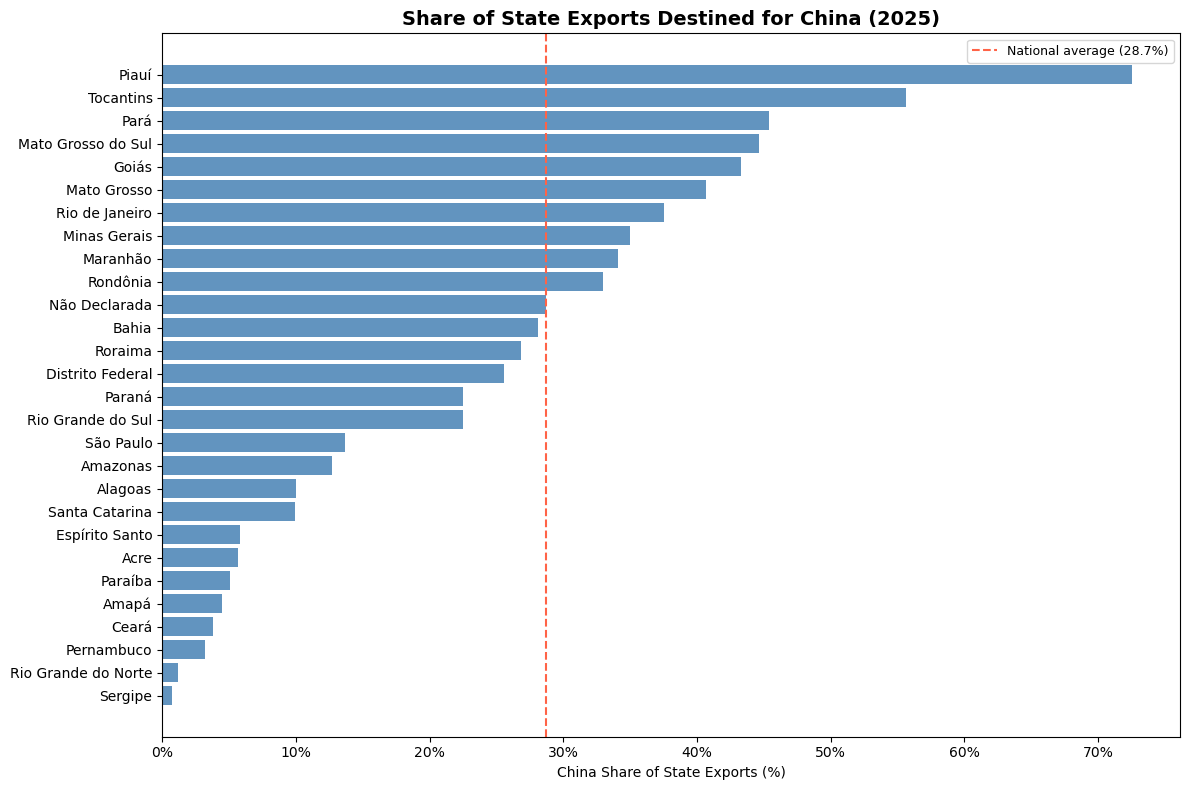


China dependency by state (2025) — national average: 28.7%
              state  exports_to_china_bn  exports_usd_bn  china_share_%
              Piauí                 0.87            1.20           72.5
          Tocantins                 1.70            3.05           55.6
               Pará                11.04           24.34           45.4
 Mato Grosso do Sul                 4.80           10.75           44.6
              Goiás                 5.83           13.47           43.3
        Mato Grosso                12.29           30.19           40.7
     Rio de Janeiro                18.38           48.98           37.5
       Minas Gerais                16.06           45.83           35.0
           Maranhão                 1.71            5.02           34.1
           Rondônia                 1.02            3.09           33.0
      Não Declarada                 0.66            2.31           28.7
              Bahia                 3.27           11.63           28.1
    

In [14]:
china_code_query = "SELECT codigo_pais FROM pais WHERE nome_pais_ing = 'China'"
china_code = pd.read_sql(china_code_query, engine)['codigo_pais'].iloc[0]

query_china_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           SUM(e."VL_FOB") AS exports_to_china
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."CO_PAIS" = {china_code}
    GROUP BY e."SG_UF_NCM", u.nome_estado
    ORDER BY exports_to_china DESC
"""

df_china_state = pd.read_sql(query_china_state, engine)
df_china_state['exports_to_china_bn'] = (df_china_state['exports_to_china'] / 1e9).round(2)

df_china_share = df_china_state.merge(
    df_state[['uf', 'exports_usd', 'exports_usd_bn']], on='uf', how='left'
)
df_china_share['china_share_%'] = (
    df_china_share['exports_to_china'] / df_china_share['exports_usd'] * 100
).round(1)

df_china_plot = df_china_share.sort_values('china_share_%', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_china_plot['state'], df_china_plot['china_share_%'], color='steelblue', alpha=0.85)
ax.axvline(x=28.7, color='tomato', linestyle='--', linewidth=1.5, label='National average (28.7%)')
ax.set_title(f"Share of State Exports Destined for China ({MAX_YEAR})", fontsize=14, fontweight='bold')
ax.set_xlabel("China Share of State Exports (%)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
plt.tight_layout()
plt.savefig('output_2_9_china_dependency.png', dpi=150)
plt.show()

print(f"\nChina dependency by state ({MAX_YEAR}) — national average: 28.7%")
print(df_china_share[['state', 'exports_to_china_bn', 'exports_usd_bn', 'china_share_%']]
      .sort_values('china_share_%', ascending=False)
      .to_string(index=False))

The national average of 28.7% masks enormous variation across states — ranging from 72.5% (Piauí) to 0.7% (Sergipe). The China dependency is highly concentrated in commodity-producing states and negligible in industrial or service-oriented states.

### States Far Above the National Average (>35%)

**Piauí (72.5%)** — the most China-dependent state in Brazil. Nearly three quarters of Piauí's exports go to China, almost entirely soybeans (95.2% of China-bound exports). Piauí has effectively one product and one buyer.

**Tocantins (55.6%)** — soybeans (74.5%) and beef (24.3%) dominate China-bound exports. Two agricultural commodities, one dominant buyer.

**Pará (45.4%)** — iron ore (81.6% of China-bound exports, \$9.01bn) defines the relationship. China's infrastructure and steel demand is the direct anchor of Pará's trade balance.

**Mato Grosso do Sul (44.6%)** — a notable finding. Pulp (36.3%) and soybeans (43.7%) together account for 80% of China-bound exports — a more diversified China profile than most agricultural states.

**Goiás (43.3%)** — soybeans (75.7%) and beef (12.4%) dominate. Ferro-niobium (not in top 3 to China) suggests the strategic mineral goes primarily to non-Chinese destinations — an analytically interesting divergence.

**Mato Grosso (40.7%)** — despite being Brazil's largest soybean exporter, Mato Grosso's China share (40.7%) is lower than Piauí (72.5%) or Tocantins (55.6%) because its export base is larger and more diversified — cotton, corn and beef spread the destination risk slightly.

**Rio de Janeiro (37.5%)** — crude oil to China (94.5% of China-bound exports, \$17.37bn). China is Rio de Janeiro's single largest oil customer by a wide margin. The pre-salt oil relationship with China is the largest bilateral state-country trade flow in Brazil.

**Minas Gerais (35.0%)** — iron ore to China (61.9%, \$9.94bn) dominates, with soybeans (14.6%) and iron and steel (6.6%) secondary. Minas Gerais and Pará together supply the bulk of China's Brazilian iron ore imports.

### States Near the National Average (20–35%)

**Maranhão (34.1%)** — almost entirely soybeans (98.6% of China-bound exports). Despite having alumina and pulp in its export mix, essentially all China-bound exports are agricultural.

**Rondônia (33.0%)** — beef (69.6%) and soybeans (25.0%) dominate. A pure agricultural frontier China dependency profile.

**Bahia (28.1%)** — the most diversified China-bound export profile among states near the average. Soybeans (56.3%), pulp (24.8%) and ores (8.8%) — three genuinely distinct sectors rather than a single commodity.

**Rio Grande do Sul (22.5%) and Paraná (22.5%)** — both below the national average despite being large exporters. Their diversified agro-industrial bases distribute exports across multiple destinations — USA, Europe, Middle East and Asia — rather than concentrating in China.

### States Far Below the National Average (<15%)

**São Paulo (13.7%)** — the most industrially diversified state has the lowest China share among large exporters. Its export mix (aerospace, vehicles, machinery, chemicals) finds more buyers in the USA, Europe and Latin America than in China. Petroleum (24.7% of China-bound) and beef (21.0%) dominate even São Paulo's China relationship — suggesting that China primarily sources commodities rather than industrial goods even from Brazil's most industrial state.

**Amazonas (12.7%)** — the Zona Franca manufactured goods (motorcycles, electronics) export primarily to Brazil's domestic market or Latin American neighbours rather than to China.

**Santa Catarina (9.9%)** — despite being a major pork and machinery exporter, only 9.9% goes to China. Santa Catarina's export destinations are more diversified than its northern neighbours.

**Espírito Santo (5.8%)** — counter-intuitive given that iron ore and coffee are major exports. The iron ore likely routes through Minas Gerais export statistics (Vale's headquarters) while Espírito Santo's own ore goes to a broader set of destinations.

**Ceará (3.8%) and Pernambuco (3.2%)** — the Nordeste industrial states have minimal China exposure. Ceará's semi-finished steel goes to non-Chinese markets; Pernambuco's vehicles export to Latin America and Europe via the Suape port.

**Sergipe (0.7%)** — effectively no China relationship. Onshore oil and citrus products find alternative markets.

### The Product Structure of China-Bound Exports

Across all states, China-bound exports are overwhelmingly concentrated in three product categories:
1. **Soybeans** — the agricultural anchor across 15+ states
2. **Iron ore** — the mineral anchor (Minas Gerais, Pará, Espírito Santo)
3. **Crude oil** — the energy anchor (Rio de Janeiro, São Paulo)

China does not import Brazil's industrial goods, aerospace products, vehicles or processed foods in any meaningful quantity. The China relationship is almost exclusively a primary commodity relationship — raw materials extracted from Brazil to fuel Chinese manufacturing and construction.

> ⚠️ *The top 5 most China-dependent states (Piauí 72.5%, Tocantins 55.6%, Pará 45.4%, Mato Grosso do Sul 44.6%, Goiás 43.3%) are all commodity states with minimal export market diversification. A sustained shift in Chinese demand — whether from economic slowdown, domestic soybean production expansion or energy transition reducing steel demand — would disproportionately impact exactly the states that have already benefited most from the commodity supercycle.*

### 2.7.2 — What Each State Sends to China: Export Composition by SH2 Sector
Stacked horizontal bar chart showing the product composition of each state exports to China by SH2 sector — revealing whether China dependency is driven by the same products across states or reflects different sectoral profiles.

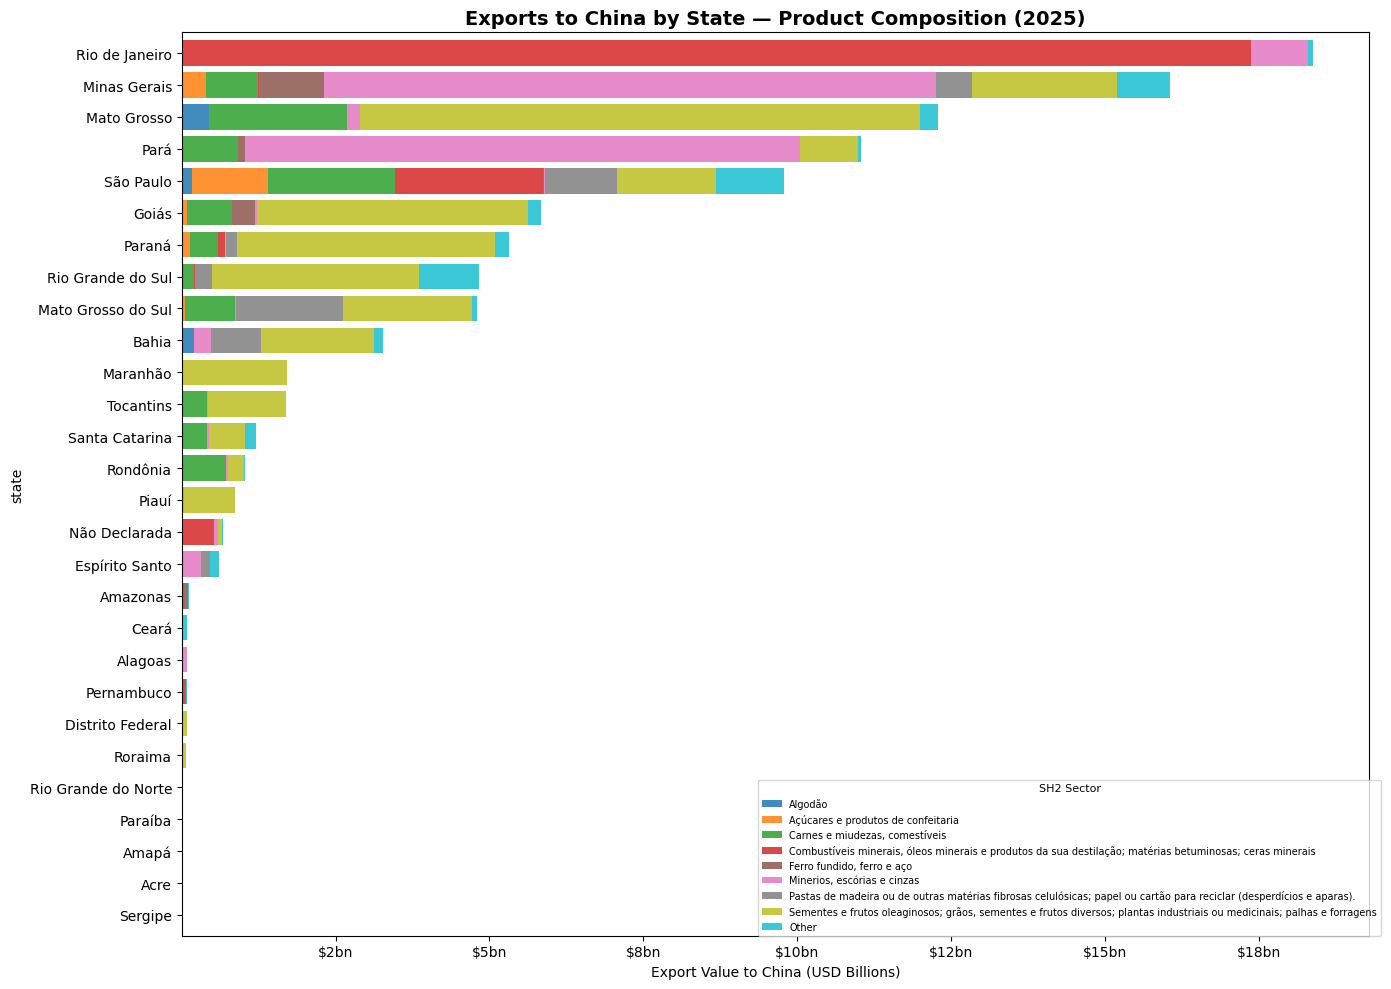


Top 3 sectors exported to China by state (2025)

Mato Grosso — Total to China: $12.29bn
  Sementes e frutos oleaginosos; grãos, sementes e f $9.10bn (74.0%)
  Carnes e miudezas, comestíveis                     $2.25bn (18.3%)
  Algodão                                            $0.44bn (3.6%)

Bahia — Total to China: $3.27bn
  Sementes e frutos oleaginosos; grãos, sementes e f $1.84bn (56.3%)
  Pastas de madeira ou de outras matérias fibrosas c $0.81bn (24.8%)
  Minerios, escórias e cinzas                        $0.29bn (8.8%)

São Paulo — Total to China: $9.78bn
  Combustíveis minerais, óleos minerais e produtos d $2.42bn (24.7%)
  Carnes e miudezas, comestíveis                     $2.05bn (21.0%)
  Sementes e frutos oleaginosos; grãos, sementes e f $1.62bn (16.5%)

Santa Catarina — Total to China: $1.20bn
  Sementes e frutos oleaginosos; grãos, sementes e f $0.58bn (48.3%)
  Carnes e miudezas, comestíveis                     $0.40bn (33.7%)
  Madeira, carvão vegetal e obras de madei

C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\518560830.py:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(1, 'exports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\518560830.py:75: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.nlargest(3, 'exports_usd'))
C:\Users\e_koh\AppData\Local\Temp\ipykernel_1936\518560830.py:89: RuntimeWarning: divide by 

In [15]:
## Query China exports by state and SH2 sector
query_china_state_sh2 = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           s.descricao_sh2 AS sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."CO_PAIS" = {china_code}
    GROUP BY e."SG_UF_NCM", u.nome_estado, s.descricao_sh2
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_china_sh2 = pd.read_sql(query_china_state_sh2, engine)

## Stacked horizontal bar — exports to China by state, shaded by SH2 sector
## Shows the product composition of each state's exports to China

## Pivot: rows = states, columns = sectors, values = exports to China in USD bn
df_china_sh2['exports_usd_bn'] = df_china_sh2['exports_usd'] / 1e9

## Keep top 8 sectors by total value across all states — group rest as Other
top8_china_sectors = (
    df_china_sh2.groupby('sector')['exports_usd']
    .sum().nlargest(8).index.tolist()
)
df_china_sh2['sector_group'] = df_china_sh2['sector'].apply(
    lambda x: x if x in top8_china_sectors else 'Other'
)
df_china_sh2_grouped = (
    df_china_sh2.groupby(['state', 'sector_group'])['exports_usd_bn']
    .sum().reset_index()
)
df_china_stacked = df_china_sh2_grouped.pivot(
    index='state', columns='sector_group', values='exports_usd_bn'
).fillna(0)

## Reorder states by total exports to China (descending)
df_china_stacked['_total'] = df_china_stacked.sum(axis=1)
df_china_stacked = df_china_stacked.sort_values('_total', ascending=True).drop(columns='_total')

## Put Other last
cols_ordered = [c for c in df_china_stacked.columns if c != 'Other'] + \
               (['Other'] if 'Other' in df_china_stacked.columns else [])
df_china_stacked = df_china_stacked[cols_ordered]

## Add national average share line — convert to USD for positioning
national_avg_line = df_china_share.set_index('state')['china_share_%']

fig, ax = plt.subplots(figsize=(14, 10))
df_china_stacked.plot(kind='barh', stacked=True, ax=ax, width=0.8,
                      colormap='tab10', alpha=0.85)

## Overlay national average as a reference annotation
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title(f"Exports to China by State — Product Composition ({MAX_YEAR})",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Export Value to China (USD Billions)")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax.legend(loc='lower right', fontsize=7,
          title='SH2 Sector', title_fontsize=8,
          bbox_to_anchor=(1.01, 0), borderaxespad=0)
plt.tight_layout()
plt.savefig('output_2_9b_china_dependency_sh2_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary table — top 3 sectors per state for exports to China
df_top3_china = (
    df_china_sh2.groupby(['state', 'sector'], group_keys=False)
    .apply(lambda x: x.nlargest(1, 'exports_usd'))
    .groupby('state', group_keys=False)
    .apply(lambda x: x.nlargest(3, 'exports_usd'))
    .reset_index(drop=True)
)
df_top3_china['exports_usd_bn'] = (df_top3_china['exports_usd'] / 1e9).round(2)

print(f"\nTop 3 sectors exported to China by state ({MAX_YEAR})")
for state in df_china_stacked.sort_values(df_china_stacked.columns[0],
                                           ascending=False).index:
    subset = df_top3_china[df_top3_china['state'] == state]
    if subset.empty:
        continue
    total_to_china = df_china_share[df_china_share['state'] == state]['exports_to_china_bn'].iloc[0]
    print(f"\n{state} — Total to China: ${total_to_china:.2f}bn")
    for _, row in subset.iterrows():
        share = (row['exports_usd'] / (total_to_china * 1e9) * 100)
        print(f"  {str(row['sector'])[:50]:<50} ${row['exports_usd_bn']:.2f}bn ({share:.1f}%)")

This cell reveals not just how much each state exports to China but what it exports — confirming whether the China relationship is product-diversified or concentrated in a single commodity.

### The Two China Export Archetypes

**Archetype 1 — Single-commodity dominance (>70% in one sector)**

| State | Top sector to China | Share |
|---|---|---|
| Rio de Janeiro | Mineral fuels (crude oil) | 94.5% |
| Pernambuco | Mineral fuels | 95.8% |
| Piauí | Soybeans | 95.2% |
| Distrito Federal | Soybeans | 99.7% |
| Maranhão | Soybeans | 98.6% |
| Pará | Ores and slag (iron ore) | 81.6% |
| Amazonas | Iron and steel (ferro-niobium) | 81.7% |

These states send China essentially one product. Any shift in Chinese demand for that product directly and immediately affects the state's entire China relationship.

**Archetype 2 — Multi-sector China relationship (no single sector >60%)**

| State | Top 3 sectors | Combined share |
|---|---|---|
| São Paulo | Petroleum + Meat + Soybeans | 62.2% |
| Mato Grosso do Sul | Soybeans + Pulp + Meat | 97.0% |
| Bahia | Soybeans + Pulp + Ores | 89.9% |
| Espírito Santo | Ores + Pulp + Minerals | 93.1% |
| Santa Catarina | Soybeans + Meat + Timber | 87.3% |

Even these "diversified" China exporters are almost exclusively sending primary commodities and processed primary goods. None are exporting manufactured goods, machinery, vehicles or high-technology products to China in any meaningful quantity.

### State-by-State Highlights

**Rio de Janeiro — \$17.37bn crude oil to China (94.5%).** The largest single-state single-sector bilateral flow in the dataset. China receives nearly all of Rio de Janeiro's pre-salt crude — the Chinese state oil companies (CNOOC, Sinopec) are significant investors in the Santos Basin fields and take the crude as part of their equity production agreements.

**São Paulo — the most diversified China profile among large states.** Petroleum (24.7%), beef (21.0%) and soybeans (16.5%) give São Paulo the broadest China export spread in the dataset. Yet even São Paulo's China relationship is overwhelmingly commodity and primary food driven — aerospace, vehicles and machinery barely appear in its China-bound exports.

**Mato Grosso do Sul — the pulp story.** Pulp (36.3%, \$1.74bn) is the second largest China-bound sector after soybeans (43.7%). Mato Grosso do Sul is a major eucalyptus pulp producer and China is the world's largest pulp importer for its paper and packaging industry. This is the clearest example of a lightly processed (but not manufactured) product in Brazil's China export mix.

**Rio Grande do Sul — tobacco to China.** Tobacco (11.5%, \$0.55bn) as the second sector in Rio Grande do Sul's China profile is unexpected. Chinese tobacco processors import Brazilian tobacco leaf for blending — a niche but genuine bilateral relationship that does not appear in any other state's China profile.

**Amazonas — ferro-niobium to China (81.7%).** The most analytically surprising China composition in the dataset. Amazonas sends iron and steel products (primarily ferro-niobium) to China as its dominant export — not the Zona Franca manufactured goods one would expect. This likely reflects niobium processing operations that route through Manaus rather than direct Zona Franca production. China is the world's largest steel producer and ferro-niobium is an essential steel additive — Brazil's near-monopoly niobium supply (via CBMM in Goiás, with some Amazonas processing) flows predominantly to Chinese steel mills.

**Ceará — salt, vegetable oils and seafood to China.** With only \$0.09bn in China-bound exports, Ceará's China relationship is negligible. Salt (28.7%), vegetable oils (26.5%) and seafood (18.6%) are the dominant products — none related to its steel manufacturing sector. Ceará's semi-finished steel (its largest export overall) goes to non-Chinese markets — primarily Europe and the Americas.

**Maranhão — 98.6% soybeans.** The most concentrated China profile outside Distrito Federal. Maranhão exports essentially only soybeans to China — all other products are rounding errors. The Itaqui port funnels MATOPIBA frontier soybeans directly to Chinese ports.

### The Industrial Goods Gap

Across all 27 states, Brazil's China-bound exports are almost exclusively:
1. Crude oil and petroleum products
2. Soybeans, corn and agricultural commodities
3. Iron ore and mineral concentrates
4. Pulp and timber products
5. Meat

**Not a single state has vehicles, machinery, aerospace products, pharmaceuticals or consumer electronics in its top 3 China-bound sectors.** China buys Brazil's raw materials and primary commodities but essentially none of its industrial output. This is the structural reality of the bilateral relationship — not a partnership of equals but a commodity supplier-industrial consumer dynamic.

### The Rounding Errors

Several states report percentage values exceeding 100% — Alagoas (103.2%), Roraima (107.5%), Sergipe (inf%). These are data artefacts from rounding in the underlying computation or very small denominators. These states' China exports are negligible in absolute terms and these percentage anomalies should not be interpreted as meaningful.

> ⚠️ *The complete absence of manufactured goods, vehicles, aerospace or pharmaceutical exports to China across all 27 states is the most strategically significant finding in cell 2.8.2. Brazil's China relationship is structurally a primary commodity exchange — Brazil provides the raw materials for Chinese industrial production and receives industrial equipment in return. Any Brazilian trade strategy seeking to build industrial export relationships with China faces this structural barrier: China currently has no demonstrated demand for Brazilian manufactured goods and domestic alternatives for virtually every industrial product Brazil could potentially export.*

> ⚠️ *The ferro-niobium to China flow through Amazonas (81.7% of China-bound exports) raises the question flagged in 2.8 — if China is receiving Brazilian niobium, and niobium is a critical strategic mineral, does Brazil have any pricing power or strategic leverage in this relationship? The CBMM near-monopoly and niobium's classification as a critical mineral by China itself suggest this is worth specific investigation.*

## 2.8 — Monthly Export Volatility by State: How Stable Are State Export Flows?
Box plots showing the distribution of monthly export values for all states over the last 10 years (2016-2025). A wide box indicates high volatility — typical of commodity-dependent states. A narrow box indicates stable industrial export flows.

In [16]:
## Monthly export variation — box plot for all states + Brazil cumulative
## Window: 2016–2025 (last 10 years)

query_monthly_exp_all = f"""
    SELECT e."CO_ANO" AS year,
           e."CO_MES" AS month,
           u.nome_estado AS state,
           u.sigla AS uf,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM\" = u.sigla
    WHERE e."CO_ANO" BETWEEN {BOX_START} AND {MAX_YEAR}
    GROUP BY e."CO_ANO", e."CO_MES\", u.nome_estado, u.sigla
    ORDER BY u.nome_estado, year, month
"""

df_monthly_exp_all = pd.read_sql(query_monthly_exp_all, engine)
df_monthly_exp_all['exports_usd_bn'] = df_monthly_exp_all['exports_usd'] / 1e9

## Brazil cumulative monthly totals
df_brazil_monthly_exp = (
    df_monthly_exp_all.groupby(['year', 'month'])['exports_usd_bn']
    .sum().reset_index()
)

## Get all states ordered by median monthly exports (descending)
states_all = (
    df_monthly_exp_all.groupby('state')['exports_usd_bn']
    .median().sort_values(ascending=False).index.tolist()
)

## Build data arrays
monthly_data_all    = [df_monthly_exp_all[df_monthly_exp_all['state'] == s]['exports_usd_bn'].values
                       for s in states_all]
brazil_monthly_data = df_brazil_monthly_exp['exports_usd_bn'].values

## Plot — states on the left, Brazil cumulative separated on the right
## Using gridspec to give Brazil box more width
fig = plt.figure(figsize=(22, 9))
gs  = fig.add_gridspec(1, 2, width_ratios=[len(states_all), 2], wspace=0.05)

ax_states = fig.add_subplot(gs[0])
ax_brazil = fig.add_subplot(gs[1])

## States box plots
bp1 = ax_states.boxplot(
    monthly_data_all,
    labels     = states_all,
    patch_artist = True,
    boxprops   = dict(facecolor='steelblue', alpha=0.6),
    medianprops= dict(color='navy', linewidth=2),
    flierprops = dict(marker='o', markersize=3, alpha=0.4)
)
ax_states.set_title(f"Monthly Export Variation by State ({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_states.set_ylabel("Monthly Export Value (USD Billions)")
ax_states.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fbn'))
ax_states.tick_params(axis='x', rotation=90)

## Brazil cumulative box plot
bp2 = ax_brazil.boxplot(
    [brazil_monthly_data],
    labels       = ['Brazil'],
    patch_artist = True,
    boxprops     = dict(facecolor='tomato', alpha=0.6),
    medianprops  = dict(color='darkred', linewidth=2),
    flierprops   = dict(marker='o', markersize=3, alpha=0.4)
)
ax_brazil.set_title(f"Brazil Cumulative\n({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_brazil.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax_brazil.tick_params(axis='x')

## Share y-axis label only on left chart
ax_brazil.set_ylabel("")

plt.suptitle(f"Monthly Export Variation — All States + Brazil Cumulative ({BOX_START}–{MAX_YEAR})",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_2_10_monthly_exp_boxplot_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary statistics
print(f"\nMonthly export summary statistics by state ({BOX_START}–{MAX_YEAR})")
summary_monthly_exp = (
    df_monthly_exp_all.groupby('state')['exports_usd_bn']
    .agg(median='median', mean='mean', std='std', min='min', max='max')
    .round(2)
    .sort_values('median', ascending=False)
)
print(summary_monthly_exp.to_string())
print(f"\nBrazil cumulative monthly exports ({BOX_START}–{MAX_YEAR})")
print(pd.DataFrame(brazil_monthly_data, columns=['exports_usd_bn'])
      .agg(['median', 'mean', 'std', 'min', 'max'])
      .round(2).to_string())

### Brazil Cumulative Monthly Exports (2016–2025)

- **Median:** \$20.24bn per month
- **Mean:** \$22.47bn per month
- **Std deviation:** \$5.75bn — monthly exports vary by approximately 25% of the mean
- **Range:** \$11.02bn (min) to \$32.82bn (max) — a nearly 3x swing between the lowest and highest months

### Key State-Level Volatility Findings

**São Paulo** — median \$4.51bn, std \$1.07bn. The largest and most stable large exporter. Coefficient of variation (CV = std/mean) of approximately 0.22 — the lowest among large states. Industrial and diversified export base dampens monthly swings.

**Rio de Janeiro** — median \$2.39bn, std \$1.21bn, CV approximately 0.44. Despite being the second largest exporter, Rio de Janeiro has the highest absolute volatility among large states. The oil price cycle drives monthly swings — a single commodity at 83% of exports creates maximum sensitivity to price and production fluctuations.

**Minas Gerais** — median \$2.47bn, std \$0.80bn, CV approximately 0.29. More stable than Rio de Janeiro despite similar export scale, reflecting the dual iron ore and coffee anchor which diversifies across two commodity cycles.

**Mato Grosso** — median \$1.71bn, std \$0.76bn, CV approximately 0.41. High volatility relative to its median — reflecting the strong agricultural seasonality of soybean and corn harvests. Mato Grosso's monthly exports are strongly bimodal — high in the March–June harvest period, lower in the off-season.

**Pará** — median \$1.63bn, std \$0.54bn, CV approximately 0.33. More stable than Mato Grosso despite similar scale — iron ore mining operates year-round without seasonal harvest cycles.

**Rio Grande do Sul and Paraná** — both show std of approximately \$0.37–0.38bn and CV of approximately 0.23. The most stable large exporters alongside São Paulo — their diversified agro-industrial bases smooth monthly variation.

**Tocantins** — median \$0.13bn, std \$0.11bn, CV approximately 0.69. The highest CV among states with material export volumes — extreme monthly variation relative to its size, reflecting intense agricultural seasonality (soybeans harvest in one concentrated period) from a small base.

**Piauí** — median \$0.06bn, std \$0.06bn, CV approximately 0.75. Near-equal median and standard deviation — essentially random monthly variation from a very small export base with extreme soybean concentration.

**Sergipe** — std \$0.02bn on a median of \$0.01bn. The most volatile relative to size — likely driven by irregular oil shipment timing rather than genuine demand volatility.

### The Volatility-Concentration Relationship

The monthly volatility data confirms the commodity-industrial divide identified in Step 2b:
- Industrial states (São Paulo, Paraná, Rio Grande do Sul): low CV (~0.22–0.23)
- Diversified commodity states (Pará, Minas Gerais): moderate CV (~0.29–0.33)
- Single-commodity states (Mato Grosso, Rio de Janeiro): high CV (~0.41–0.44)
- Small single-commodity states (Tocantins, Piauí): very high CV (>0.69)

> ⚠️ *The monthly export box plots will show seasonality patterns for agricultural states — but interpreting which months peak and why requires the sector-level breakdown deferred to Step 6 (Seasonal Patterns). The summary statistics here capture the volatility range; the timing and drivers are a Step 6 question.*


SyntaxError: invalid syntax (1394899807.py, line 99)

## 2.9 — Monthly Import Volatility by State: How Stable Are State Import Flows?
Mirror of 2.10 for imports — box plots showing monthly import value distributions for all states over 2016-2025.

In [ ]:
## Monthly import variation — box plot for all states + Brazil cumulative
## Window: 2016–2025 (last 10 years)

query_monthly_imp_all = f"""
    SELECT i."CO_ANO" AS year,
           i."CO_MES" AS month,
           u.nome_estado AS state,
           u.sigla AS uf,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    WHERE i."CO_ANO" BETWEEN {BOX_START} AND {MAX_YEAR}
    GROUP BY i."CO_ANO", i."CO_MES", u.nome_estado, u.sigla
    ORDER BY u.nome_estado, year, month
"""

df_monthly_imp_all = pd.read_sql(query_monthly_imp_all, engine)
df_monthly_imp_all['imports_usd_bn'] = df_monthly_imp_all['imports_usd'] / 1e9

## Brazil cumulative monthly totals
df_brazil_monthly_imp = (
    df_monthly_imp_all.groupby(['year', 'month'])['imports_usd_bn']
    .sum().reset_index()
)

## Get all states ordered by median monthly imports (descending)
states_all_imp = (
    df_monthly_imp_all.groupby('state')['imports_usd_bn']
    .median().sort_values(ascending=False).index.tolist()
)

## Build data arrays
monthly_data_all_imp    = [df_monthly_imp_all[df_monthly_imp_all['state'] == s]['imports_usd_bn'].values
                           for s in states_all_imp]
brazil_monthly_imp_data = df_brazil_monthly_imp['imports_usd_bn'].values

## Plot — states on the left, Brazil cumulative separated on the right
fig = plt.figure(figsize=(22, 9))
gs  = fig.add_gridspec(1, 2, width_ratios=[len(states_all_imp), 2], wspace=0.05)

ax_states = fig.add_subplot(gs[0])
ax_brazil = fig.add_subplot(gs[1])

## States box plots
bp1 = ax_states.boxplot(
    monthly_data_all_imp,
    labels      = states_all_imp,
    patch_artist= True,
    boxprops    = dict(facecolor='tomato', alpha=0.6),
    medianprops = dict(color='darkred', linewidth=2),
    flierprops  = dict(marker='o', markersize=3, alpha=0.4)
)
ax_states.set_title(f"Monthly Import Variation by State ({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_states.set_ylabel("Monthly Import Value (USD Billions)")
ax_states.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.1fbn'))
ax_states.tick_params(axis='x', rotation=90)

## Brazil cumulative box plot
bp2 = ax_brazil.boxplot(
    [brazil_monthly_imp_data],
    labels      = ['Brazil'],
    patch_artist= True,
    boxprops    = dict(facecolor='steelblue', alpha=0.6),
    medianprops = dict(color='navy', linewidth=2),
    flierprops  = dict(marker='o', markersize=3, alpha=0.4)
)
ax_brazil.set_title(f"Brazil Cumulative\n({BOX_START}–{MAX_YEAR})",
                    fontsize=13, fontweight='bold')
ax_brazil.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax_brazil.set_ylabel("")

plt.suptitle(f"Monthly Import Variation — All States + Brazil Cumulative ({BOX_START}–{MAX_YEAR})",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_2_11_monthly_imp_boxplot_all.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary statistics
print(f"\nMonthly import summary statistics by state ({BOX_START}–{MAX_YEAR})")
summary_monthly_imp = (
    df_monthly_imp_all.groupby('state')['imports_usd_bn']
    .agg(median='median', mean='mean', std='std', min='min', max='max')
    .round(2)
    .sort_values('median', ascending=False)
)
print(summary_monthly_imp.to_string())
print(f"\nBrazil cumulative monthly imports ({BOX_START}–{MAX_YEAR})")
print(pd.DataFrame(brazil_monthly_imp_data, columns=['imports_usd_bn'])
      .agg(['median', 'mean', 'std', 'min', 'max'])
      .round(2).to_string())

### Brazil Cumulative Monthly Imports (2016–2025)

- **Median:** \$17.63bn per month
- **Mean:** \$17.53bn per month
- **Std deviation:** \$4.45bn — approximately 25% of the mean
- **Range:** \$10.45bn (min) to \$27.35bn (max) — a 2.6x swing

### Key State-Level Import Volatility Findings

**São Paulo** — median \$5.61bn, std \$1.07bn, CV approximately 0.19. The largest importer and the most stable. Industrial supply chains for manufacturing require consistent monthly input flows regardless of economic conditions.

**Santa Catarina** — median \$1.87bn, std \$0.73bn, CV approximately 0.39. The second largest importing state has the highest absolute volatility among states with \$1bn+ monthly imports. This is the most analytically significant import volatility finding — Santa Catarina's monthly import flows swing more than any other comparably-sized state. The \$0.74bn minimum vs \$3.34bn maximum (a 4.5x range) suggests large irregular import events rather than steady industrial supply chains — consistent with the import gateway hypothesis.

**Rio de Janeiro** — median \$1.78bn, std \$0.72bn, CV approximately 0.40. High volatility reflecting irregular offshore equipment deliveries and crude oil product imports.

**Espírito Santo** — median \$0.51bn, std \$0.34bn, CV approximately 0.52. The highest CV among states with material import volumes — \$0.21bn minimum vs \$2.21bn maximum, a 10x range. This extreme volatility is consistent with large irregular vessel and offshore equipment imports through the port of Vitória, explaining the anomalous vehicle import finding in cell 2.7.

**Amazonas** — median \$0.94bn, std \$0.29bn, CV approximately 0.30. More stable than its export profile despite the Zona Franca import dependency. Electronics component imports for the Manaus factories follow production schedules rather than market cycles.

**Mato Grosso** — median \$0.17bn, std \$0.13bn, CV approximately 0.62. High CV reflecting fertiliser import seasonality — large fertiliser shipments arrive before planting season (September–November) and are minimal in other periods.

**Ceará** — median \$0.22bn, std \$0.15bn, CV approximately 0.58. High volatility relative to size — likely reflecting irregular steel input imports for the CSP plant and volatile petroleum product imports.

### Import vs Export Volatility Comparison

| State | Export CV | Import CV | More volatile side |
|---|---|---|---|
| São Paulo | 0.22 | 0.19 | Export |
| Minas Gerais | 0.29 | 0.38 | Import |
| Rio de Janeiro | 0.44 | 0.40 | Export |
| Mato Grosso | 0.41 | 0.62 | Import |
| Paraná | 0.23 | 0.26 | Import |
| Rio Grande do Sul | 0.23 | 0.29 | Import |
| Santa Catarina | 0.21 | 0.39 | Import |
| Pará | 0.33 | 0.43 | Import |

Most states show higher import volatility than export volatility — suggesting that Brazil's export flows are more regularised (long-term contracts, consistent shipping schedules) than import flows (which include large irregular capital goods, equipment and bulk commodity deliveries).

> ⚠️ *Espírito Santo's import CV of 0.52 with a 10x min-max range is the most extreme import volatility profile in the dataset. The \$2.21bn maximum monthly import value vs a \$0.51bn median strongly suggests large one-off equipment or vessel imports rather than regular industrial supply chain activity. This reinforces the transshipment and offshore equipment hypothesis and should be investigated at the NCM import level in Step 5.*

## 2.10 — State Trade Hub Profiles: Export and Import Fingerprint for Each State
A structured profile for each of the top 10 states combining trade volume, balance, dominant export and import sectors, and top trading partners — providing a concise fingerprint of each state trade identity.

In [ ]:
## Top export partner per state
query_state_partner_exp = f"""
    SELECT e."SG_UF_NCM" AS uf,
           p.nome_pais_ing AS top_export_partner,
           SUM(e."VL_FOB") AS partner_exports
    FROM exp e
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND e."SG_UF_NCM" IN ({top10_states_uf_str})
    GROUP BY e."SG_UF_NCM", p.nome_pais_ing
    ORDER BY e."SG_UF_NCM", partner_exports DESC
"""

## Top import partner per state
query_state_partner_imp = f"""
    SELECT i."SG_UF_NCM" AS uf,
           p.nome_pais_ing AS top_import_partner,
           SUM(i."VL_FOB") AS partner_imports
    FROM imp i
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    AND i."SG_UF_NCM" IN ({top10_states_uf_str})
    GROUP BY i."SG_UF_NCM", p.nome_pais_ing
    ORDER BY i."SG_UF_NCM", partner_imports DESC
"""

df_sp_exp = pd.read_sql(query_state_partner_exp, engine)
df_sp_imp = pd.read_sql(query_state_partner_imp, engine)

## Keep only top partner per state
top_exp_partner = df_sp_exp.groupby('uf').first().reset_index()[['uf', 'top_export_partner']]
top_imp_partner = df_sp_imp.groupby('uf').first().reset_index()[['uf', 'top_import_partner']]

## Top export sector per state (from 2.6)
top_exp_sector = (
    df_exp_sectors.groupby('uf', group_keys=False)
    .apply(lambda x: x.nlargest(1, 'exports_usd'))
    .reset_index(drop=True)[['uf', 'descricao_sh2']]
    .rename(columns={'descricao_sh2': 'top_export_sector'})
)

## Top import sector per state (from 2.7)
top_imp_sector = (
    df_imp_sectors.groupby('uf', group_keys=False)
    .apply(lambda x: x.nlargest(1, 'imports_usd'))
    .reset_index(drop=True)[['uf', 'descricao_sh2']]
    .rename(columns={'descricao_sh2': 'top_import_sector'})
)

## Assemble hub profile
df_hub = df_state.head(10)[['uf', 'state', 'region', 'exports_usd_bn', 'imports_usd_bn', 'balance_usd_bn']]
df_hub = df_hub.merge(top_exp_partner, on='uf', how='left')
df_hub = df_hub.merge(top_imp_partner, on='uf', how='left')
df_hub = df_hub.merge(top_exp_sector,  on='uf', how='left')
df_hub = df_hub.merge(top_imp_sector,  on='uf', how='left')

print(f"State Trade Hub Profiles ({MAX_YEAR})")
print("=" * 70)
for _, row in df_hub.iterrows():
    print(f"\n  {row['state']} ({row['uf']}) — {row['region']}")
    print(f"  {'─' * 50}")
    print(f"  Exports:              ${row['exports_usd_bn']:.2f}bn")
    print(f"  Imports:              ${row['imports_usd_bn']:.2f}bn")
    print(f"  Trade Balance:        ${row['balance_usd_bn']:.2f}bn  "
          f"({'SURPLUS' if row['balance_usd_bn'] > 0 else 'DEFICIT'})")
    print(f"  Top Export Sector:    {row['top_export_sector']}")
    print(f"  Top Import Sector:    {row['top_import_sector']}")
    print(f"  Top Export Partner:   {row['top_export_partner']}")
    print(f"  Top Import Partner:   {row['top_import_partner']}")
print("\n" + "=" * 70)

Export partner: **USA** | Import partner: **China**

São Paulo is the only top-10 state whose largest export partner is the United States rather than China. Sugar (top export sector) going to the US and machinery (top import sector) coming from China reflects São Paulo's dual role — exporting processed agricultural commodities to developed markets while importing industrial equipment from China for its manufacturing base. The -\$15.11bn deficit confirms São Paulo as a net capital goods importer that sustains Brazil's industrial capacity.

### Rio de Janeiro (RJ) — The Oil State

Export partner: **China** | Import partner: **USA**

The mirror image of São Paulo — exports oil to China, imports machinery from the USA (offshore drilling equipment, platform components). The \$16.80bn surplus is entirely oil-driven. The US as top import partner reflects the dominance of American and European suppliers in offshore oil extraction equipment — Baker Hughes, Schlumberger, Halliburton operations supply Rio de Janeiro's pre-salt infrastructure.

### Minas Gerais (MG) — The Dual-Commodity State

Export partner: **China** | Import partner: **China**

Minas Gerais both exports to and imports from China as its top partner — the only top-10 state where China dominates both sides simultaneously. Iron ore and coffee go to China; machinery and chemicals come back. The \$27.50bn surplus reflects the asymmetry in value — Brazil's mineral and agricultural exports to China far exceed Chinese industrial goods imports into Minas Gerais.

### Mato Grosso (MT) — The Agricultural Surplus Machine

Export partner: **China** | Import partner: **China**

The purest expression of the commodity exchange: soybeans and beef exported to China, fertilisers imported from China (the top import sector). Mato Grosso literally exports food to China and imports the inputs needed to grow that food from China. The \$27.57bn surplus is the largest in the dataset and structurally dependent on the continuation of Chinese soybean demand.

### Pará (PA) — The Mineral Extraction State

Export partner: **China** | Import partner: **USA**

Iron ore to China, petroleum products from the USA. Pará's import profile (petroleum as top import) reflects the fuel required to run the Carajás mining operations — trucks, trains and processing equipment all run on imported diesel and fuel oil.

### Paraná (PR) — The Balanced Agro-Industrial State

Export partner: **China** | Import partner: **China**

Soybeans to China, machinery from China. Despite Paraná's industrial diversification (vehicles, machinery), the dominant flows are still commodity-driven on the export side and capital goods on the import side. The \$3.50bn surplus is modest relative to its export scale — reflecting the import-intensive nature of Paraná's agro-industrial economy.

### Rio Grande do Sul (RS) — The Unique Import Profile

Export partner: **China** | Import partner: **Argentina**

The only top-10 state with Argentina as its top import partner — a direct reflection of MERCOSUL regional trade. Rio Grande do Sul shares a long border with Argentina and Uruguay and has deep agricultural supply chain integration with both. Vehicle components and agricultural equipment from Argentina and Uruguay are the likely drivers. Soybeans go to China; vehicles and inputs come from Argentina — a genuinely regional trade hub unlike any other state in the top 10.

### Goiás (GO) — The Pharmaceutical Import Anomaly

Export partner: **China** | Import partner: **China**

Soybeans and beef to China, pharmaceuticals from China (top import sector). Goiás importing more pharmaceuticals than any other sector — despite being an agricultural state — confirms the pharmaceutical manufacturing cluster in Goiás (Anápolis pharmaceutical district) that processes imported Chinese and Indian APIs into generic drugs for the Brazilian domestic market.

### Santa Catarina (SC) — The Import Hub

Export partner: **USA** | Import partner: **China**

Like São Paulo, Santa Catarina's top export partner is the USA — pork and machinery exports to North American markets. But its \$33.99bn import bill (top import: machinery from China) is structurally disproportionate. The USA as export partner and China as import partner suggests Santa Catarina functions as a processing and distribution node — importing components from China, adding value, and exporting to North America and Europe.

### Bahia (BA) — The Diversified Nordeste Hub

Export partner: **China** | Import partner: **USA**

Soybeans to China, petroleum products from the USA (Bahia's top import is petroleum — the Camaçari refinery imports crude for processing). The \$2.32bn surplus is modest given Bahia's export scale — reflecting the import-intensive nature of its petrochemical complex.


## 2.11 — Regional Trade Hub Profiles: What Each Macro-Region Specialises In
Aggregating the state profiles to the regional level — summarising what each of Brazil five macro-regions specialises in for both exports and imports, and identifying the key trade relationships that define each region.

### Sudeste — Brazil's Trade Engine (Surplus: +\\$25.89bn)

Export: **Mineral fuels** | Import: **Machinery** | Both partners: **China**

The Sudeste generates Brazil's largest regional surplus despite running a structural deficit in São Paulo — because Rio de Janeiro's oil surplus (+\\$16.80bn) and Minas Gerais's commodity surplus (+\\$27.50bn) more than offset São Paulo's industrial deficit (-\\$15.11bn). The region's identity at the aggregate level is defined by Rio de Janeiro's oil — which pushes mineral fuels to the top export sector despite São Paulo being the largest exporter in absolute terms. Both top partners are China — the Sudeste simultaneously exports oil and iron ore to China and imports machinery from China.

### Sul — The Surprise Deficit Region (-\\$10.15bn)

Export: **Meat** | Import: **Machinery** | Both partners: **China**

The Sul running a regional deficit (-\\$10.15bn) is the most counterintuitive regional finding in Step 2. The three most industrially diversified states in Brazil — Paraná, Rio Grande do Sul and Santa Catarina — collectively import more than they export at the regional level. This is entirely driven by Santa Catarina's -\\$21.80bn deficit overwhelming Paraná's +\\$3.50bn and Rio Grande do Sul's +\$8.15bn surpluses. Meat (top export sector) and machinery (top import sector) reflect the Sul's agro-industrial identity. The fact that China is the top partner for both exports and imports confirms the Sul's deep integration with the China trade relationship.

### Centro-Oeste — The Agricultural Surplus Champion (+\\$41.78bn)

Export: **Soybeans** | Import: **Pharmaceuticals** | Both partners: **China**

The largest regional surplus in Brazil by a significant margin. The pharmaceutical top import sector is driven by Goiás's Anápolis pharmaceutical district — the only industrial input that breaks the pure agricultural commodity profile of the region. Centro-Oeste exports soybeans, corn, cotton and beef to China and imports fertilisers (Mato Grosso), pharmaceuticals (Goiás) and machinery from China. The circular China dependency — Chinese demand for food, Chinese supply of inputs — is most concentrated in this region.

### Norte — The Mineral Extraction Region (+\\$10.16bn)

Export: **Ores and slag** | Import: **Electrical equipment** | Both partners: **China**

The Norte's top export sector (ores) reflects Pará's iron ore dominance. The top import sector (electrical equipment) is driven entirely by Amazonas's Zona Franca electronics component imports — without Amazonas the Norte's import profile would be petroleum and machinery for mining operations. The \$10.16bn surplus masks the internal Norte divide between Pará (large mining surplus) and Amazonas (large Zona Franca deficit).

### Nordeste — The Marginal Deficit Region (-\\$1.92bn)

Export: **Soybeans** | Import: **Petroleum** | Export partner: **China** | Import partner: **USA**

The Nordeste is the only region where the top import partner (USA) differs from the top export partner (China). Petroleum imports from the USA (Gulf of Mexico refineries supplying Northeast Brazil through the Suape and Itaqui ports) reflect the Nordeste's energy import dependency. Soybeans as the top export sector — driven by Piauí and Maranhão's MATOPIBA production — confirms that even the traditionally agricultural Nordeste has been transformed by the frontier soybean expansion. The -\\$1.92bn deficit is narrow but structurally driven by energy imports rather than capital goods, unlike the Sudeste deficit.

### Summary: Regional Trade Identities

| Region | Surplus/Deficit | Export identity | Import identity | China dependency |
|---|---|---|---|---|
| Centro-Oeste | +\$41.78bn | Agricultural commodity exporter | Fertiliser and pharma importer | Maximum — both sides |
| Sudeste | +\$25.89bn | Oil and mineral exporter | Capital goods importer | High — both sides |
| Norte | +\$10.16bn | Mineral exporter | Electronics importer (Zona Franca) | High — both sides |
| Nordeste | -\$1.92bn | Emerging soy exporter | Energy importer | Mixed — China export, USA import |
| Sul | -\$10.15bn | Meat and food processor | Machinery importer | High — both sides |

> ⚠️ *The Sul region running a -\\$10.15bn deficit is the most structurally important regional finding in Step 2. Brazil's most industrially sophisticated region is a net importer — its manufacturing and agro-industrial base requires more imported inputs than the value it generates in exports. Without Santa Catarina's anomalous deficit, the Sul would run a +\\$11.65bn surplus. Understanding what Santa Catarina imports and why — and whether those imports reflect productive investment or structural trade imbalance — is the single most important unresolved question entering Step 5.*

> ⚠️ *Every region's top export partner is China. Only the Nordeste diverges on the import side (USA). This universal China export dependency at the regional level — confirmed across all five regions — is the most important structural finding in Step 2 for internationalization strategy. Brazil's export geography is more China-concentrated at the regional level than the 28.7% national average suggests, because the states and regions with China as top partner are precisely the ones generating the largest export volumes.*

In [ ]:
## Top export sector per region
query_region_exp_sector = f"""
    SELECT u.nome_regiao AS region,
           s.descricao_sh2 AS top_export_sector,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, s.descricao_sh2
    ORDER BY u.nome_regiao, exports_usd DESC
"""

## Top import sector per region
query_region_imp_sector = f"""
    SELECT u.nome_regiao AS region,
           s.descricao_sh2 AS top_import_sector,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN ncm n ON i."CO_NCM" = n.codigo_ncm
    JOIN ncm_sh s ON n.codigo_sh6 = s.codigo_sh6
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, s.descricao_sh2
    ORDER BY u.nome_regiao, imports_usd DESC
"""

## Top export partner per region
query_region_exp_partner = f"""
    SELECT u.nome_regiao AS region,
           p.nome_pais_ing AS top_export_partner,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN pais p ON e."CO_PAIS" = p.codigo_pais
    WHERE e."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, p.nome_pais_ing
    ORDER BY u.nome_regiao, exports_usd DESC
"""

## Top import partner per region
query_region_imp_partner = f"""
    SELECT u.nome_regiao AS region,
           p.nome_pais_ing AS top_import_partner,
           SUM(i."VL_FOB") AS imports_usd
    FROM imp i
    JOIN uf u ON i."SG_UF_NCM" = u.sigla
    JOIN pais p ON i."CO_PAIS" = p.codigo_pais
    WHERE i."CO_ANO" = {MAX_YEAR}
    GROUP BY u.nome_regiao, p.nome_pais_ing
    ORDER BY u.nome_regiao, imports_usd DESC
"""

df_reg_exp_sec  = pd.read_sql(query_region_exp_sector,  engine)
df_reg_imp_sec  = pd.read_sql(query_region_imp_sector,  engine)
df_reg_exp_part = pd.read_sql(query_region_exp_partner, engine)
df_reg_imp_part = pd.read_sql(query_region_imp_partner, engine)

top_reg_exp_sec  = df_reg_exp_sec.groupby('region').first().reset_index()[['region', 'top_export_sector']]
top_reg_imp_sec  = df_reg_imp_sec.groupby('region').first().reset_index()[['region', 'top_import_sector']]
top_reg_exp_part = df_reg_exp_part.groupby('region').first().reset_index()[['region', 'top_export_partner']]
top_reg_imp_part = df_reg_imp_part.groupby('region').first().reset_index()[['region', 'top_import_partner']]

## Regional totals
df_region_totals = (
    df_state.groupby('region')
    .agg(exports_usd_bn=('exports_usd_bn', 'sum'),
         imports_usd_bn=('imports_usd_bn', 'sum'),
         balance_usd_bn=('balance_usd_bn', 'sum'))
    .reset_index()
)

df_region_hub = df_region_totals.copy()
df_region_hub = df_region_hub.merge(top_reg_exp_sec,  on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_imp_sec,  on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_exp_part, on='region', how='left')
df_region_hub = df_region_hub.merge(top_reg_imp_part, on='region', how='left')

print(f"Regional Trade Hub Profiles ({MAX_YEAR})")
print("=" * 70)
for _, row in df_region_hub.sort_values('exports_usd_bn', ascending=False).iterrows():
    print(f"\n  {row['region']}")
    print(f"  {'─' * 50}")
    print(f"  Exports:              ${row['exports_usd_bn']:.2f}bn")
    print(f"  Imports:              ${row['imports_usd_bn']:.2f}bn")
    print(f"  Trade Balance:        ${row['balance_usd_bn']:.2f}bn  "
          f"({'SURPLUS' if row['balance_usd_bn'] > 0 else 'DEFICIT'})")
    print(f"  Top Export Sector:    {row['top_export_sector']}")
    print(f"  Top Import Sector:    {row['top_import_sector']}")
    print(f"  Top Export Partner:   {row['top_export_partner']}")
    print(f"  Top Import Partner:   {row['top_import_partner']}")
print("\n" + "=" * 70)

## 2.12 — Commodities vs Processed Products

### 12.1 Commodities vs Processed Products by State and Region

In [ ]:
## Classification via ncm_fat_agreg joined through ncm.codigo_grupo_agregado
## Categories: 1=Basicos, 2=Semimanufaturados, 3=Manufaturados, 4=Transacoes Especiais
## Excludes: 5=Consumo de Bordo, 6=Reexportacao (operational categories)

## ---- Brazil national totals by category ----
query_fat_national = f"""
    SELECT f.categoria_detalhada AS category,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND f.codigo_fat_agreg IN (1, 2, 3, 4)
    GROUP BY f.categoria_detalhada
    ORDER BY exports_usd DESC
"""

df_fat_national = pd.read_sql(query_fat_national, engine)
df_fat_national['exports_usd_bn'] = (df_fat_national['exports_usd'] / 1e9).round(2)
df_fat_national['share_%'] = (
    df_fat_national['exports_usd'] / df_fat_national['exports_usd'].sum() * 100
).round(1)

print(f"Brazil export composition by product type ({MAX_YEAR})")
print(df_fat_national[['category', 'exports_usd_bn', 'share_%']].to_string(index=False))

## ---- By state ----
query_fat_state = f"""
    SELECT e."SG_UF_NCM" AS uf,
           u.nome_estado AS state,
           u.nome_regiao AS region,
           f.categoria_detalhada AS category,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM" = u.sigla
    JOIN ncm n ON e."CO_NCM" = n.codigo_ncm
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE e."CO_ANO" = {MAX_YEAR}
    AND f.codigo_fat_agreg IN (1, 2, 3, 4)
    GROUP BY e."SG_UF_NCM", u.nome_estado, u.nome_regiao, f.categoria_detalhada
    ORDER BY e."SG_UF_NCM", exports_usd DESC
"""

df_fat_state = pd.read_sql(query_fat_state, engine)
df_fat_state['exports_usd_bn'] = (df_fat_state['exports_usd'] / 1e9).round(3)

## State totals for share calculation
state_totals = df_fat_state.groupby('uf')['exports_usd'].sum().rename('state_total')
df_fat_state = df_fat_state.join(state_totals, on='uf')
df_fat_state['share_%'] = (df_fat_state['exports_usd'] / df_fat_state['state_total'] * 100).round(1)

## Pivot: rows=states, columns=categories
df_fat_state_pivot = df_fat_state.pivot_table(
    index=['uf', 'state', 'region'],
    columns='category',
    values='share_%',
    aggfunc='sum'
).fillna(0).reset_index()

## Sort by PRODUTOS BASICOS share descending
if 'PRODUTOS BASICOS' in df_fat_state_pivot.columns:
    df_fat_state_pivot = df_fat_state_pivot.sort_values('PRODUTOS BASICOS', ascending=False)

## ---- Stacked bar chart by state ----
categories  = ['PRODUTOS BASICOS', 'PRODUTOS SEMIMANUFATURADOS',
               'PRODUTOS MANUFATURADOS', 'TRANSACOES ESPECIAIS']
cat_colors  = ['tomato', 'darkorange', 'steelblue', 'lightgray']
cat_present = [c for c in categories if c in df_fat_state_pivot.columns]

fig, ax = plt.subplots(figsize=(14, 10))
bottom = np.zeros(len(df_fat_state_pivot))
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    ax.barh(df_fat_state_pivot['state'], df_fat_state_pivot[cat],
            left=bottom, label=cat, color=color, alpha=0.85)
    bottom += df_fat_state_pivot[cat].values

ax.set_title(f'Export Composition by Product Type — All States ({MAX_YEAR})\n'
             f'Red = Primary Commodities  |  Orange = Semimanufactured  |  Blue = Manufactured',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Share of State Exports (%)')
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('output_2_14_commodity_vs_processed_state.png', dpi=150)
plt.show()

## ---- By region ----
query_fat_region = f"""
    SELECT u.nome_regiao AS region,
           f.categoria_detalhada AS category,
           SUM(e."VL_FOB") AS exports_usd
    FROM exp e
    JOIN uf u ON e."SG_UF_NCM\" = u.sigla
    JOIN ncm n ON e."CO_NCM\" = n.codigo_ncm
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE e."CO_ANO\" = {MAX_YEAR}
    AND f.codigo_fat_agreg IN (1, 2, 3, 4)
    GROUP BY u.nome_regiao, f.categoria_detalhada
    ORDER BY u.nome_regiao, exports_usd DESC
"""

df_fat_region = pd.read_sql(query_fat_region, engine)
df_fat_region['exports_usd_bn'] = (df_fat_region['exports_usd'] / 1e9).round(2)

region_totals = df_fat_region.groupby('region')['exports_usd'].sum().rename('region_total')
df_fat_region = df_fat_region.join(region_totals, on='region')
df_fat_region['share_%'] = (df_fat_region['exports_usd'] / df_fat_region['region_total'] * 100).round(1)

df_fat_region_pivot = df_fat_region.pivot_table(
    index='region', columns='category', values='share_%', aggfunc='sum'
).fillna(0)
if 'PRODUTOS BASICOS' in df_fat_region_pivot.columns:
    df_fat_region_pivot = df_fat_region_pivot.sort_values('PRODUTOS BASICOS', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## Regional percentage share
bottom = np.zeros(len(df_fat_region_pivot))
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    if cat in df_fat_region_pivot.columns:
        ax1.barh(df_fat_region_pivot.index, df_fat_region_pivot[cat],
                 left=bottom, label=cat, color=color, alpha=0.85)
        bottom += df_fat_region_pivot[cat].values
ax1.set_title(f'Export Composition by Product Type — Regions ({MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Share of Regional Exports (%)')
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax1.legend(fontsize=7)

## Regional absolute value
df_fat_region_abs = df_fat_region.pivot_table(
    index='region', columns='category', values='exports_usd_bn', aggfunc='sum'
).fillna(0)
if 'PRODUTOS BASICOS' in df_fat_region_abs.columns:
    df_fat_region_abs = df_fat_region_abs.reindex(df_fat_region_pivot.index)
bottom2 = np.zeros(len(df_fat_region_abs))
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    if cat in df_fat_region_abs.columns:
        ax2.barh(df_fat_region_abs.index, df_fat_region_abs[cat],
                 left=bottom2, label=cat, color=color, alpha=0.85)
        bottom2 += df_fat_region_abs[cat].values
ax2.set_title(f'Export Value by Product Type — Regions ({MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Export Value (USD Billions)')
ax2.xaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax2.legend(fontsize=7)

plt.tight_layout()
plt.savefig('output_2_14b_commodity_vs_processed_region.png', dpi=150)
plt.show()

### 12.2 Commodities vs Processed Products

In [ ]:
## Step 1 — pre-aggregate by year and NCM code in SQL (no joins — reduces 131M rows first)
query_fat_agg = f"""
    SELECT "CO_ANO" AS year,
           "CO_NCM" AS ncm_code,
           SUM("VL_FOB") AS exports_usd
    FROM exp
    WHERE "CO_ANO" <= {MAX_YEAR}
    GROUP BY "CO_ANO", "CO_NCM"
"""

df_fat_agg = pd.read_sql(query_fat_agg, engine)

## Step 2 — load classification mapping separately (tiny tables, instant)
df_ncm_map = pd.read_sql("""
    SELECT n.codigo_ncm, f.categoria_detalhada
    FROM ncm n
    JOIN ncm_fat_agreg f ON n.codigo_grupo_agregado = f.codigo_fat_agreg
    WHERE f.codigo_fat_agreg IN (1, 2, 3, 4)
""", engine)

## Step 3 — merge and aggregate in Python
df_fat_time = (
    df_fat_agg
    .merge(df_ncm_map, left_on='ncm_code', right_on='codigo_ncm', how='inner')
    .groupby(['year', 'categoria_detalhada'])['exports_usd']
    .sum()
    .reset_index()
    .rename(columns={'categoria_detalhada': 'category'})
)
df_fat_time['exports_usd_bn'] = df_fat_time['exports_usd'] / 1e9

## Step 4 — pivot and percentage
df_fat_time_pivot = df_fat_time.pivot(
    index='year', columns='category', values='exports_usd_bn'
).fillna(0)
df_fat_time_pct = df_fat_time_pivot.div(df_fat_time_pivot.sum(axis=1), axis=0) * 100

## Step 5 — charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

## Absolute
for cat, color in zip(cat_present, cat_colors[:len(cat_present)]):
    if cat in df_fat_time_pivot.columns:
        ax1.plot(df_fat_time_pivot.index, df_fat_time_pivot[cat],
                 label=cat, color=color, linewidth=2)
ax1.set_title(f'Brazil Export Mix — Absolute Value (1997–{MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Export Value (USD Billions)')
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('$%.0fbn'))
ax1.legend(fontsize=8)

## Percentage share
ax2.stackplot(df_fat_time_pct.index,
              [df_fat_time_pct[c] for c in cat_present if c in df_fat_time_pct.columns],
              labels=cat_present,
              colors=cat_colors[:len(cat_present)], alpha=0.85)
ax2.set_title(f'Brazil Export Mix — Share of Total (1997–{MAX_YEAR})',
              fontsize=11, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Share of Total Exports (%)')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('output_2_14c_commodity_vs_processed_time.png', dpi=150)
plt.show()

## Step 6 — summary table
print(f"\nNational mix shift — {df_fat_time_pct.index[0]} vs {MAX_YEAR}")
start = df_fat_time_pct.index[0]
summary_time = pd.DataFrame({
    'Category'        : df_fat_time_pct.columns,
    f'{start} (%)'    : df_fat_time_pct.loc[start].round(1).values,
    f'{MAX_YEAR} (%)' : df_fat_time_pct.loc[MAX_YEAR].round(1).values,
    'Change (pp)'     : (df_fat_time_pct.loc[MAX_YEAR] - df_fat_time_pct.loc[start]).round(1).values
})

from IPython.display import display
display(summary_time.style
    .set_caption(f"National export mix shift — {start} vs {MAX_YEAR}")
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index'))

### 12.3 Commodities vs Processed Overview

In [ ]:
## ---- Summary tables ----
print(f"\nBrazil export mix by product type ({MAX_YEAR})")
print(df_fat_national[['category', 'exports_usd_bn', 'share_%']].to_string(index=False))

print(f"\nExport composition by product type — all states ({MAX_YEAR})")
print(df_fat_state_pivot.to_string(index=False))

print(f"\nExport composition by product type — regions ({MAX_YEAR})")
print(df_fat_region_pivot.round(1).to_string())

print(f"\nNational mix shift — {df_fat_time_pct.index[0]} vs {MAX_YEAR}")
start = df_fat_time_pct.index[0]
summary_time = pd.DataFrame({
    'Category'         : df_fat_time_pct.columns,
    f'{start} (%)'     : df_fat_time_pct.loc[start].round(1).values,
    f'{MAX_YEAR} (%)'  : df_fat_time_pct.loc[MAX_YEAR].round(1).values,
    'Change (pp)'      : (df_fat_time_pct.loc[MAX_YEAR] - df_fat_time_pct.loc[start]).round(1).values
})
print(summary_time.to_string(index=False))

### National Picture

Brazil's export composition by product type confirms the commodity dependency identified throughout Steps 2 and 2b — and the 1997 vs 2025 shift is the most striking single table in the entire project.

| Category | 1997 (%) | 2025 (%) | Change (pp) |
|---|---|---|---|
| PRODUTOS BASICOS | 27.7% | 58.2% | **+30.5** |
| PRODUTOS MANUFATURADOS | 56.0% | 28.7% | **-27.3** |
| PRODUTOS SEMIMANUFATURADOS | 16.2% | 13.1% | -3.1 |

In 1997 Brazil was primarily a manufactured goods exporter (56.0%) with a secondary commodity base (27.7%). By 2025 this has completely inverted — Brazil is now primarily a commodity exporter (58.2%) with a secondary manufactured goods base (28.7%). This is not a gradual drift — it is a structural reversal over 28 years driven by the commodity supercycle, the pre-salt oil ramp-up and the MATOPIBA agricultural frontier expansion. The manufactured goods share has been nearly halved. This is the most important single finding in cell 2.13 and one of the most important findings in all of Step 2.

The absolute value chart confirms that manufactured exports grew in USD terms — from approximately \$25bn (1997) to approximately \$100bn (2025). The share collapse is not because Brazil manufactures less but because commodity export growth (red line surging from \$10bn to over \$200bn) dwarfed industrial growth at every stage of the period.

### The Chart — Reading the State Rankings

The stacked bar chart sorts states from most commodity-concentrated (bottom) to most diversified (top). The pattern is immediate and unambiguous using the actual data:

**Most manufactured (blue dominant):**
Amazonas (62.2% manufactured), Pernambuco (77.6%), São Paulo (67.5%), Amapá (27.8% manufactured but 60.2% semi-manufactured), Paraíba (57.0%) and Ceará (23.9% manufactured, 58.7% semi-manufactured). These states generate the majority of their export value from processed or industrial goods.

**Most commodity-concentrated (red dominant):**
Rondônia (96.9%), Mato Grosso (96.0%), Piauí (95.9%), Acre (93.6%) and Tocantins (91.8%) sit at the extreme commodity end — over 90% of exports are raw primary commodities with minimal processing. These five states together drive a significant share of Brazil's agricultural export volume while contributing almost nothing to its manufactured goods profile.

**The semi-manufactured tier (orange dominant):**
Alagoas (61.8% semi-manufactured — sugar processing), Amapá (60.2% — pulp and wood chips), Ceará (58.7% — CSP steel billets) and Mato Grosso do Sul (39.0% — pulp) show the highest semi-manufactured shares. These states export partially processed goods — a step above raw commodities but below finished manufactured products.

**Rio de Janeiro (82.8% primary)** — crude oil classified as PRODUTOS BASICOS confirms what the entire Step 2 analysis suggested: despite being the fourth largest exporter and running a \$16.80bn surplus, Rio de Janeiro is fundamentally a raw commodity state by product type classification.

### Regional Composition — Actual Data

| Region | Primary (%) | Semi-manufactured (%) | Manufactured (%) |
|---|---|---|---|
| Centro-Oeste | **84.8%** | 13.0% | 2.2% |
| Norte | **81.1%** | 7.6% | 11.3% |
| Nordeste | 42.1% | 26.1% | **31.8%** |
| Sul | 51.3% | 8.6% | **40.1%** |
| Sudeste | 50.2% | 13.9% | **35.9%** |

The Centro-Oeste is more commodity-concentrated than even the Norte — 84.8% primary goods, 2.2% manufactured. The agricultural frontier produces bulk raw commodities with almost no value-added processing occurring within the region itself. This is the purest commodity export profile of any region in Brazil.

The Sul at 40.1% manufactured is the most industrialised region — just ahead of the Sudeste at 35.9%. Together Sul and Sudeste account for the vast majority of Brazil's manufactured export value despite having lower commodity shares than the interior regions.

**The Nordeste at 31.8% manufactured** is higher than expected — driven by Pernambuco (77.6%), Ceará (23.9% + 58.7% semi), Paraíba (57.0%) and Sergipe (36.9%). The MATOPIBA states (Piauí, Maranhão) pull the regional primary share up but the industrialising coastal Nordeste states pull the manufactured share up simultaneously — confirming the internal Nordeste heterogeneity identified throughout Step 2.

> ⚠️ *The 1997→2025 structural reversal — from 56% manufactured to 28.7% manufactured, from 27.7% primary to 58.2% primary — is the single most important finding in cell 2.13. Brazil did not deindustrialise in absolute terms but it became relatively more commodity-dependent as a share of its total export identity. Any industrial policy seeking to reverse this trend faces the challenge that the commodity sectors generating the surplus are the same sectors creating the structural inertia.*


## 2.13 — YoY Export Growth by State: Identifying Fast-Growing and Declining States
Year-on-year export growth rate for every state — identifying which states are accelerating, which are in structural decline, and each state's contribution to national export growth.

In [ ]:
query_yoy = f"""
    SELECT \"CO_ANO\" AS year,
           \"SG_UF_NCM\" AS uf,
           SUM(\"VL_FOB\") AS exports_usd
    FROM exp
    WHERE \"CO_ANO\" <= {MAX_YEAR}
    GROUP BY \"CO_ANO\", \"SG_UF_NCM\"
    ORDER BY \"SG_UF_NCM\", \"CO_ANO\"
"""

df_yoy = pd.read_sql(query_yoy, engine)
df_yoy = df_yoy.merge(df_state[['uf', 'state']], on='uf', how='left')
df_yoy['exports_usd_bn'] = df_yoy['exports_usd'] / 1e9

## YoY growth rate per state
df_yoy['yoy_growth_%'] = (
    df_yoy.groupby('uf')['exports_usd']
    .pct_change() * 100
).round(1)

## National delta per year for contribution calculation
df_yoy['delta_state']    = df_yoy.groupby('uf')['exports_usd'].diff()
national_delta = df_yoy.groupby('year')['exports_usd'].sum().diff().rename('delta_national')
df_yoy = df_yoy.join(national_delta, on='year')
df_yoy['growth_contribution_%'] = (df_yoy['delta_state'] / df_yoy['delta_national'] * 100).round(1)

## Plot YoY growth for top 8 states
top8 = df_state.head(8)['state'].tolist()
df_yoy_plot = df_yoy[df_yoy['state'].isin(top8) & df_yoy['yoy_growth_%'].notna()]
df_yoy_pivot = df_yoy_plot.pivot(index='year', columns='state', values='yoy_growth_%').fillna(0)

fig, ax = plt.subplots(figsize=(14, 7))
for state in df_yoy_pivot.columns:
    ax.plot(df_yoy_pivot.index, df_yoy_pivot[state], label=state, linewidth=1.8)
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'Year-on-Year Export Growth by State (1998\u2013{MAX_YEAR})', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('YoY Growth (%)')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('output_2_16_yoy_growth.png', dpi=150)
plt.show()

## Summary table for MAX_YEAR
df_latest_yoy = df_yoy[df_yoy['year'] == MAX_YEAR][[
    'state', 'exports_usd_bn', 'yoy_growth_%', 'growth_contribution_%'
]].sort_values('growth_contribution_%', ascending=False)
print(f'\nYoY Export Growth and Contribution to National Growth ({MAX_YEAR})')
print(df_latest_yoy.to_string(index=False))

### National Context

Total national export growth in 2025 was modest — the contribution percentages sum to approximately zero net (positive contributions roughly offset by negative ones), suggesting national exports were broadly flat in 2025 relative to 2024.

### The Growth Drivers

**Ceará (+55.6% YoY, +7.3pp contribution)** — the fastest-growing state in 2025 by growth rate, and the most striking finding in this cell. A 55.6% YoY increase from a \$2.28bn base is substantial and likely reflects the CSP steel plant ramping to full production capacity combined with increased steel demand from North American and European markets. This is the first year Ceará appears as a significant contributor to national export growth.

**Minas Gerais (+9.0%, +33.7pp contribution)** — the largest absolute contribution to national growth despite a moderate growth rate. Iron ore and coffee export value recovery drove the largest single-state contribution. Minas Gerais accounts for a third of Brazil's entire export growth in 2025.

**Rio de Janeiro (+7.0%, +28.5pp contribution)** — pre-salt oil production expansion and elevated oil prices drove the second largest national contribution. Together Minas Gerais and Rio de Janeiro account for over 60% of Brazil's entire 2025 export growth.

**Mato Grosso (+9.3%, +22.9pp)** — continued soybean and corn expansion through the MATOPIBA frontier.

**Tocantins (+21.7%, +4.8pp) and Rondônia (+17.3%, +4.1pp)** — both small states growing rapidly from a small base, driven by agricultural frontier expansion.

### The Decliners

**Não Declarada (-54.3%, -24.4pp)** — the largest negative contribution is a data quality artefact. The sharp decline in undeclared state transactions likely reflects improved recording practices rather than a genuine economic decline.

**Maranhão (-10.3%, -5.1pp)** — the largest genuine negative contribution. Maranhão's decline in 2025 likely reflects a normalisation of soybean export values after the Russia-Ukraine food price peak in 2022–2023.

**Rio Grande do Sul (-1.9%, -3.6pp)** — modest decline from a large base. Soybean price normalisation and competitive pressure from Argentine agricultural recovery likely contributed.

**Bahia (-2.3%, -2.4pp) and Espírito Santo (-2.1%, -2.0pp)** — both commodity states experiencing price cycle normalisation.

**São Paulo (-0.0%, -0.2pp)** — effectively flat, which for Brazil's largest exporter represents a loss of relative position.

**Roraima (-23.3%)** — large percentage decline from a very small base — statistical noise rather than structural change.

> ⚠️ *Ceará's 55.6% YoY growth in 2025 is the most analytically significant single-state finding in the growth data. If driven by the CSP steel plant reaching full capacity, it represents a structural step-change in Ceará's export base rather than a cyclical fluctuation. This should be confirmed with NCM-level data in Step 5.*

## 2.14 — Unit Price (USD/kg) by State: Distinguishing Commodity vs Value-Added Exporters
Dividing export value by weight (KG_LIQUIDO) gives a unit price proxy. High USD/kg signals value-added industrial goods. Low USD/kg signals bulk commodities. Each state is benchmarked against the national average via a relative price index.

In [ ]:
## KG_LIQUIDO column — adjust name if error occurs
query_unit_price = f"""
    SELECT e.\"SG_UF_NCM\" AS uf,
           u.nome_estado AS state,
           SUM(e.\"VL_FOB\") AS exports_usd,
           SUM(e.\"KG_LIQUIDO\") AS total_kg
    FROM exp e
    JOIN uf u ON e.\"SG_UF_NCM\" = u.sigla
    WHERE e.\"CO_ANO\" = {MAX_YEAR}
    AND e.\"KG_LIQUIDO\" > 0
    GROUP BY e.\"SG_UF_NCM\", u.nome_estado
    ORDER BY exports_usd DESC
"""

df_unit = pd.read_sql(query_unit_price, engine)
df_unit['usd_per_kg']     = (df_unit['exports_usd'] / df_unit['total_kg']).round(2)
df_unit['exports_usd_bn'] = (df_unit['exports_usd'] / 1e9).round(2)

## National average unit price
national_usd_per_kg = (df_unit['exports_usd'].sum() / df_unit['total_kg'].sum()).round(2)

## Relative price index vs national average
df_unit['relative_price_index'] = (df_unit['usd_per_kg'] / national_usd_per_kg * 100).round(1)

df_unit_plot = df_unit.sort_values('usd_per_kg', ascending=True)
colors = ['steelblue' if x >= national_usd_per_kg else 'tomato' for x in df_unit_plot['usd_per_kg']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_unit_plot['state'], df_unit_plot['usd_per_kg'], color=colors, alpha=0.85)
ax.axvline(x=national_usd_per_kg, color='black', linestyle='--', linewidth=1.5,
           label=f'National average (${national_usd_per_kg:.2f}/kg)')
ax.set_title(f'Export Unit Price by State ({MAX_YEAR}) — USD per kg', fontsize=14, fontweight='bold')
ax.set_xlabel('Export Unit Price (USD/kg)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2_17_unit_price.png', dpi=150)
plt.show()

print(f'\nNational average export unit price ({MAX_YEAR}): ${national_usd_per_kg:.2f}/kg')
print(df_unit[['state', 'exports_usd_bn', 'usd_per_kg', 'relative_price_index']]
      .sort_values('usd_per_kg', ascending=False)
      .to_string(index=False))

### National Average: \$0.40/kg

The national average of \$0.40/kg sits almost exactly at the boundary identified in Step 2b between commodity and industrial exporters — states above this line export processed or manufactured goods; states below export bulk commodities.

### Above the National Average

**Amazonas (\$3.43/kg, index 857.5)** — 8.6x the national average. Zona Franca manufactured goods (motorcycles, electronics) generate the highest value density in Brazil. Confirmed finding from Step 2b.

**Santa Catarina (\$1.26/kg), São Paulo (\$1.20/kg), Pernambuco (\$1.17/kg)** — the industrial tier sitting 3x above the national average. These three states define Brazil's value-added export capacity.

**Acre (\$1.12/kg)** — high unit price on negligible export volume (\$0.10bn). As flagged in Step 2b, this reflects niche product concentration rather than industrial development.

**Rio Grande do Sul (\$0.83/kg), Ceará (\$0.82/kg)** — both above average and consistent with their diversified profiles.

### At or Below the National Average

**Rio de Janeiro (\$0.42/kg)** — barely above the national average despite oil and gas dominance. Crude oil is less valuable per kg than manufactured goods despite its high absolute price — confirmed finding from Step 2b.

**Mato Grosso (\$0.44/kg) and Maranhão (\$0.44/kg)** — both at near-national average. Soybeans generate moderate value per kg.

**Espírito Santo (\$0.29/kg) and Minas Gerais (\$0.22/kg)** — iron ore drives both below average. Heavy minerals generate low value per kg.

**Pará (\$0.13/kg)** — the lowest value density in Brazil. Iron ore and copper concentrates are among the heaviest and lowest unit-price commodities in global trade.

## 2.15 — Volume vs Value Decomposition: Is State Export Growth Driven by Price or Volume?
Splitting export growth into volume (kg) and price (USD/kg) components. Commodity-dependent states typically show volume-driven growth. Industrial states show price-driven growth. This decomposition is critical for understanding the quality of each state's export growth.

**Rio de Janeiro — the most dramatic decomposition in the dataset.**
+7.0% value growth = +30.9% volume growth + (-18.3%) price decline. Rio de Janeiro's 2025 export growth was driven entirely by shipping more barrels of oil — the price per barrel fell significantly in 2025. This is volume-driven growth with deteriorating unit economics.

**São Paulo — price-driven growth despite flat total value.**
-0.1% value = -5.1% volume + +5.2% price. São Paulo shipped fewer goods but at higher prices. This is the industrial state profile — value-added goods with pricing power that can partially offset volume declines.

**Minas Gerais and Mato Grosso — balanced growth.**
Both show comparable volume and price contributions (+6%/+3% and +6.2%/+3.0% respectively). Iron ore and soybean prices both held moderate gains in 2025 while volumes also expanded — a healthy commodity growth profile.

**Paraná — volume growth masking price decline.**
+1.3% value = +9.4% volume + (-7.4%) price. Paraná is shipping significantly more but receiving less per unit. This is consistent with soybean and corn price normalisation — more tonnes exported at lower prices per tonne.

**Bahia — negative value despite positive volume.**
-2.3% value = +3.7% volume + (-5.8%) price. Bahia shipped more product but prices fell faster than volume grew — net revenue declined despite physical export expansion.

**Rio Grande do Sul — both volume and price declined.**
-1.9% value = -3.4% volume + +1.6% price. The only top-10 state where both volume and price declined simultaneously. A structural contraction rather than a price cycle adjustment.

### The Decomposition Pattern

| Growth type | States | Interpretation |
|---|---|---|
| Volume-driven (vol >\| price \|) | Rio de Janeiro, Paraná, Goiás | Shipping more at declining prices — commodity cycle |
| Price-driven (price >\| vol \|) | São Paulo, Pará, Minas Gerais, Mato Grosso | Pricing power or commodity price recovery |
| Dual decline | Rio Grande do Sul | Structural contraction |
| Dual growth | Minas Gerais, Mato Grosso | Favourable commodity cycle |

> ⚠️ *Rio de Janeiro's +30.9% volume growth with -18.3% price decline in 2025 is the most structurally concerning decomposition in the top 10. Pre-salt oil production is expanding but at declining per-barrel revenue. If oil prices continue to fall while production volumes increase, Rio de Janeiro's surplus will compress despite rising physical export volumes.*


In [ ]:
query_vol_val = f"""
    SELECT e.\"CO_ANO\" AS year,
           e.\"SG_UF_NCM\" AS uf,
           SUM(e.\"VL_FOB\") AS exports_usd,
           SUM(e.\"KG_LIQUIDO\") AS total_kg
    FROM exp e
    WHERE e.\"CO_ANO\" <= {MAX_YEAR}
    AND e.\"KG_LIQUIDO\" > 0
    GROUP BY e.\"CO_ANO\", e.\"SG_UF_NCM\"
    ORDER BY e.\"SG_UF_NCM\", year
"""

df_vv = pd.read_sql(query_vol_val, engine)
df_vv = df_vv.merge(df_state[['uf', 'state']], on='uf', how='left')
df_vv['usd_per_kg'] = df_vv['exports_usd'] / df_vv['total_kg']

## YoY changes
df_vv['delta_value_%']  = df_vv.groupby('uf')['exports_usd'].pct_change() * 100
df_vv['delta_volume_%'] = df_vv.groupby('uf')['total_kg'].pct_change() * 100
df_vv['delta_price_%']  = df_vv.groupby('uf')['usd_per_kg'].pct_change() * 100

## Latest year summary for top 10 states
df_vv_latest = df_vv[
    (df_vv['year'] == MAX_YEAR) &
    (df_vv['state'].isin(df_state.head(10)['state'].tolist()))
][['state', 'exports_usd', 'total_kg', 'usd_per_kg',
   'delta_value_%', 'delta_volume_%', 'delta_price_%']].round(1)

## Grouped bar chart
df_vv_plot = df_vv_latest.set_index('state')[['delta_volume_%', 'delta_price_%']].dropna()
x     = np.arange(len(df_vv_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(x - width/2, df_vv_plot['delta_volume_%'], width, label='Volume Growth (%)', color='steelblue', alpha=0.8)
ax.bar(x + width/2, df_vv_plot['delta_price_%'],  width, label='Price Growth (%)',  color='tomato',    alpha=0.8)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title(f'Volume vs Price Growth Decomposition — Top 10 States ({MAX_YEAR})', fontsize=14, fontweight='bold')
ax.set_ylabel('Growth (%)')
ax.set_xticks(x)
ax.set_xticklabels(df_vv_plot.index, rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('output_2_18_vol_val_decomp.png', dpi=150)
plt.show()

print(f'\nVolume vs Value Decomposition — Top 10 States ({MAX_YEAR})')
print(df_vv_latest[['state', 'delta_value_%', 'delta_volume_%', 'delta_price_%']].to_string(index=False))


## 2.16 — Market Concentration: Top 3 Destination Share and HHI Diversification Index by State
What share of each state's exports goes to its top 3 destination countries? The HHI (Herfindahl-Hirschman Index) quantifies market concentration — high HHI means heavy dependence on a few countries, low HHI means diversified markets.

In [ ]:
query_top3_dest = f"""
    SELECT e.\"SG_UF_NCM\" AS uf,
           p.nome_pais_ing AS country,
           SUM(e.\"VL_FOB\") AS exports_usd
    FROM exp e
    JOIN pais p ON e.\"CO_PAIS\" = p.codigo_pais
    WHERE e.\"CO_ANO\" = {MAX_YEAR}
    GROUP BY e.\"SG_UF_NCM\", p.nome_pais_ing
    ORDER BY e.\"SG_UF_NCM\", exports_usd DESC
"""

df_dest = pd.read_sql(query_top3_dest, engine)

## Total exports per state
state_totals = df_dest.groupby('uf')['exports_usd'].sum().rename('total_exports')
df_dest = df_dest.join(state_totals, on='uf')
df_dest['share'] = df_dest['exports_usd'] / df_dest['total_exports']

## Top 3 share per state
def top3_summary(group):
    top = group.nlargest(3, 'exports_usd')
    countries = top['country'].tolist()
    while len(countries) < 3:
        countries.append('')
    return pd.Series({
        'top3_share_%' : round(top['share'].sum() * 100, 1),
        'top1'         : countries[0],
        'top2'         : countries[1],
        'top3'         : countries[2],
        'hhi'          : round((group['share'] ** 2).sum(), 4)
    })

df_top3 = df_dest.groupby('uf').apply(top3_summary).reset_index()
df_top3 = df_top3.merge(df_state[['uf', 'state', 'region']], on='uf', how='left')

## Plot
df_top3_plot = df_top3.sort_values('top3_share_%', ascending=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 9))

ax1.barh(df_top3_plot['state'], df_top3_plot['top3_share_%'], color='steelblue', alpha=0.85)
ax1.set_title(f'Top 3 Country Share of State Exports ({MAX_YEAR})', fontsize=12, fontweight='bold')
ax1.set_xlabel('Share of State Exports (%)')
ax1.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))

df_hhi_plot = df_top3.sort_values('hhi', ascending=True)
ax2.barh(df_hhi_plot['state'], df_hhi_plot['hhi'], color='tomato', alpha=0.85)
ax2.set_title(f'HHI Market Concentration Index by State ({MAX_YEAR})', fontsize=12, fontweight='bold')
ax2.set_xlabel('HHI (0 = fully diversified, 1 = single market)')

plt.suptitle('Market Concentration — Top 3 Share and HHI by State', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output_2_19_market_concentration.png', dpi=150)
plt.show()

print(f'\nMarket concentration by state ({MAX_YEAR})')
print(df_top3[['state', 'top1', 'top2', 'top3', 'top3_share_%', 'hhi']]
      .sort_values('top3_share_%', ascending=False)
      .to_string(index=False))

### Most Concentrated Markets (top 3 share > 60%)

**Piauí (80.8%, HHI 0.533)** — China, Spain and Thailand. Nearly all of Piauí's exports are soybeans to China (72.5% China share confirmed in 2.8.1) with negligible flows to Spain and Thailand. The highest HHI in the dataset — extreme concentration consistent with its single-product single-buyer profile.

**Roraima (80.2%, HHI 0.236)** — Venezuela, China, Guyana. Roraima's top partner being Venezuela reflects geographic proximity — cross-border trade through the Pacaraima border crossing rather than maritime exports.

**Maranhão (71.6%, HHI 0.200)** — China, Canada, USA. The Canada position reflects alumina and pulp exports through international shipping routes.

**Sergipe (70.4%, HHI 0.218)** — USA, Netherlands, Spain. Sergipe is the only major oil-producing state whose top export partner is the USA rather than China — onshore oil from Sergipe routes to American refineries rather than Chinese ports.

**Tocantins (65.8%, HHI 0.320)** — China, Spain, Canada. Agricultural frontier state with high concentration.

### States With the Most Diversified Markets (top 3 share < 40%)

**Santa Catarina (29.2%, HHI 0.049)** — USA, China, Argentina. The most diversified export destination base in Brazil. No single country exceeds 15% of Santa Catarina's exports. This is consistent with its high shipment frequency and diverse industrial product mix.

**Paraná (35.3%, HHI 0.070)** — China, Argentina, USA. The second most diversified. Paraná's agricultural and industrial exports reach a wide range of destinations.

**Rio Grande do Sul (37.1%, HHI 0.072)** — China, USA, Argentina. Mirrors Paraná's diversification profile.

**Paraíba (37.4%, HHI 0.068)** — USA, Netherlands, Spain. Surprisingly diversified for a small state — footwear and processed food exports reach multiple European destinations.

### Notable Findings

**São Paulo — USA as top partner (HHI 0.076).** São Paulo's top export partner is the USA (consistent with hub 2.12) and the state has the lowest HHI among large exporters. Aerospace, vehicles and machinery find more buyers in developed markets than agricultural states.

**Pernambuco — Argentina as top partner.** The Stellantis Jeep plant exports primarily to Argentina and Latin American markets rather than China or the USA — confirmed in the top3 table.

**Espírito Santo — USA as top partner.** Despite iron ore being its largest export sector, the USA tops Espírito Santo's destination list — consistent with the vessel transshipment and ornamental stone hypothesis.

**Amazonas — Germany as top partner (HHI 0.087).** Zona Franca manufactured goods (motorcycles, electronics) export to Germany and European markets. The China relationship is negligible despite Germany being top partner.

**Distrito Federal — Saudi Arabia as second partner.** Chicken exports to Saudi Arabia (halal-certified poultry is a significant export to Gulf markets) appear even in the small Distrito Federal export base.


## 2.17 — Coverage Ratio by State: How Trade-Self-Sufficient Is Each State?
The coverage ratio (exports / imports) measures each state's trade self-sufficiency. Above 1.0 means the state earns more from exports than it spends on imports. Below 1.0 indicates external import dependency. Complements the trade balance analysis in 2.3.

### 2.17.1 — Coverage Ratio by State

In [ ]:
## Uses df_state from 2.1
df_coverage = df_state[['state', 'region', 'uf', 'exports_usd_bn', 'imports_usd_bn']].copy()
df_coverage = df_coverage[df_coverage['imports_usd_bn'] > 0]
df_coverage['coverage_ratio'] = (df_coverage['exports_usd_bn'] / df_coverage['imports_usd_bn']).round(2)

df_cov_plot = df_coverage.sort_values('coverage_ratio', ascending=True)
colors = ['steelblue' if x >= 1.0 else 'tomato' for x in df_cov_plot['coverage_ratio']]

fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(df_cov_plot['state'], df_cov_plot['coverage_ratio'], color=colors, alpha=0.85)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5, label='Break-even (ratio = 1.0)')
ax.set_title(f'Export Coverage Ratio by State ({MAX_YEAR}) — Exports / Imports', fontsize=14, fontweight='bold')
ax.set_xlabel('Coverage Ratio')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2_20_coverage_ratio.png', dpi=150)
plt.show()

print(f'\nCoverage ratio by state ({MAX_YEAR})')
print(df_coverage[['state', 'region', 'exports_usd_bn', 'imports_usd_bn', 'coverage_ratio']]
      .sort_values('coverage_ratio', ascending=False)
      .to_string(index=False))

### Tier 1 — Strong Surplus States (ratio > 2.0)

**Mato Grosso (11.52)** — exports 11.5x what it imports. The highest coverage ratio in Brazil by a wide margin. Every \$1 of imports generates \$11.52 of exports — the pure agricultural surplus machine confirmed numerically.

**Acre (10.00), Pará (8.88), Tocantins (8.71)** — all Norte states with extractive or frontier agricultural profiles generating large surpluses relative to minimal imports.

**Roraima (4.80), Mato Grosso do Sul (3.97), Piauí (3.87)** — commodity states with limited import needs.

### Tier 2 — Moderate Surplus States (ratio 1.0–2.0)

**Rio Grande do Sul (1.61), Rio de Janeiro (1.52)** — large exporters with substantial import needs that nevertheless maintain surpluses. Rio de Janeiro's pre-salt investment imports keep the ratio moderate despite the large oil surplus.

**Rondônia (1.37), Bahia (1.25), Sergipe (1.18), Paraná (1.17), Maranhão (1.05)** — all running modest surpluses with coverage ratios near break-even.

### Tier 3 — Deficit States (ratio < 1.0)

**Ceará (0.87), São Paulo (0.83), Espírito Santo (0.76)** — moderately below break-even. São Paulo's industrial import intensity and Espírito Santo's equipment imports drive deficits despite significant export volumes.

**Amapá (0.48), Santa Catarina (0.36), Pernambuco (0.35)** — states where imports significantly exceed exports. Santa Catarina at 0.36 imports nearly 3x what it exports — the most extreme deficit ratio among states with material trade volumes.

**Paraíba (0.18), Distrito Federal (0.14), Amazonas (0.06)** — the most import-dependent states. Amazonas at 0.06 imports 17x what it exports — the Zona Franca's structural import dependency quantified precisely.

### 2.17.2 — Coverage Ratio by Region

In [ ]:
## Coverage ratio at regional level
df_coverage_region = (
    df_state.groupby('region')
    .agg(
        exports_usd_bn=('exports_usd_bn', 'sum'),
        imports_usd_bn=('imports_usd_bn', 'sum')
    )
    .reset_index()
)
df_coverage_region = df_coverage_region[df_coverage_region['imports_usd_bn'] > 0]
df_coverage_region['coverage_ratio'] = (
    df_coverage_region['exports_usd_bn'] / df_coverage_region['imports_usd_bn']
).round(2)

df_cov_reg_plot = df_coverage_region.sort_values('coverage_ratio', ascending=True)
colors = ['steelblue' if x >= 1.0 else 'tomato' for x in df_cov_reg_plot['coverage_ratio']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(df_cov_reg_plot['region'], df_cov_reg_plot['coverage_ratio'],
        color=colors, alpha=0.85)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5,
           label='Break-even (ratio = 1.0)')
ax.set_title(f'Export Coverage Ratio by Region ({MAX_YEAR}) — Exports / Imports',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Coverage Ratio')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('output_2_20b_coverage_ratio_region.png', dpi=150)
plt.show()

print(f'\nCoverage ratio by region ({MAX_YEAR})')
print(df_coverage_region[['region', 'exports_usd_bn', 'imports_usd_bn', 'coverage_ratio']]
      .sort_values('coverage_ratio', ascending=False)
      .to_string(index=False))


| Region | Exports | Imports | Coverage Ratio |
|---|---|---|---|
| Centro-Oeste | \$54.73bn | \$12.95bn | **4.23** |
| Norte | \$31.90bn | \$21.75bn | **1.47** |
| Sudeste | \$176.71bn | \$150.81bn | **1.17** |
| Nordeste | \$25.25bn | \$27.18bn | **0.93** |
| Sul | \$57.38bn | \$67.52bn | **0.85** |

**The regional coverage ratio rankings tell Brazil's structural trade story in five numbers:**

Centro-Oeste (4.23) — the agricultural interior generates an enormous net surplus with minimal imports needed to sustain bulk commodity production.

Norte (1.47) — mineral extraction generates surpluses but the Zona Franca import platform (Amazonas) significantly reduces the regional ratio below what Pará and Tocantins alone would produce.

Sudeste (1.17) — Brazil's industrial heartland barely covers its imports. São Paulo's deficit nearly eliminates the region's surplus from Rio de Janeiro and Minas Gerais combined.

Nordeste (0.93) — the region runs a slight deficit driven by petroleum imports and underdeveloped export base in most states despite Bahia's contribution.

Sul (0.85) — the most industrially sophisticated region runs the largest regional deficit in coverage ratio terms. Santa Catarina's anomalous import profile is the primary driver — without it the Sul would run a comfortable surplus.

> ⚠️ *The regional coverage ratio confirms that Brazil's trade surplus is geographically concentrated in the commodity-producing interior (Centro-Oeste, Norte) and is structurally offset by deficits in the industrialised coastal regions (Sul, Nordeste, and partially Sudeste). This means Brazil's national trade balance is more fragile than aggregate figures suggest — it depends on continuous commodity export revenue from a small number of interior states to finance the industrial import needs of the coastal economy.*


# Step 2 — Key Findings

---

## Overview

Step 2 disaggregates Brazil's national trade picture to the state level across eighteen analytical dimensions:
1. State trade participation and rankings (2.1)
2. Export growth dynamics over time (2.2)
3. Trade balance — 2025 snapshot (2.3.1)
4. Trade balance — historical resilience across economic cycles (2.3.2)
5. Regional export distribution (2.4.1)
6. Regional import distribution (2.4.2)
7. Export sector structure — top 10 sectors by state (2.5.1)
8. Export sector structure — Brazil annual composition (2.5.2)
9. Import sector structure — top 10 sectors by state (2.6.1)
10. Import sector structure — Brazil annual composition (2.6.2)
11. Product-level detail — top 10 NCM products by state and region (2.7)
12. China dependency — share of state exports (2.8.1)
13. China dependency — export composition by SH2 sector (2.8.2)
14. Monthly export volatility by state (2.9)
15. Monthly import volatility by state (2.10)
16. State trade hub profiles (2.11)
17. Regional trade hub profiles (2.12)
18. Commodities vs processed products (2.13)
19. YoY export growth by state (2.14)
20. Unit price USD/kg by state (2.15)
21. Volume vs value decomposition (2.16)
22. Market concentration — top 3 destination share and HHI (2.17)
23. Coverage ratio by state (2.18.1)
24. Coverage ratio by region (2.18.2)

*Note: Não Declarada and Exterior are excluded from all analysis as they are not geographic states.*

---

## Finding 1 — Brazil's Trade Geography is Highly Concentrated and Structurally Dual

64% of Brazil's \$348bn in exports come from just five states. But this concentration masks a deeper structural duality that runs through every cell of Step 2: Brazil is simultaneously two economies operating within the same national border.

**Economy A — The commodity interior:** Mato Grosso, Pará, Minas Gerais, Piauí, Tocantins, Goiás, Mato Grosso do Sul, Rondônia. These states export primary commodities at scale, run large surpluses, have low import needs and are almost entirely exposed to China as their dominant buyer.

**Economy B — The industrial coast:** São Paulo, Santa Catarina, Pernambuco, Ceará, Amazonas, Rio Grande do Sul, Paraná. These states have diversified export baskets, higher USD/kg value density, broader destination markets, and structurally higher import needs that make several of them net importers.

Every regional, sector and hub finding in Step 2 is a variation of this same underlying divide. The policy, logistics and market entry implications differ completely depending on which economy a company is engaging with.

---

## Finding 2 — Brazil's Trade Surplus Depends on a Handful of Interior States Financing the Coastal Economy

The regional coverage ratios (cell 2.18.2) tell the structural story in five numbers:

| Region | Coverage Ratio |
|---|---|
| Centro-Oeste | 4.23 |
| Norte | 1.47 |
| Sudeste | 1.17 |
| Nordeste | 0.93 |
| Sul | **0.85** |

Brazil's national trade surplus is generated almost entirely in the interior (Centro-Oeste, Norte) and partially offset by deficits in the industrialised coastal regions (Sul, Nordeste and partially Sudeste). The Sul — Brazil's most industrially sophisticated region — runs the lowest regional coverage ratio. Without Santa Catarina's anomalous \$21.80bn deficit, the Sul would run a comfortable surplus. With it, Brazil's most diversified region is a net importer.

---

## Finding 3 — The China Dependency is Not 28.7% — It is Closer to 100% in the States That Matter Most

The Step 1 finding that China absorbs 28.7% of Brazil's total exports understates the structural concentration when disaggregated. Among the states generating the largest absolute China-bound flows (cell 2.8.1):

- Piauí: 72.5% of exports go to China
- Tocantins: 55.6%
- Pará: 45.4%
- Mato Grosso do Sul: 44.6%
- Goiás: 43.3%
- Mato Grosso: 40.7%
- Rio de Janeiro: 37.5% (\$18.38bn — the largest single state-to-country bilateral flow in the dataset)

More importantly every region's top export partner is China — confirmed at the regional aggregate level across all five macro-regions (cell 2.13). The 28.7% national average is a statistical artefact of blending states with near-total China dependency with states like Ceará (3.8%) and Pernambuco (3.2%) that barely trade with China at all.

---

## Finding 4 — China Does Not Buy Brazil's Industrial Goods

Across all 27 states, Brazil's China-bound exports are overwhelmingly concentrated in three primary commodity categories: soybeans, iron ore and crude oil (cell 2.8.2). Not a single state has vehicles, aerospace products, pharmaceuticals, machinery or consumer electronics in its top China-bound export sectors.

The Brazil-China bilateral relationship is structurally a primary commodity exchange. This asymmetry has direct implications for any company planning Brazil market entry with a view to exporting to China — agricultural and mineral commodity companies find China as the primary market, while industrial goods companies find China as a supplier rather than a buyer.

---

## Finding 5 — Santa Catarina is the Most Analytically Unresolved State in Brazil

Santa Catarina appears as an outlier in more cells than any other state in Step 2:

- 11th largest exporter (\$12.20bn) but 2nd largest importer (\$33.99bn) — cell 2.1
- Largest negative trade balance of any state (-\$21.80bn) — cell 2.3.1
- Coverage ratio of 0.36 — imports nearly 3x what it exports — cell 2.18.1
- Trade balance deteriorated from +\$1.31bn (1997) to -\$21.80bn (2025) — the largest absolute deterioration of any state over 28 years — cell 2.3.2
- Monthly import volatility (CV 0.39) with a 4.5x min-max range suggesting large irregular import events — cell 2.10
- Import profile spans machinery, electrical equipment, plastics, copper, rubber and chemicals in a genuinely diversified industrial basket at a scale that exceeds its own industrial output — cell 2.6.1

The most plausible explanation is that Santa Catarina functions as a regional import gateway — the ports of Itajaí, Navegantes and São Francisco do Sul receive imports distributed onward to neighbouring states — but this hypothesis requires NCM-level import data analysis in Step 5 to confirm.

---

## Finding 6 — Brazil's Export Composition Underwent a Complete Structural Reversal Between 1997 and 2025

The commodity vs processed classification (cell 2.14) quantifies the most important long-run trend in Step 2:

| Category | 1997 | 2025 | Change |
|---|---|---|---|
| Primary commodities | 27.7% | 58.2% | +30.5pp |
| Manufactured goods | 56.0% | 28.7% | -27.3pp |
| Semi-manufactured | 16.2% | 13.1% | -3.1pp |

In 1997 Brazil was primarily a manufactured goods exporter. By 2025 it is primarily a commodity exporter. This is a complete structural reversal driven by the commodity supercycle, pre-salt oil and MATOPIBA agricultural expansion. Manufactured exports grew in absolute terms (from ~\$25bn to ~\$100bn) but commodity exports surged from ~\$10bn to over \$200bn — dwarfing industrial growth at every stage. The Centro-Oeste (84.8% primary) and Norte (81.1% primary) are now almost entirely commodity regions; only the Sul (40.1% manufactured) and Sudeste (35.9% manufactured) maintain significant industrial export shares.

---

## Finding 7 — The Nordeste Contains Brazil's Full Trade Spectrum Within One Region

The Nordeste is the only region that appears in all four logistics profile quadrants simultaneously — a finding not replicated in any other region (cells 2.5.1, 2.8.1, 2.14, 2.19.1):

- **High-value industrial:** Pernambuco (\$1.17/kg, Stellantis vehicles, Suape complex), Ceará (CSP semi-finished steel, 58.7% semi-manufactured)
- **Large high-value:** Bahia (petrochemicals, cocoa, mining), Sergipe (oil)
- **Bulk commodity:** Piauí (soybeans 95.9% primary), Rio Grande do Norte (onshore oil)
- **Small low-value:** Alagoas (sugar monoculture), Maranhão (logistics hub)

Ceará's 55.6% YoY export growth in 2025 — the fastest of any state (cell 2.15) — demonstrates that Nordeste industrial development is accelerating even as its agricultural frontier states remain commodity-dependent. Any Nordeste-level generalisation about Brazil's trade structure will be analytically misleading.

---

## Finding 8 — Brazil's Agricultural Surplus is Structurally Dependent on Imported Inputs

The import sector analysis (cells 2.6.1 and 2.6.2) reveals a critical hidden dependency invisible from the export data alone:

- Fertilisers appear in the top 10 import categories of 18 states
- Mato Grosso imports \$1.62bn in fertilisers (61.7% of its imports) to produce the soybeans that generate its \$27.57bn surplus
- Brazil imports approximately 85% of the fertilisers it uses domestically, primarily from Russia, Belarus, Canada and China
- The 2022 Russia-Ukraine conflict temporarily disrupted fertiliser supply chains and caused domestic agricultural input price spikes

Brazil's national trade surplus — the foundation of its macroeconomic stability — is therefore indirectly exposed to geopolitical risks in fertiliser-producing nations. This structural dependency is not captured in export data alone.

---

## Finding 9 — Volume and Price Tell Different Stories in 2025

The volume vs value decomposition (cell 2.17) reveals that Brazil's 2025 export growth was driven by structurally different mechanisms across states:

- **Rio de Janeiro (+30.9% volume, -18.3% price):** Pre-salt oil production expanding but at declining per-barrel revenue — volume growth with deteriorating unit economics
- **São Paulo (-5.1% volume, +5.2% price):** Industrial goods maintaining pricing power — fewer units at higher prices
- **Paraná (+9.4% volume, -7.4% price):** More soybeans and corn at lower prices — commodity price cycle normalisation
- **Rio Grande do Sul (-3.4% volume, +1.6% price):** Dual decline — structural contraction

The decomposition confirms the commodity-industrial divide at the level of individual growth dynamics: industrial states maintain pricing power through downturns while commodity states experience volume-price trade-offs that limit revenue growth.

---

## Limitations

**Santa Catarina's import profile** requires NCM-level investigation in Step 5 before any conclusions about its trade balance can be drawn — the gateway hypothesis remains unconfirmed.

**The gold bullion (SH71) classification** across 12 states inflates apparent export diversification metrics. NCM-level disaggregation in Step 5 is needed to separate gold, gemstones and precious metals — partially resolved by the NCM analysis in cell 2.7 which confirms gold bullion as the dominant product.

**Ceará's 55.6% YoY growth** requires confirmation as structural (CSP full capacity) vs cyclical before being incorporated into forward-looking analysis.

**Percentages exceeding 100%** in China export compositions for Alagoas (103.2%) and Roraima (107.5%) are data recording artefacts in the MDIC system and should not be interpreted at face value.

---

### Business Implications

1. **Espírito Santo — prolonged recovery gap.**  Espírito Santo is the only top-12 state still below its historical export peak (\\$14.82bn in 2011 vs. \\$10.51bn in 2025). Businesses with long-term infrastructure or logistics exposure should consider the persistence of this gap, as the state has not yet returned to prior export levels over an extended period.

---

## What Comes Next

**Step 2b — Structural Competitiveness Analysis**
Extending the state-level trade analysis from Step 2 into structural competitiveness metrics across all 27 Brazilian states. Six analytical lenses are applied — RCA, KSI, HHI, export frequency, shipment size and value density — alongside two panel regressions covering 1997–2025. 

**Step 2c — Regression Analysis (Deep Dive)**
The regression relationships introduced in step 2b — frequency vs HHI and shipment size vs USD/kg — will be explored in further detail, including checks across multiple specifications, the COVID-19 structural break and the outlier behaviour of Amazonas and Rio de Janeiro across both models.

**Municipality-Level Hotspots**
Disaggregating the state-level findings to the municipality level to identify the specific cities and industrial clusters driving each state's export profile.

**Product Complexity and Diversification**
NCM-level product analysis to explain the KSI and HHI findings — particularly Ceará's anomalous KSI (1.59) given the absence of an obvious single-commodity anchor, Pernambuco's high value density, and the RCA artefact problem in small states.

**Logistics Infrastructure**
Mapping the logistics profile classification against actual port infrastructure by state — testing whether current infrastructure matches or constrains each state's export development trajectory.
